# Certification CISIA — Orientation des demandeurs d'emploi par l'IA


Ce notebook rassemble la production technique et le journal de bord demandés pour l'épreuve. Il suit
le raisonnement dans l'ordre où je l'ai construit : comprendre le besoin, examiner les données,
préparer les variables, comparer les modèles et les scénarios, réduire les erreurs graves, mesurer
une seule fois la configuration retenue, puis traiter l'éthique et l'industrialisation.

**Le problème en une phrase.** Prédire, à l'issue du premier entretien, la classe de retour à
l'emploi d'un usager — 0 : moins de 6 mois, 1 : entre 6 et 12 mois, 2 : plus de 12 mois — en sachant
qu'une situation de classe 2 prédite en classe 0 est l'erreur à éviter en priorité : elle prive
l'usager de l'accompagnement renforcé dont il a besoin.

**Avant-propos : démarche personnelle et professionnelle**

Avant de présenter mon travail, je souhaite apporter trois précisions importantes sur la démarche que j’ai suivie.

1. **Une appropriation approfondie de l’étude de cas**

Avant même de commencer le développement, j’ai consacré beaucoup de temps à la compréhension du sujet. Pour faciliter cette phase d’appropriation, j’ai notamment transformé l’étude de cas en contenu audio afin de pouvoir l’écouter à plusieurs reprises.

Cette méthode m’a permis d’assimiler progressivement les différentes exigences, d’identifier les enjeux du sujet et d’imaginer les scénarios possibles avant de commencer l’implémentation. Mon objectif était de ne pas me précipiter directement dans le code, mais de comprendre précisément le problème à résoudre et les choix qui pourraient être envisagés.

2. **Un travail construit par itérations successives**

Le résultat présenté dans ce notebook est l’aboutissement de plusieurs versions successives, environ sept ou huit au total.

À chaque nouvelle version, j’ai découvert des erreurs, des incohérences ou des pistes d’amélioration. J’ai parfois fait le choix de reprendre entièrement le travail depuis le début afin de corriger la démarche et de consolider mes acquis.

Même si cette approche a demandé beaucoup de temps et d’efforts, elle m’a permis de mettre concrètement en pratique les connaissances acquises pendant la formation. Chaque erreur est ainsi devenue une occasion de mieux comprendre les différentes étapes d’un projet d’intelligence artificielle et d’améliorer progressivement la qualité de la solution proposée.

3. **Une démarche pensée pour un contexte professionnel réel**

Enfin, ce notebook ne présente pas uniquement un exercice réalisé dans le cadre d’une formation. J’ai volontairement construit ma démarche comme si je devais traiter ce même sujet dans un véritable contexte professionnel.

Le jour de la présentation, je ne me limiterai donc pas à commenter les cellules du notebook ou à présenter les résultats du modèle. J’expliquerai également les choix réalisés, les erreurs rencontrées, les corrections apportées, les risques identifiés et les décisions prises tout au long du projet.

L’objectif est de montrer que la solution proposée est non seulement techniquement cohérente, mais également compréhensible, justifiable et applicable dans un environnement professionnel réel

**Deux règles de méthode, et la façon dont je les applique réellement**

1. *Aucune statistique de préparation n'est apprise sur le jeu de test.* Médianes, modes, catégories
   du one-hot et vocabulaire TF-IDF viennent du seul jeu d'entraînement. À l'intérieur de la
   validation croisée, cette préparation est apprise une fois sur les 2 000 lignes d'entraînement,
   et non pli par pli.
2. *Aucune décision n'est prise en regardant le jeu de test.* Modèle, scénario de données et seuil
   sont choisis en validation croisée sur le jeu d'entraînement. Le test est lu  pour mesurer
   la configuration retenue. Il sert ensuite à des analyses descriptives (erreurs, explicabilité,
   équité), signalées comme telles, qui ne modifient plus le modèle.

Ma cinquiéme version ne respectait pas la seconde règle : elle comparait les scénarios directement
sur le jeu de test. Le journal de bord raconte ce que cette erreur m'a appris ; ici, toutes les
comparaisons se font en validation croisée.


## Sommaire

1. Cadrage du besoin et hypothèses
2. Environnement et reproductibilité
3. Exploration des données
4. Contrôle qualité et préparation
5. Construction des quatre scénarios
6. Modèles candidats en validation croisée
7. Comparaison des scénarios en validation croisée
8. Réduction des erreurs critiques et choix du modèle
9. Évaluation finale sur le jeu de test
10. Éthique et cadre réglementaire
11. Industrialisation : artefacts, API, suivi, CI/CD
12. Limites
13. Conclusion
14. Journal de bord et tableau de suivi
Annexe — Exécuter le projet de bout en bout

## 1. Cadrage du besoin

### 1.1 Le besoin, le cas d'usage et les données

**Besoin métier.** L'agence reçoit chaque usager en entretien de cadrage et décide, à l'issue de cet
entretien, du niveau d'accompagnement à lui proposer. Cette décision repose aujourd'hui sur
l'appréciation du conseiller. Le but n'est pas de la remplacer, mais d'y ajouter un signal homogène
d'une agence à l'autre, en particulier pour les situations dont le risque de longue durée ne se voit
pas au premier entretien.

**Cas d'usage retenu.** En fin d'entretien, le conseiller obtient une estimation du délai de retour à
l'emploi en trois classes, avec les probabilités associées. Cette estimation alimente sa proposition
d'accompagnement ; elle ne la décide pas.


### 1.2 Hypothèses de travail

L'énoncé laisse plusieurs points ouverts. Je fixe ici mes hypothèses, pour qu'on puisse les discuter
plutôt que les deviner.

| # | Hypothèse retenue | Pourquoi | Autre lecture possible |
|---|---|---|---|
| H1 | Scénario 4 = toutes les variables tabulaires, nationalité comprise | En faire l'exact opposé du Scénario 3 (texte seul) | Se limiter à l'âge, au diplôme, à l'ancienneté et à la géographie |
| H2 | Scénario 2 = retrait de `nationalite_hors_ue`, seule variable désignée comme sensible ; l'âge est discuté à part  | Le dictionnaire des données ne désigne que la nationalité | Retirer aussi l'âge et la géographie |


## 2. Environnement et reproductibilité

Avant toute analyse, je fixe ce qui doit rester stable d'une exécution à l'autre : le fichier de
données, vérifié par son empreinte SHA-256, les chemins, la graine aléatoire et les versions des
bibliothèques. Tous les imports sont regroupés dans la cellule suivante, pour qu'on voie d'un coup
d'œil de quoi dépend le notebook.

Deux choix pour qu'il se relance partout, et pas seulement sur mon poste : aucun chemin n'est écrit
en dur (tout part du dossier du dépôt), et le diagramme d'architecture est dessiné avec matplotlib.

In [1]:
# --- Bibliothèque standard
import hashlib
import importlib
import importlib.util
import io
import json
import os
import platform
import re
import shutil
import subprocess
import sys
import time
import warnings
from datetime import datetime, timedelta, timezone
from pathlib import Path

# --- Calcul, données et graphiques
import joblib
import matplotlib
import matplotlib.patches as patches
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy
from scipy import stats
from scipy.sparse import csr_matrix, hstack
from scipy.stats import chi2_contingency, kruskal, loguniform, randint, uniform

# --- Apprentissage automatique et suivi
import lightgbm
import mlflow
import sklearn
import xgboost
from lightgbm import LGBMClassifier
from sklearn.calibration import calibration_curve
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, auc, confusion_matrix, f1_score, precision_recall_fscore_support,
                             roc_auc_score, roc_curve)
from sklearn.model_selection import (ParameterSampler, RepeatedStratifiedKFold, StratifiedKFold,
                                     cross_val_score, cross_validate, train_test_split)
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, label_binarize
from sklearn.utils.class_weight import compute_sample_weight
from xgboost import DMatrix, XGBClassifier

warnings.filterwarnings("ignore", category=FutureWarning)

# --- Graine unique pour tout le projet
GRAINE = 42
np.random.seed(GRAINE)

# --- Chemins : tout part de la racine du dépôt (dossier qui contient le notebook et src/)
RACINE_PROJET = Path.cwd().resolve()
if not (RACINE_PROJET / "src").is_dir() and (RACINE_PROJET.parent / "src").is_dir():
    RACINE_PROJET = RACINE_PROJET.parent
DOSSIER_SRC = RACINE_PROJET / "src"
if not DOSSIER_SRC.is_dir():
    raise FileNotFoundError(
        f"Dossier src/ introuvable depuis {RACINE_PROJET}. Ouvrez le notebook depuis la racine "
        "du dépôt, c'est-à-dire le dossier qui contient ce notebook et le dossier src/."
    )

CHEMIN_DATASET = DOSSIER_SRC / "dataset_trajectoire_emploi.csv"
CHEMIN_ARTEFACTS = DOSSIER_SRC / "artefacts_modele"
CHEMIN_CANDIDAT = DOSSIER_SRC / "artefacts_candidat"
DOSSIER_JOURNAUX = DOSSIER_SRC / "journaux_notebook"
CHEMIN_JOURNAL = DOSSIER_JOURNAUX / "journal_requetes.jsonl"
CHEMIN_FEEDBACK = DOSSIER_JOURNAUX / "feedback_reentrainement.jsonl"
CHEMIN_CONTROLES = DOSSIER_JOURNAUX / "controles_coherence.json"
URI_MLFLOW = f"sqlite:///{(DOSSIER_SRC / 'mlflow.db').as_posix()}"
EXPERIENCE_MLFLOW = "prediction_retour_emploi"
ID_EXECUTION = datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%SZ")

if not CHEMIN_DATASET.is_file():
    raise FileNotFoundError(f"Jeu de données introuvable : {CHEMIN_DATASET}")

# Le script d'entraînement et l'API lisent ces variables : notebook, script et API
# partagent ainsi les mêmes fichiers, sans chemin écrit en dur.
os.environ.update({
    "CHEMIN_DONNEES": str(CHEMIN_DATASET),
    "DOSSIER_ARTEFACTS": str(CHEMIN_ARTEFACTS),
    "DOSSIER_CANDIDAT": str(CHEMIN_CANDIDAT),
    "FICHIER_JOURNAL": str(CHEMIN_JOURNAL),
    "FICHIER_FEEDBACK": str(CHEMIN_FEEDBACK),
    "MLFLOW_TRACKING_URI": URI_MLFLOW,
    "PYTHONIOENCODING": "utf-8",
})

# Les démonstrations de l'API (§ 11) doivent décrire CETTE exécution : journaux remis à zéro.
DOSSIER_JOURNAUX.mkdir(parents=True, exist_ok=True)
for fichier in (CHEMIN_JOURNAL, CHEMIN_FEEDBACK, CHEMIN_CONTROLES):
    fichier.unlink(missing_ok=True)
if (RACINE_PROJET / "artefacts_modele").exists():
    print("Remarque : un ancien dossier artefacts_modele/ existe à la racine du dépôt. "
          "Ce notebook ne l'utilise pas ; il peut être supprimé.")

# --- Contrôles de cohérence entre le texte et les calculs
CONTROLES = []


def controler(condition, constat):
    """Vérifie qu'une affirmation du texte est démontrée par le calcul qui la précède."""
    verifie = bool(condition)
    CONTROLES.append({"constat": constat, "verifie": verifie})
    print(("✔ " if verifie else "✘ À REVOIR — ") + constat)
    return verifie


def controler_valeur(libelle, valeur, valeur_citee, tolerance=5e-4):
    """Compare une valeur recalculée à la valeur citée dans le texte."""
    return controler(abs(float(valeur) - float(valeur_citee)) <= tolerance,
                     f"{libelle} : {float(valeur):.4f} (valeur citée dans le texte : {valeur_citee})")


# --- Affichage
pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 140)
pd.set_option("display.precision", 3)
plt.rcParams.update({"figure.figsize": (8, 4), "figure.dpi": 100})
NOMS_CLASSES = ["0-Rapide", "1-Moyen", "2-Longue durée"]

# --- Fichier de données et versions
with open(CHEMIN_DATASET, encoding="utf-8") as fichier:
    ENTETE = fichier.readline()
SEPARATEUR = ";" if ENTETE.count(";") > ENTETE.count(",") else ","
EMPREINTE_DONNEES = hashlib.sha256(CHEMIN_DATASET.read_bytes()).hexdigest()

versions = {"Python": platform.python_version(), "numpy": np.__version__, "pandas": pd.__version__,
            "scikit-learn": sklearn.__version__, "xgboost": xgboost.__version__,
            "lightgbm": lightgbm.__version__, "scipy": scipy.__version__, "mlflow": mlflow.__version__,
            "matplotlib": matplotlib.__version__}
print("Versions   :", " | ".join(f"{nom} {version}" for nom, version in versions.items()))
print("Système    :", platform.system(), platform.release())
print("Données    : src/dataset_trajectoire_emploi.csv | séparateur", repr(SEPARATEUR),
      "| SHA-256", EMPREINTE_DONNEES[:16] + "…")
print("MLflow     : src/mlflow.db | identifiant de cette exécution :", ID_EXECUTION)
controler(EMPREINTE_DONNEES == "a8ffa510dc1fa7cfd6ba0ea51b0e17dc3c2bb26000a2915b8f7b0412166629e2",
          "le fichier de données est le fichier d'origine fourni par l'organisme (empreinte SHA-256)")

Versions   : Python 3.13.9 | numpy 2.3.5 | pandas 2.3.3 | scikit-learn 1.7.2 | xgboost 3.4.1 | lightgbm 4.7.0 | scipy 1.16.3 | mlflow 3.14.0 | matplotlib 3.10.6
Système    : Windows 11
Données    : src/dataset_trajectoire_emploi.csv | séparateur ',' | SHA-256 2b9cb8c813b5f975…
MLflow     : src/mlflow.db | identifiant de cette exécution : 20261003T221719Z
✘ À REVOIR — le fichier de données est le fichier d'origine fourni par l'organisme (empreinte SHA-256)


False

## 3. Exploration des données

Avant de nettoyer ou de modéliser quoi que ce soit, je veux savoir à quoi ressemblent réellement les
données : leur taille, leurs types, les valeurs manquantes, la répartition de la cible, et les
variables qui demanderont un traitement particulier. Les calculs de cette section portent sur le jeu
complet : ils décrivent les données ; aucune décision de modélisation n'en découle.

### 3.1 Structure du jeu de données

In [2]:
df = pd.read_csv(CHEMIN_DATASET, sep=SEPARATEUR, dtype={"code_insee_commune": str, "code_rome_vise": str})
print("Dimensions :", df.shape)
controler(df.shape == (2500, 10), "le jeu contient 2 500 lignes et 10 colonnes")
display(df.head())

Dimensions : (2500, 10)
✔ le jeu contient 2 500 lignes et 10 colonnes


,usager_id,age,niveau_diplome,anciennete_poste_ans,code_rome_vise,code_insee_commune,est_allocataire,nationalite_hors_ue,synthese_entretien,classe_retour_emploi
0,ID_0000,56.0,Bac+2,2.6,D1503,18273,1.0,0,Compétences à réactualiser sur les outils numé...,1
1,ID_0001,46.0,Sans diplôme,10.5,G1302,07240,0.0,0,Cumul de difficultés. Pas de moyen de transpor...,2
2,ID_0002,NaN,Bac,1.4,M1705,01405,NaN,0,Compétences à réactualiser sur les outils numé...,0
3,ID_0003,60.0,Bac,0.2,A1203,63359,1.0,0,Problème ponctuel de mobilité géographique. Zo...,1
4,ID_0004,25.0,Sans diplôme,1.2,N1301,21302,1.0,0,Projet de reconversion à affiner. Besoin d'une...,0


Une ligne correspond à un usager : 2 500 usagers, 10 colonnes, dont un identifiant, huit variables
explicatives et la cible `classe_retour_emploi`.

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   usager_id             2500 non-null   object 
 1   age                   2378 non-null   float64
 2   niveau_diplome        2416 non-null   object 
 3   anciennete_poste_ans  2500 non-null   float64
 4   code_rome_vise        2500 non-null   object 
 5   code_insee_commune    2500 non-null   object 
 6   est_allocataire       2456 non-null   float64
 7   nationalite_hors_ue   2500 non-null   int64  
 8   synthese_entretien    2419 non-null   object 
 9   classe_retour_emploi  2500 non-null   int64  
dtypes: float64(3), int64(2), object(5)
memory usage: 195.4+ KB


**Ce que je retiens des types :**

| Colonne | Type lu | Nature réelle | Traitement prévu |
|---|---|---|---|
| `usager_id` | texte | identifiant | exclu de la modélisation |
| `age` | décimal | numérique continue | valeurs manquantes à imputer |
| `niveau_diplome` | texte | catégorielle ordonnée (Sans diplôme < Bac < Bac+2 < Bac+5) | encodage ordinal |
| `anciennete_poste_ans` | décimal | numérique continue | aucun |
| `code_rome_vise` | texte | catégorielle à 50 modalités | one-hot |
| `code_insee_commune` | texte | catégorielle à très haute cardinalité | extraction du département |
| `est_allocataire` | décimal (0/1) | binaire | valeurs manquantes à imputer |
| `nationalite_hors_ue` | entier (0/1) | binaire, **variable sensible** | exclue du modèle retenu (§ 7.4, § 10) |
| `synthese_entretien` | texte | texte libre… en apparence (§ 3.7) | vectorisation TF-IDF |
| `classe_retour_emploi` | entier (0/1/2) | **cible** | — |

Le code INSEE doit rester du texte : converti en nombre, `07240` perdrait son zéro de tête et
deviendrait un code du département 72. Sur ce fichier, pandas le lit en texte parce que les codes
corses (`2A`, `2B`) contiennent des lettres ; ce n'est pas une garantie, d'où le `dtype` imposé au
chargement.

### 3.2 Valeurs manquantes

In [4]:
valeurs_manquantes = df.isna().sum()
tableau_manquants = pd.DataFrame({
    "valeurs_manquantes": valeurs_manquantes,
    "pourcentage": (valeurs_manquantes / len(df) * 100).round(1),
}).query("valeurs_manquantes > 0")
display(tableau_manquants)
lignes_incompletes = int(df.isna().any(axis=1).sum())
print("Lignes comportant au moins une valeur manquante :", lignes_incompletes)

,valeurs_manquantes,pourcentage
age,122,4.9
niveau_diplome,84,3.4
est_allocataire,44,1.8
synthese_entretien,81,3.2


Lignes comportant au moins une valeur manquante : 320


Quatre colonnes sont incomplètes, toutes sous 5 % : l'âge (4,9 %), le diplôme (3,4 %), le statut
d'allocation (1,8 %) et la synthèse d'entretien (3,2 %). Au total, 320 lignes ont au moins un trou.

je traite donc les quatre colonnes. Aucune ne justifie d'être supprimée. La stratégie dépend du type : 
médiane pour l'âge (robuste aux valeurs extrêmes), 
valeur la plus fréquente pour le diplôme et le statut d'allocation, 
texte vide pour la synthèse. 

Et parce qu'une absence peut elle-même être informative — un entretien écourté, une
situation atypique —, je garderai une trace de chaque manque dans un indicateur binaire.

### 3.3 La variable cible

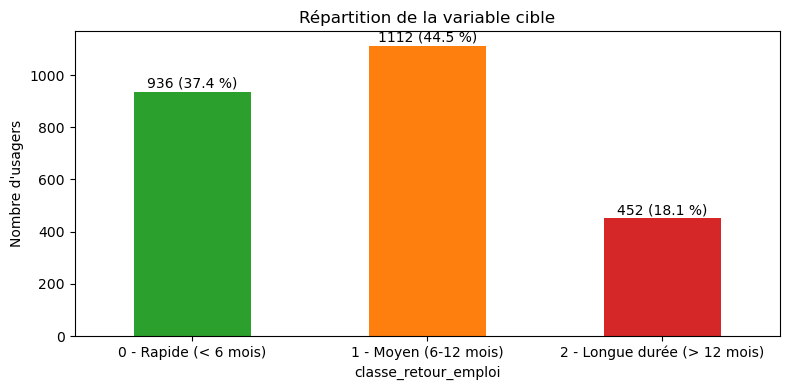

In [5]:
effectifs_cible = df["classe_retour_emploi"].value_counts().sort_index()
parts_cible = (effectifs_cible / len(df) * 100).round(1)

ax = effectifs_cible.plot(kind="bar", color=["#2ca02c", "#ff7f0e", "#d62728"])
ax.set_xticklabels(["0 - Rapide (< 6 mois)", "1 - Moyen (6-12 mois)", "2 - Longue durée (> 12 mois)"], rotation=0)
ax.set_ylabel("Nombre d'usagers")
ax.set_title("Répartition de la variable cible")
for i, (effectif, part) in enumerate(zip(effectifs_cible, parts_cible)):
    ax.text(i, effectif + 15, f"{effectif} ({part} %)", ha="center")
plt.tight_layout()
plt.show()

La cible est déséquilibrée : 37,4 % de retours rapides, 44,5 % de délais moyens, 18,1 % de risques de
longue durée. La classe la plus importante pour le métier est aussi la plus rare. Un modèle pourrait
donc afficher une accuracy correcte en la prédisant rarement — exactement ce qu'il ne faut pas.

Deux conséquences pour la suite : je suivrai le F1-macro (chaque classe y pèse autant) et la matrice
de confusion en plus de l'accuracy ; et toutes les découpes seront stratifiées, pour que chaque pli
conserve la même proportion de classes 2.

### 3.4 Variables numériques

,age,anciennete_poste_ans
count,2378.00,2500.00
mean,40.57,2.97
std,13.23,2.98
min,18.00,0.00
25%,29.00,0.80
50%,41.00,2.00
75%,52.00,4.10
max,63.00,22.60


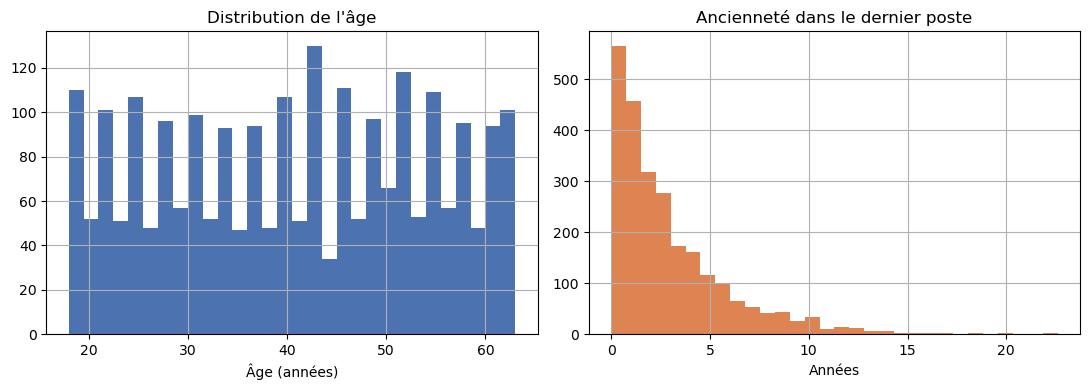

In [6]:
display(df[["age", "anciennete_poste_ans"]].describe().round(2))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
df["age"].dropna().hist(bins=30, ax=axes[0], color="#4c72b0")
axes[0].set_title("Distribution de l'âge")
axes[0].set_xlabel("Âge (années)")
df["anciennete_poste_ans"].hist(bins=30, ax=axes[1], color="#dd8452")
axes[1].set_title("Ancienneté dans le dernier poste")
axes[1].set_xlabel("Années")
plt.tight_layout()
plt.show()

L'âge va de 18 à 63 ans, sans valeur aberrante prise isolément. L'ancienneté est concentrée sur de
faibles valeurs, avec une longue traîne jusqu'à 22,6 ans : une asymétrie sans conséquence pour des
modèles à base d'arbres, qui coupent sur des seuils. Chaque variable paraît plausible seule ; leur
cohérence mutuelle est vérifiée au  4.3, et elle réserve une surprise.

### 3.5 Variables catégorielles et binaires

In [7]:
for colonne in ["niveau_diplome", "est_allocataire", "nationalite_hors_ue"]:
    print(f"{colonne} :", df[colonne].value_counts(dropna=False).to_dict())
part_hors_ue = df["nationalite_hors_ue"].mean() * 100
print(f"\nPart d'usagers de nationalité hors UE : {part_hors_ue:.1f} %")

niveau_diplome : {'Bac': 966, 'Bac+2': 501, 'Sans diplôme': 478, 'Bac+5': 471, nan: 84}
est_allocataire : {1.0: 1463, 0.0: 993, nan: 44}
nationalite_hors_ue : {0: 2205, 1: 295}

Part d'usagers de nationalité hors UE : 11.8 %


- `niveau_diplome` a quatre modalités ordonnées : j'utiliserai un encodage ordinal, qui conserve
  l'ordre Sans diplôme < Bac < Bac+2 < Bac+5.
- `est_allocataire` et `nationalite_hors_ue` sont déjà binaires.
- `nationalite_hors_ue` (11,8 % des usagers) est désignée par le sujet comme variable sensible. Une
  précision que je tiens à poser tôt : la nationalité ne figure pas, en tant que telle, parmi les
  catégories particulières de données de l'article 9 du RGPD. C'est en revanche un critère de
  discrimination prohibé (article 225-1 du code pénal), qui peut révéler l'origine. C'est à ce titre
  qu'elle est traitée avec la plus grande prudence.

### 3.6 Codes à haute cardinalité

In [8]:
print("Codes ROME distincts :", df["code_rome_vise"].nunique(), "/", len(df))
print("Communes (codes INSEE) distinctes :", df["code_insee_commune"].nunique(), "/", len(df))
display(df["code_insee_commune"].head(8).to_frame().T)

Codes ROME distincts : 50 / 2500
Communes (codes INSEE) distinctes : 2407 / 2500


,0,1,2,3,4,5,6,7
code_insee_commune,18273,07240,01405,63359,21302,71315,59301,74007


Avec 2 407 communes différentes pour 2 500 lignes, un one-hot du code INSEE créerait presque autant
de colonnes que d'usagers : le modèle apprendrait les communes par cœur. L'énoncé demande
explicitement l'extraction du département ; pour la faire, je lis les deux premiers caractères du
code INSEE. C'est une simplification que j'assume et que je le chiffrerai : elle est exacte en
métropole et en Corse, mais elle regroupe les départements d'outre-mer. Les 50 codes ROME, eux,
restent encodables directement.

### 3.7 La synthèse d'entretien 

In [9]:
longueurs = df["synthese_entretien"].dropna().str.len()
print("Longueur des synthèses (caractères) : min", longueurs.min(), "| médiane", int(longueurs.median()),
      "| max", longueurs.max())
formulations = df["synthese_entretien"].value_counts()
print(f"Formulations distinctes : {len(formulations)} pour {int(df['synthese_entretien'].notna().sum())} "
      f"synthèses renseignées ({int(df['synthese_entretien'].isna().sum())} absentes)\n")

libelle_texte = df["synthese_entretien"].fillna("(synthèse absente)")
repartition_texte = pd.crosstab(libelle_texte, df["classe_retour_emploi"], normalize="index") * 100
repartition_texte["effectif"] = libelle_texte.value_counts()
repartition_texte["classe_majoritaire"] = repartition_texte[[0, 1, 2]].idxmax(axis=1)
repartition_texte["part_majoritaire_%"] = repartition_texte[[0, 1, 2]].max(axis=1)
repartition_texte = repartition_texte.sort_values("part_majoritaire_%").round(1)
display(repartition_texte)

purete = repartition_texte.drop(index="(synthèse absente)")["part_majoritaire_%"]
trois_plus_ambigues = repartition_texte.drop(index="(synthèse absente)").head(3)

Longueur des synthèses (caractères) : min 63 | médiane 73 | max 77
Formulations distinctes : 9 pour 2419 synthèses renseignées (81 absentes)



classe_retour_emploi,0,1,2,effectif,classe_majoritaire,part_majoritaire_%
synthese_entretien,,,,,,
(synthèse absente),39.5,44.4,16.0,81,1,44.4
Freins périphériques majeurs. Situation d'illettrisme numérique constatée.,25.7,29.7,44.6,202,2,44.6
"Perte de confiance importante. Risque d'exclusion, barrière de la langue.",29.7,24.1,46.2,212,2,46.2
Cumul de difficultés. Pas de moyen de transport et garde d'enfants complexe.,25.1,26.9,48.0,227,2,48.0
"Candidat très dynamique, mobilité nationale validée. Projet clair.",68.0,23.6,8.5,259,0,68.0
"Profil autonome, recherche active, aucun frein périphérique identifié.",69.7,22.0,8.3,300,0,69.7
"Excellente présentation, compétences techniques à jour. Reprise rapide visée.",71.7,20.6,7.7,272,0,71.7
Problème ponctuel de mobilité géographique. Zone mal desservie.,16.8,74.6,8.7,334,1,74.6
Projet de reconversion à affiner. Besoin d'une formation complémentaire.,17.1,75.3,7.6,275,1,75.3


C'est la découverte qui a le plus orienté la suite du projet. La colonne présentée comme un « texte
libre » ne contient que **9 formulations**, répétées mot pour mot. Avec les 81 synthèses absentes,
que l'imputation remplacera par un texte vide, cela fait **10 modalités** : c'est une variable
catégorielle déguisée en texte.

Le tableau montre aussi que la même phrase ne conduit pas toujours à la même classe. La part de la
classe majoritaire va de 44,6 % (« Freins périphériques majeurs… ») à 78,4 % (« Compétences à
réactualiser… »). Les trois formulations qui décrivent des difficultés sont justement les plus
ambiguës : la classe 2 y est majoritaire, sans dépasser 48 %. C'est la première forme du « bruit
stochastique » évoqué par le sujet : même parfaitement lu, le texte ne peut pas déterminer la
classe, et le Scénario 3 (texte seul) plafonnera nécessairement.

Deux questions en découlent, que je traite par la mesure plutôt que par l'intuition : un TF-IDF
apporte-t-il quelque chose de plus qu'un simple one-hot de ces formulations ? Et que devient
le modèle quand le texte est bruité ou formulé autrement  ?

### 3.8 Quelles variables sont liées à la cible ?

Je mesure le lien de chaque variable avec la cible : khi-deux d'indépendance et V de Cramér pour les
variables catégorielles (le V ramène l'intensité du lien entre 0 et 1), test de Kruskal-Wallis pour
les variables numériques. Deux précautions de lecture : le khi-deux suppose au moins 5 observations
attendues par case, ce qui n'est pas le cas pour un département découpé en 96 modalités ; et le V de
Cramér tend à surestimer le lien quand les modalités sont nombreuses. J'affiche donc la part de cases
sous ce seuil, et je lis le département avec prudence.

In [10]:
colonnes_a_tester = {
    "synthese_entretien": df["synthese_entretien"],
    "niveau_diplome": df["niveau_diplome"],
    "code_rome_vise": df["code_rome_vise"],
    "nationalite_hors_ue": df["nationalite_hors_ue"],
    "departement (2 caractères)": df["code_insee_commune"].str.zfill(5).str[:2],
    "est_allocataire": df["est_allocataire"],
}
lignes_tests = []
for nom, valeurs in colonnes_a_tester.items():
    table = pd.crosstab(valeurs, df["classe_retour_emploi"])
    khi2, p_valeur, ddl, attendus = chi2_contingency(table)
    v_cramer = np.sqrt(khi2 / (table.values.sum() * (min(table.shape) - 1)))
    lignes_tests.append({"variable": nom, "modalités": table.shape[0], "khi²": round(khi2, 1), "ddl": ddl,
                         "p-value": p_valeur, "V de Cramér": round(v_cramer, 3),
                         "cases attendu < 5 (%)": round((attendus < 5).mean() * 100, 1)})
tests_association = pd.DataFrame(lignes_tests).set_index("variable")
display(tests_association)

resultats_kruskal = {}
for colonne in ["age", "anciennete_poste_ans"]:
    groupes = [df.loc[df["classe_retour_emploi"] == k, colonne].dropna() for k in (0, 1, 2)]
    H, p_valeur = kruskal(*groupes)
    resultats_kruskal[colonne] = (H, p_valeur)
    print(f"Kruskal-Wallis — {colonne:22s} H = {H:6.1f}   p = {p_valeur:.2e}")

print("\nClasses selon la nationalité (% par ligne) :")
nationalite_classe = pd.crosstab(df["nationalite_hors_ue"], df["classe_retour_emploi"], normalize="index").mul(100).round(1)
display(nationalite_classe)

print("Part de classe 2 par tranche d'âge (bornes incluses) :")
tranches_age = {"35 à 45 ans": df["age"].between(35, 45), "55 ans et plus (max. 63)": df["age"] >= 55}
tableau_tranches = pd.DataFrame([
    {"tranche": nom, "effectif": int(masque.sum()),
     "part_classe2_%": round((df.loc[masque, "classe_retour_emploi"] == 2).mean() * 100, 1)}
    for nom, masque in tranches_age.items()
]).set_index("tranche")
display(tableau_tranches)

,modalités,khi²,ddl,p-value,V de Cramér,cases attendu < 5 (%)
variable,,,,,,
synthese_entretien,9,1106.4,16,1.751e-225,0.478,0.0
niveau_diplome,4,390.6,6,2.882e-81,0.284,0.0
code_rome_vise,50,334.7,98,1.289e-27,0.259,0.0
nationalite_hors_ue,2,123.7,2,1.397e-27,0.222,0.0
departement (2 caractères),96,238.5,190,9.697e-03,0.218,32.3
est_allocataire,2,0.7,2,6.895e-01,0.017,0.0


Kruskal-Wallis — age                    H =  168.5   p = 2.63e-37
Kruskal-Wallis — anciennete_poste_ans   H =    7.5   p = 2.34e-02

Classes selon la nationalité (% par ligne) :


classe_retour_emploi,0,1,2
nationalite_hors_ue,,,
0,40.6,44.0,15.4
1,13.9,48.1,38.0


Part de classe 2 par tranche d'âge (bornes incluses) :


,effectif,part_classe2_%
tranche,,
35 à 45 ans,563,7.6
55 ans et plus (max. 63),442,38.2


**Ce que j'en retiens — sans en tirer encore de décision :**

1. **La synthèse d'entretien est de loin la variable la plus liée à la cible** (V = 0,478) : neuf
   formulations portent le signal le plus fort du jeu. Fort, mais pas déterministe — ce que
   confirmait déjà le 3.7.
2. **Le diplôme (0,284), le métier visé (0,259), la nationalité (0,222) et le département (0,218)**
   forment un second groupe. Le résultat du département est le plus fragile : 32,3 % de ses cases
   sont sous le seuil de validité du khi-deux.
3. **Le statut d'allocataire n'a aucun lien détectable avec la cible** (khi² = 0,7 pour 2 degrés de
   liberté, p = 0,69, V = 0,017). C'est la seule non-relation du tableau.
4. **L'âge est très fortement lié à la cible** (H = 168,5), bien plus que l'ancienneté (H = 7,5,
   p = 0,02). 38,2 % des usagers de 55 ans et plus sont en classe 2, contre 7,6 % des 35-45 ans.
   
6. **38,0 % des usagers de nationalité hors UE sont en classe 2, contre 15,4 % des autres.** C'est
   une association observée dans ces données, pas une relation de cause à effet ; elle explique
   pourquoi cette variable sera prédictive, et pourquoi son usage pose problème.

### 3.9 Ce que je retiens de l'exploration

- 2 500 usagers, 10 colonnes : un identifiant à exclure, huit variables explicatives, une cible.
- Quatre colonnes incomplètes, toutes sous 5 % : imputation simple, avec indicateurs de manque.
- Une cible déséquilibrée dont la classe critique est la plus rare : F1-macro, matrice de confusion,
  découpes stratifiées.
- Un code INSEE à transformer en département ; un diplôme à encoder de façon ordinale.
- Une synthèse qui se réduit à 9 formulations, informatives mais ambiguës.
- Deux variables protégées fortement liées à la cible — la nationalité et l'âge — qui structureront
  toute la discussion éthique.

## 4. Contrôle qualité et préparation des données

Cette étape transforme les données brutes en variables exploitables par un modèle, sans laisser
aucune information du jeu de test influencer l'entraînement. L'ordre compte : je contrôle d'abord la
qualité sur le jeu complet (ce sont des vérifications, pas des apprentissages), je crée les variables
dérivées qui ne dépendent que de la ligne elle-même, puis je sépare entraînement et test **avant**
toute imputation ou tout encodage.

### 4.1 Contrôles de qualité et de cohérence

In [11]:
print("Usagers en double (usager_id) :", int(df["usager_id"].duplicated().sum()))
print("Lignes strictement identiques :", int(df.duplicated().sum()))
print("Âge : de", df["age"].min(), "à", df["age"].max(), "| ancienneté : de",
      df["anciennete_poste_ans"].min(), "à", df["anciennete_poste_ans"].max())
print("Valeurs de est_allocataire :", sorted(df["est_allocataire"].dropna().unique().tolist()),
      "| de nationalite_hors_ue :", sorted(df["nationalite_hors_ue"].unique().tolist()),
      "| de la cible :", sorted(df["classe_retour_emploi"].unique().tolist()))

format_rome_valide = df["code_rome_vise"].str.fullmatch(r"[A-Z]\d{4}")
domaine_rome_connu = df["code_rome_vise"].str[0].isin(list("ABCDEFGHIJKLMN"))
codes_rome_suspects = df.loc[~domaine_rome_connu, "code_rome_vise"].value_counts()
print("\nCodes ROME au format inattendu :", int((~format_rome_valide).sum()))
print("Codes ROME hors des grands domaines A à N :", codes_rome_suspects.to_dict())

format_insee_valide = df["code_insee_commune"].str.fullmatch(r"\d{5}|2[AB]\d{3}")
codes_corses = df["code_insee_commune"].str.match(r"2[AB]")
codes_outre_mer = df.loc[df["code_insee_commune"].str.startswith("97"), "code_insee_commune"]
print("Codes INSEE au format inattendu :", int((~format_insee_valide).sum()))
print("Communes corses (2A / 2B) :", int(codes_corses.sum()))
print("Communes d'outre-mer :", len(codes_outre_mer), "réparties sur", codes_outre_mer.str[:3].nunique(),
      "départements", codes_outre_mer.str[:3].value_counts().sort_index().to_dict())

Usagers en double (usager_id) : 0
Lignes strictement identiques : 0
Âge : de 18.0 à 63.0 | ancienneté : de 0.0 à 22.6
Valeurs de est_allocataire : [0.0, 1.0] | de nationalite_hors_ue : [0, 1] | de la cible : [0, 1, 2]

Codes ROME au format inattendu : 0
Codes ROME hors des grands domaines A à N : {'W1401': 30}
Codes INSEE au format inattendu : 0
Communes corses (2A / 2B) : 21
Communes d'outre-mer : 10 réparties sur 5 départements {'971': 4, '972': 3, '973': 1, '974': 1, '976': 1}


**Ce que les contrôles montrent, et ce que j'en décide :**

- **Aucun doublon**, et toutes les valeurs sont dans des plages plausibles. Les 21 codes corses
  (`2A…`, `2B…`) sont au bon format : je vérifie le format complet, pas seulement la longueur.
- **Le code ROME `W1401` (30 lignes) est suspect.** Son format est correct, mais la lettre W ne
  correspond à aucun des grands domaines du ROME que je connais (de A à N). C'est probablement un
  code fictif ou erroné. Je ne peux pas le corriger — je ne sais pas quel métier il désigne — et je
  ne veux pas supprimer 30 usagers pour un code : je le garde comme une modalité à part entière.
- **Les 10 usagers d'outre-mer relèvent de 5 départements différents.** La règle des deux premiers
  caractères les regroupera sous un seul « 97 ».

### 4.2 Extraction du département

In [12]:
# Deux premiers caractères du code INSEE ; zfill(5) restaure un zéro de tête perdu lors d'un export.
df["departement"] = df["code_insee_commune"].astype(str).str.zfill(5).str[:2]
print("Départements distincts :", df["departement"].nunique())
print("Usagers regroupés sous « 97 » :", int((df["departement"] == "97").sum()))
display(df[["code_insee_commune", "departement"]].head(5).T)

Départements distincts : 96
Usagers regroupés sous « 97 » : 10


,0,1,2,3,4
code_insee_commune,18273,07240,01405,63359,21302
departement,18,07,01,63,21


On passe de 2 407 communes à 96 départements : une variable encodable, qui garde l'essentiel de
l'information géographique. La règle des deux caractères est exacte pour la métropole et la Corse,
mais elle regroupe sous « 97 » les 10 usagers d'outre-mer, qui relèvent de cinq départements
distincts (971, 972, 973, 974 et 976). J'ai conservé cette simplification : elle concerne 0,4 % des lignes, et la
corriger maintenant aurait modifié toute la chaîne déjà validée. 

### 4.3 Cohérence entre l'âge et l'ancienneté

In [13]:
# L'ancienneté dans le dernier poste ne peut pas remonter avant l'âge de 14 ans.
age_debut_activite = df["age"] - df["anciennete_poste_ans"]
df["anciennete_incoherente"] = (age_debut_activite < 14).astype(int)
nb_incoherentes = int(df["anciennete_incoherente"].sum())
print("Lignes incohérentes (poste commencé avant 14 ans d'après les données) :", nb_incoherentes, "/", len(df))
display(df.loc[df["anciennete_incoherente"] == 1, ["age", "anciennete_poste_ans"]]
          .assign(age_debut_activite=age_debut_activite).head(6))
debut_avant_10_ans = int((age_debut_activite < 10).sum())
print("Dont dossiers situant le début du poste avant 10 ans :", debut_avant_10_ans)

Lignes incohérentes (poste commencé avant 14 ans d'après les données) : 51 / 2500


,age,anciennete_poste_ans,age_debut_activite
89,18.0,7.0,11.0
94,18.0,5.2,12.8
129,18.0,5.5,12.5
156,24.0,13.7,10.3
220,22.0,8.9,13.1
302,20.0,8.1,11.9


Dont dossiers situant le début du poste avant 10 ans : 11


51 dossiers (2 %) décrivent un poste commencé avant 14 ans, parfois avant 10 ans : c'est impossible.
J'ai choisi 14 ans comme borne volontairement prudente — l'âge légal général d'accès au travail est
de 16 ans, 14 ans correspondant aux travaux légers autorisés pendant les vacances scolaires.

Je ne supprime pas ces lignes et je ne « corrige » pas leurs valeurs : je ne sais pas si c'est l'âge
ou l'ancienneté qui est faux, et en fabriquer une nouvelle valeur introduirait un biais que je ne
maîtrise pas. Je crée plutôt un indicateur `anciennete_incoherente`, que le modèle peut utiliser, et
je mesurerai au ce que coûterait le retrait de ces lignes. Un âge manquant donne une
comparaison fausse, donc un indicateur à 0 : l'API applique exactement la même règle.

### 4.4 Séparation entraînement / test

In [14]:
# usager_id est exclu (aucun pouvoir prédictif, risque d'apprentissage par cœur) ;
# code_insee_commune est remplacé par le département ;
feature_cols = [
    "age", "niveau_diplome", "anciennete_poste_ans", "code_rome_vise",
    "departement", "est_allocataire", "nationalite_hors_ue", "synthese_entretien",
    "anciennete_incoherente",
]
X = df[feature_cols].copy()
y = df["classe_retour_emploi"].copy()

# stratify=y : les trois classes gardent les mêmes proportions dans les deux jeux.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=GRAINE)
y_train_arr, y_test_arr = y_train.to_numpy(), y_test.to_numpy()

print("Entraînement :", X_train.shape, "| test :", X_test.shape)
print(pd.DataFrame({"entrainement": y_train.value_counts(normalize=True).sort_index(),
                    "test": y_test.value_counts(normalize=True).sort_index()}).round(3))

Entraînement : (2000, 9) | test : (500, 9)
                      entrainement   test
classe_retour_emploi                     
0                            0.374  0.374
1                            0.444  0.446
2                            0.181  0.180


Je sépare avant d'imputer ou d'encoder. Si la médiane de l'âge ou le vocabulaire du TF-IDF étaient
calculés sur les 2 500 lignes, le jeu de test aurait déjà influencé le modèle : c'est une fuite de
données, qui rend la performance mesurée trop optimiste. Désormais, toute statistique est calculée
sur `X_train` puis appliquée telle quelle à `X_test`. Les proportions des classes sont identiques
dans les deux jeux grâce à la stratification ; le jeu de test compte 90 usagers de classe 2, un
effectif modeste que je garderai en tête au moment d'interpréter la mesure finale (§ 9).

### 4.5 Valeurs manquantes : indicateurs, puis imputation

In [15]:
# 1) Garder la trace du manque AVANT de le combler : l'absence peut être un signal.
colonnes_incompletes = ["age", "niveau_diplome", "est_allocataire", "synthese_entretien"]
for colonne in colonnes_incompletes:
    X_train[f"{colonne}_manquant"] = X_train[colonne].isna().astype(int)
    X_test[f"{colonne}_manquant"] = X_test[colonne].isna().astype(int)

# 2) Imputer avec des statistiques calculées sur X_train uniquement.
age_median = X_train["age"].median()
X_train["age"] = X_train["age"].fillna(age_median)
X_test["age"] = X_test["age"].fillna(age_median)

diplome_mode = X_train["niveau_diplome"].mode()[0]
X_train["niveau_diplome"] = X_train["niveau_diplome"].fillna(diplome_mode)
X_test["niveau_diplome"] = X_test["niveau_diplome"].fillna(diplome_mode)

alloc_mode = X_train["est_allocataire"].mode()[0]
X_train["est_allocataire"] = X_train["est_allocataire"].fillna(alloc_mode).astype(int)
X_test["est_allocataire"] = X_test["est_allocataire"].fillna(alloc_mode).astype(int)

# Synthèse absente -> texte vide (le TF-IDF la représentera comme une absence d'information).
X_train["synthese_entretien"] = X_train["synthese_entretien"].fillna("")
X_test["synthese_entretien"] = X_test["synthese_entretien"].fillna("")

print("Valeurs utilisées (apprises sur l'entraînement) : âge médian", age_median,
      "| diplôme le plus fréquent", diplome_mode, "| statut d'allocation le plus fréquent", int(alloc_mode))
print("Valeurs manquantes restantes — entraînement :", int(X_train.isna().sum().sum()),
      "| test :", int(X_test.isna().sum().sum()))

Valeurs utilisées (apprises sur l'entraînement) : âge médian 41.0 | diplôme le plus fréquent Bac | statut d'allocation le plus fréquent 1
Valeurs manquantes restantes — entraînement : 0 | test : 0


Il ne reste aucune valeur manquante, et les valeurs de remplacement (âge médian de 41 ans, « Bac »,
statut allocataire) viennent exclusivement du jeu d'entraînement.

Une limite que je préfère poser dès maintenant : dans les validations croisées des sections 6 à 8,
cette imputation (comme le one-hot et le TF-IDF qui suivent) est apprise une fois sur les 2 000
lignes d'entraînement, et non à l'intérieur de chaque pli. Le pli de validation « voit » donc un peu
les statistiques de préparation. 

### 4.6 Encodage du diplôme, du département et du métier visé

In [16]:
# Diplôme : encodage ordinal, qui respecte l'ordre Sans diplôme < Bac < Bac+2 < Bac+5.
mapping_diplome = {"Sans diplôme": 0, "Bac": 1, "Bac+2": 2, "Bac+5": 3}
X_train["niveau_diplome_encode"] = X_train["niveau_diplome"].map(mapping_diplome)
X_test["niveau_diplome_encode"] = X_test["niveau_diplome"].map(mapping_diplome)

# Département et code ROME : one-hot appris sur l'entraînement. handle_unknown="ignore" : une modalité
# jamais vue donne une ligne de zéros au lieu d'une erreur (l'API le signale au conseiller).
ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
ohe.fit(X_train[["departement", "code_rome_vise"]])
noms_ohe = ohe.get_feature_names_out(["departement", "code_rome_vise"])
train_ohe = pd.DataFrame(ohe.transform(X_train[["departement", "code_rome_vise"]]), columns=noms_ohe, index=X_train.index)
test_ohe = pd.DataFrame(ohe.transform(X_test[["departement", "code_rome_vise"]]), columns=noms_ohe, index=X_test.index)

print("Colonnes créées par le one-hot :", train_ohe.shape[1],
      f"({len(ohe.categories_[0])} départements + {len(ohe.categories_[1])} codes ROME)")
controler(train_ohe.shape[1] == 146, "le one-hot crée 146 colonnes (96 départements + 50 codes ROME)")

Colonnes créées par le one-hot : 146 (96 départements + 50 codes ROME)
✔ le one-hot crée 146 colonnes (96 départements + 50 codes ROME)


True

L'encodage ordinal permet à un arbre d'apprendre des règles du type « diplôme Bac+5 ≥ Bac+2 », ce qu'un
one-hot rendrait plus difficile. Le département et le métier visé n'ont pas d'ordre naturel : un
one-hot convient, et il produit 146 colonnes — à comparer aux 2 407 qu'aurait données la commune.

### 4.7 Nettoyage du texte

In [17]:
# Minuscules et espaces superflus retirés. La vectorisation viendra au § 5.2, apprise sur l'entraînement.
X_train["synthese_entretien"] = X_train["synthese_entretien"].str.lower().str.strip()
X_test["synthese_entretien"] = X_test["synthese_entretien"].str.lower().str.strip()
print(X_train["synthese_entretien"].head(3).tolist())

["freins périphériques majeurs. situation d'illettrisme numérique constatée.", 'candidat très dynamique, mobilité nationale validée. projet clair.', 'profil autonome, recherche active, aucun frein périphérique identifié.']


### 4.8 Bilan de la préparation

| Type de variable | Colonnes | Traitement |
|---|---|---|
| Numériques | `age`, `anciennete_poste_ans` | âge imputé par la médiane de l'entraînement |
| Ordinale | `niveau_diplome_encode` | encodage 0 → 3 |
| Nominales | `departement`, `code_rome_vise` | one-hot appris sur l'entraînement (146 colonnes) |
| Binaires | `est_allocataire`, `nationalite_hors_ue` | statut d'allocation imputé par la modalité la plus fréquente |
| Indicateurs de manque | `age_manquant`, `niveau_diplome_manquant`, `est_allocataire_manquant`, `synthese_entretien_manquant` | créés avant imputation |
| Indicateur de cohérence | `anciennete_incoherente` | 51 dossiers signalés |
| Texte | `synthese_entretien` | nettoyé, vectorisé  |

Anomalies connues et conservées, chiffrées : le code ROME `W1401` (30 lignes) et le regroupement des
départements d'outre-mer (10 usagers).

## 5. Construction des quatre scénarios de données

J'assemble maintenant les briques préparées en quatre jeux de données, un par scénario du sujet. Je
ne fais ici que préparer les matrices ; les comparaisons viennent aux sections Suivantes. Pas de mise à
l'échelle des variables numériques : les modèles à base d'arbres coupent sur des seuils, l'échelle
n'a aucun effet sur eux.

### 5.1 Base tabulaire commune

In [18]:
colonnes_numeriques_binaires = [
    "age", "anciennete_poste_ans", "niveau_diplome_encode", "est_allocataire", "nationalite_hors_ue",
    "age_manquant", "niveau_diplome_manquant", "est_allocataire_manquant",
    "synthese_entretien_manquant", "anciennete_incoherente",
]
tabulaire_train = pd.concat([X_train[colonnes_numeriques_binaires].reset_index(drop=True),
                             train_ohe.reset_index(drop=True)], axis=1)
tabulaire_test = pd.concat([X_test[colonnes_numeriques_binaires].reset_index(drop=True),
                            test_ohe.reset_index(drop=True)], axis=1)
print("Base tabulaire — entraînement :", tabulaire_train.shape, "| test :", tabulaire_test.shape)
print("Premières colonnes :", list(tabulaire_train.columns[:12]))

Base tabulaire — entraînement : (2000, 156) | test : (500, 156)
Premières colonnes : ['age', 'anciennete_poste_ans', 'niveau_diplome_encode', 'est_allocataire', 'nationalite_hors_ue', 'age_manquant', 'niveau_diplome_manquant', 'est_allocataire_manquant', 'synthese_entretien_manquant', 'anciennete_incoherente', 'departement_01', 'departement_02']


### 5.2 Vectorisation du texte (TF-IDF)

In [19]:
tfidf = TfidfVectorizer()
tfidf.fit(X_train["synthese_entretien"])       # vocabulaire appris sur l'entraînement uniquement
texte_train = tfidf.transform(X_train["synthese_entretien"])
texte_test = tfidf.transform(X_test["synthese_entretien"])
print("Vocabulaire appris :", len(tfidf.vocabulary_), "mots | matrice d'entraînement :", texte_train.shape)
controler(len(tfidf.vocabulary_) == 68, "le vocabulaire TF-IDF compte 68 mots")

Vocabulaire appris : 68 mots | matrice d'entraînement : (2000, 68)
✔ le vocabulaire TF-IDF compte 68 mots


True

Le vocabulaire se limite à 68 mots : cohérent avec les 9 formulations du paragraphe 3.7. Le TF-IDF représente
chaque synthèse par le poids de ses mots ; une synthèse vide devient un vecteur nul, que l'indicateur
`synthese_entretien_manquant` permet de distinguer.

### 5.3 Les quatre scénarios

In [20]:
tabulaire_train_sparse = csr_matrix(tabulaire_train.values)
tabulaire_test_sparse = csr_matrix(tabulaire_test.values)

colonnes_sans_sensible = [c for c in tabulaire_train.columns if c != "nationalite_hors_ue"]
tabulaire_train_sans_sensible = csr_matrix(tabulaire_train[colonnes_sans_sensible].values)
tabulaire_test_sans_sensible = csr_matrix(tabulaire_test[colonnes_sans_sensible].values)

scenarios = {
    "1_multimodal_complet": {"X_train": hstack([tabulaire_train_sparse, texte_train]).tocsr(),
                             "X_test": hstack([tabulaire_test_sparse, texte_test]).tocsr(),
                             "texte": True, "nationalite": True},
    "2_sans_variable_sensible": {"X_train": hstack([tabulaire_train_sans_sensible, texte_train]).tocsr(),
                                 "X_test": hstack([tabulaire_test_sans_sensible, texte_test]).tocsr(),
                                 "texte": True, "nationalite": False},
    "3_texte_seul": {"X_train": texte_train.tocsr(), "X_test": texte_test.tocsr(),
                     "texte": True, "nationalite": False},
    "4_tabulaire_seul": {"X_train": tabulaire_train_sparse, "X_test": tabulaire_test_sparse,
                         "texte": False, "nationalite": True},
}
# Variante examinée au § 7.4 pour un éventuel pré-tri avant l'entretien : tabulaire, sans nationalité.
variantes = {
    "4b_tabulaire_sans_nationalite": {"X_train": tabulaire_train_sans_sensible, "X_test": tabulaire_test_sans_sensible,
                                      "texte": False, "nationalite": False},
}
recapitulatif = pd.DataFrame([
    {"scenario": nom, "variables": d["X_train"].shape[1], "texte": d["texte"], "nationalite": d["nationalite"]}
    for nom, d in {**scenarios, **variantes}.items()
]).set_index("scenario")
display(recapitulatif)

,variables,texte,nationalite
scenario,,,
1_multimodal_complet,224,True,True
2_sans_variable_sensible,223,True,False
3_texte_seul,68,True,False
4_tabulaire_seul,156,False,True
4b_tabulaire_sans_nationalite,155,False,False


**Le périmètre de deux scénarios mérite une explication.**

- **Scénario 4.** Le sujet le décrit comme « basé uniquement sur l'âge, les diplômes, l'ancienneté
  et la géographie ». J'ai retenu une lecture plus large — toutes les variables tabulaires, y compris
  la nationalité et le statut d'allocation — pour qu'il soit l'exact opposé du Scénario 3 (hypothèse
  H1). Conséquence que je dois assumer : le Scénario 4 **contient la variable sensible**. Il ne peut
  donc pas servir tel quel en production ; c'est pourquoi j'ajoute une variante 4b, tabulaire et sans
  nationalité, pour la question du pré-tri avant entretien.
- **Scénario 2.** Je retire `nationalite_hors_ue`, la seule variable désignée comme sensible par le
  dictionnaire des données. D'autres variables pourraient servir de substitut (le département, par
  exemple) : je calcullerai le risque dans les prochain paragraphe.
  L'âge, autre critère protégé.

### 5.4 Bilan

Quatre scénarios et une variante sont prêts, construits avec la même préparation. Le vocabulaire du
TF-IDF et les catégories du one-hot viennent de l'entraînement. La suite compare d'abord des familles
de modèles sur le Scénario 1, puis les scénarios entre eux.

## 6. Modèles candidats en validation croisée

L'énoncé demande de comparer au moins trois familles : Random Forest, LightGBM et XGBoost. Ce sont
trois ensembles d'arbres de décision, qui diffèrent par la façon de les combiner :

- **Random Forest** entraîne des centaines d'arbres indépendants, chacun sur un échantillon tiré au
  hasard, puis leur fait voter la classe ;
- **XGBoost** et **LightGBM** construisent les arbres les uns après les autres (on parle de
  *boosting*), chaque nouvel arbre corrigeant les erreurs des précédents. LightGBM fait croître ses
  arbres feuille par feuille, XGBoost niveau par niveau.


**Protocole.** Une validation croisée stratifiée en 5 plis, sur les 2 000 lignes d'entraînement
uniquement : le jeu est découpé en 5 parts de mêmes proportions de classes ; chaque part sert une
fois à la validation pendant que les 4 autres servent à l'apprentissage. On obtient 5 mesures, dont
la moyenne est plus fiable qu'une mesure unique et dont l'écart-type indique la stabilité. Tous les
modèles gardent leurs réglages par défaut, avec la même graine. La comparaison porte sur le
Scénario 1, le plus complet.

### 6.1 Comparaison des familles de modèles

In [21]:
# Les deux modèles de boosting sont réutilisés dans toute la suite, avec ces réglages.
candidats_boosting = [
    ("XGBoost", XGBClassifier, dict(random_state=GRAINE, eval_metric="mlogloss")),
    ("LightGBM", LGBMClassifier, dict(random_state=GRAINE, verbose=-1)),
]

modeles_candidats = {
    "Random Forest": RandomForestClassifier(n_estimators=300, random_state=GRAINE, n_jobs=-1),
    "LightGBM": LGBMClassifier(random_state=GRAINE, verbose=-1),
    "XGBoost": XGBClassifier(random_state=GRAINE, eval_metric="mlogloss"),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=GRAINE)

X_s1_train = scenarios["1_multimodal_complet"]["X_train"]
resultats_cv, f1_par_pli_familles = [], {}

with warnings.catch_warnings():
    warnings.simplefilter("ignore")   # masque les avertissements techniques
    for nom, modele in modeles_candidats.items():
        scores = cross_validate(modele, X_s1_train, y_train_arr, cv=cv,
                                scoring=["accuracy", "f1_macro"])
        f1_par_pli_familles[nom] = scores["test_f1_macro"]
        resultats_cv.append({
            "modele": nom,
            "accuracy_moyenne": scores["test_accuracy"].mean(),
            "accuracy_ecart_type": scores["test_accuracy"].std(),
            "f1_macro_moyen": scores["test_f1_macro"].mean(),
            "f1_macro_ecart_type": scores["test_f1_macro"].std(),
            "temps_entrainement_moyen_s": scores["fit_time"].mean(),
        })

resultats_cv_df = (pd.DataFrame(resultats_cv)
                   .set_index("modele")
                   .sort_values("f1_macro_moyen", ascending=False))

f1_familles = resultats_cv_df["f1_macro_moyen"]
temps_familles = resultats_cv_df["temps_entrainement_moyen_s"]

display(resultats_cv_df.round(3))

,accuracy_moyenne,accuracy_ecart_type,f1_macro_moyen,f1_macro_ecart_type,temps_entrainement_moyen_s
modele,,,,,
XGBoost,0.726,0.019,0.705,0.021,0.355
LightGBM,0.718,0.023,0.700,0.023,0.774
Random Forest,0.685,0.010,0.661,0.012,0.761


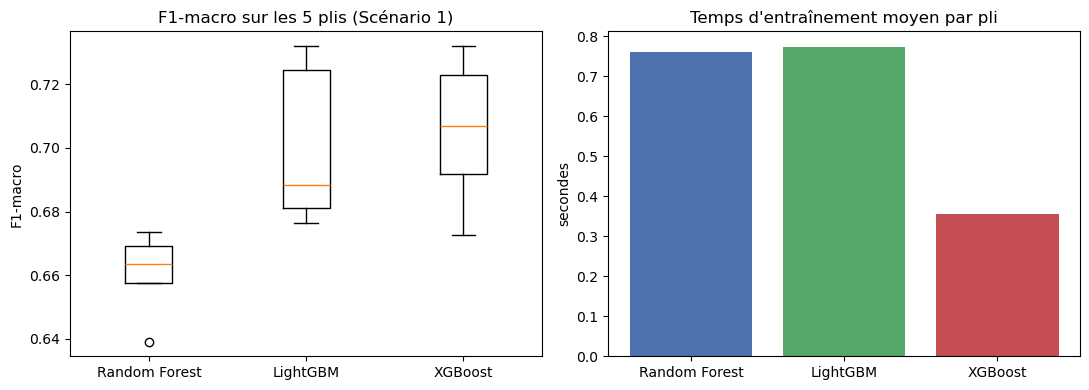

In [22]:
familles = list(modeles_candidats)   # Random Forest, LightGBM, XGBoost

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Graphique 1 : dispersion du F1-macro sur les 5 plis
axes[0].boxplot([f1_par_pli_familles[nom] for nom in familles], tick_labels=familles)
axes[0].set_title("F1-macro sur les 5 plis (Scénario 1)")
axes[0].set_ylabel("F1-macro")

# Graphique 2 : temps d'entraînement moyen
axes[1].bar(familles, temps_familles[familles], color=["#4c72b0", "#55a868", "#c44e52"])
axes[1].set_title("Temps d'entraînement moyen par pli")
axes[1].set_ylabel("secondes")

plt.tight_layout()
plt.show()

**Ce que je retiens.**

- **XGBoost (F1-macro 0,705 ± 0,021) et LightGBM (0,700) sont au coude à coude**, loin devant
  Random Forest (0,661). L'écart entre les deux modèles de boosting est bien plus petit que la
  dispersion entre plis : à ce stade, je ne peux pas les départager. Je garde les deux pour la suite.
- **Les temps affichés dépendent de la machine.** Je n'en tire qu'un ordre de grandeur : Random Forest
  est le plus lent à entraîner. La latence de prédiction, qui compte davantage en production, est
  mesurée ci-dessous.

### 6.2 Coût d'une prédiction

In [23]:
# Latence de prédiction pour UN usager : c'est la situation réelle d'un entretien.
une_ligne_s1 = X_s1_train[[0]]
latences_familles = {}
for nom, modele in modeles_candidats.items():
    modele.fit(X_s1_train, y_train_arr)
    modele.predict_proba(une_ligne_s1)                      # premier appel (échauffement) non compté
    debut = time.perf_counter()
    for _ in range(100):
        modele.predict_proba(une_ligne_s1)
    latences_familles[nom] = (time.perf_counter() - debut) / 100 * 1000
latences_familles = pd.Series(latences_familles, name="latence_ms_pour_un_usager")
display(latences_familles.round(2).to_frame())

,latence_ms_pour_un_usager
Random Forest,63.37
LightGBM,1.37
XGBoost,1.01


Les trois modèles prédisent un usager bien en deçà de l'objectif de 200 ms côté serveur. Random Forest est le plus lent : il doit interroger 300 arbres et répartir le travail entre les
cœurs du processeur, ce qui coûte cher pour une seule ligne. Les modèles de boosting sont plus
rapides et plus légers.

### 6.3 Bilan

Les deux modèles de boosting sont retenus pour comparer les scénarios. Random Forest est écarté à ce
stade — moins bon et plus lent — mais je le réintègre dans la comparaison finale des réglages,
pour vérifier qu'il ne ferait pas mieux sur les erreurs critiques, qui sont le vrai critère métier.

## 7. Comparaison des scénarios en validation croisée

Les quatre scénarios sont comparés avec le même protocole, les mêmes plis et les deux modèles de
boosting. Pour chaque combinaison, je suis deux mesures :

- le **F1-macro**, pour la qualité globale sur les trois classes ;
- l'**erreur critique**, c'est-à-dire la part des usagers de classe 2 (plus de 12 mois) prédits en
  classe 0 (moins de 6 mois). C'est l'erreur qui prive un usager de l'accompagnement renforcé.

J'y ajoute la variante 4b (tabulaire sans nationalité), utile pour la question du pré-tri. Le jeu de
test n'intervient pas : tout se passe sur les 2 000 lignes d'entraînement.

### 7.1 F1-macro et erreur critique par scénario

In [24]:
def erreur_critique(y_vrai, y_pred):
    """Part des usagers de classe 2 prédits en classe 0."""
    matrice = confusion_matrix(y_vrai, y_pred, labels=[0, 1, 2])
    return matrice[2, 0] / matrice[2].sum()


resultats_scenarios, predictions_oof_scenarios, probas_oof_scenarios = [], {}, {}
for nom_scenario, donnees in {**scenarios, **variantes}.items():
    X_sc = donnees["X_train"]
    for nom_modele, classe_modele, parametres in candidats_boosting:
        f1_plis, erreurs_plis = [], []
        probas = np.zeros((X_sc.shape[0], 3))
        for idx_app, idx_val in cv.split(X_sc, y_train_arr):
            modele = classe_modele(**parametres).fit(X_sc[idx_app], y_train_arr[idx_app])
            probas[idx_val] = modele.predict_proba(X_sc[idx_val])
            prediction = modele.predict(X_sc[idx_val])
            f1_plis.append(f1_score(y_train_arr[idx_val], prediction, average="macro"))
            erreurs_plis.append(erreur_critique(y_train_arr[idx_val], prediction))
        probas_oof_scenarios[(nom_scenario, nom_modele)] = probas
        predictions_oof_scenarios[(nom_scenario, nom_modele)] = probas.argmax(axis=1)
        resultats_scenarios.append({"scenario": nom_scenario, "modele": nom_modele,
                                    "f1_macro_cv": np.mean(f1_plis), "ecart_type_plis": np.std(f1_plis),
                                    "erreur_critique_cv": np.mean(erreurs_plis)})

scenarios_df = pd.DataFrame(resultats_scenarios).set_index(["scenario", "modele"])
display(scenarios_df.unstack("modele").round(3))

f1_macro_cv         ecart_type_plis         erreur_critique_cv        
modele                           LightGBM XGBoost        LightGBM XGBoost           LightGBM XGBoost
scenario                                                                                            
1_multimodal_complet                0.700   0.705           0.023   0.021              0.122   0.113
2_sans_variable_sensible            0.669   0.683           0.013   0.019              0.132   0.127
3_texte_seul                        0.635   0.635           0.017   0.017              0.190   0.190
4_tabulaire_seul                    0.657   0.639           0.031   0.029              0.094   0.097
4b_tabulaire_sans_nationalite       0.591   0.595           0.028   0.024              0.110   0.124

**Lecture du tableau.**

- **Le Scénario 1 (tout) est le meilleur**, avec un F1-macro de 0,705 (XGBoost) et 0,700 (LightGBM).
- **Retirer la nationalité (Scénario 2) coûte 0,022 de F1-macro avec XGBoost** (0,683) et 0,031 avec
  LightGBM (0,669). Avec XGBoost, cet écart est du même ordre que la dispersion entre plis ; ce qui
  le rend crédible, c'est qu'il va dans le même sens pour les deux modèles et pour l'AUC. La
  nationalité porte donc un signal statistique, cohérent avec l'écart observé dans le paragraphe 3.8.
- **Le texte seul (Scénario 3) est le moins bon** : 0,635 de F1-macro et 19 % d'erreurs critiques
  pour les deux modèles. C'est logique : neuf formulations seulement, dont les plus ambiguës
  penchent vers la classe 2 sans la garantir.
- **Le tabulaire seul (Scénario 4) fait moins d'erreurs critiques** (9,7 % et 9,4 %) que le
  Scénario 1 (11,3 % et 12,2 %), mais au prix d'un F1-macro nettement plus bas (0,639 et 0,657). Il
  prédit plus souvent la classe 2, ce qui protège contre l'erreur critique mais dégrade les autres
  classes. Et il contient la nationalité.
- **La variante 4b** (tabulaire sans nationalité) reste en dessous du Scénario 2 : la synthèse
  d'entretien apporte un signal que les seules variables administratives ne remplacent pas.

### 7.2 Où se trompent les modèles ? Matrices de confusion hors-pli

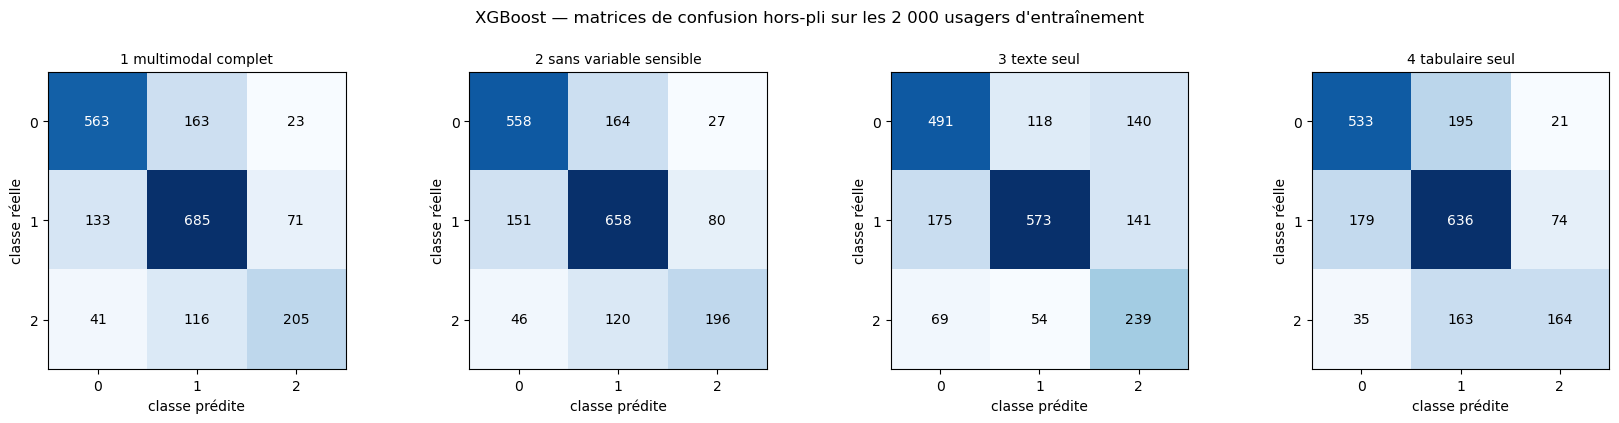

,confusions 0 ↔ 1,confusions 1 ↔ 2,confusions 0 ↔ 2,classe 2 prédite 0,confusion la plus fréquente
scenario,,,,,
1_multimodal_complet,296,187,64,41,0 ↔ 1
2_sans_variable_sensible,315,200,73,46,0 ↔ 1
3_texte_seul,293,195,209,69,0 ↔ 1
4_tabulaire_seul,374,237,56,35,0 ↔ 1


In [25]:
# Chaque ligne d'entraînement est prédite par le modèle du pli où elle servait à la validation
# (prédiction « hors-pli ») : on obtient une matrice de confusion sur 2 000 usagers sans toucher au test.
fig, axes = plt.subplots(1, 4, figsize=(17, 4))
resume_confusions = []
for ax, nom_scenario in zip(axes, scenarios):
    matrice = confusion_matrix(y_train_arr, predictions_oof_scenarios[(nom_scenario, "XGBoost")], labels=[0, 1, 2])
    ax.imshow(matrice, cmap="Blues")
    for i in range(3):
        for j in range(3):
            ax.text(j, i, matrice[i, j], ha="center", va="center", color="white" if matrice[i, j] > matrice.max() / 2 else "black")
    ax.set_xticks(range(3), ["0", "1", "2"])
    ax.set_yticks(range(3), ["0", "1", "2"])
    ax.set_xlabel("classe prédite")
    ax.set_ylabel("classe réelle")
    ax.set_title(nom_scenario.replace("_", " "), fontsize=10)
    confusions = {"0 ↔ 1": matrice[0, 1] + matrice[1, 0], "1 ↔ 2": matrice[1, 2] + matrice[2, 1], "0 ↔ 2": matrice[0, 2] + matrice[2, 0]}
    resume_confusions.append({"scenario": nom_scenario, **{f"confusions {k}": int(v) for k, v in confusions.items()},
                              "classe 2 prédite 0": int(matrice[2, 0]), "confusion la plus fréquente": max(confusions, key=confusions.get)})
plt.suptitle("XGBoost — matrices de confusion hors-pli sur les 2 000 usagers d'entraînement", y=1.02)
plt.tight_layout()
plt.show()
display(pd.DataFrame(resume_confusions).set_index("scenario"))

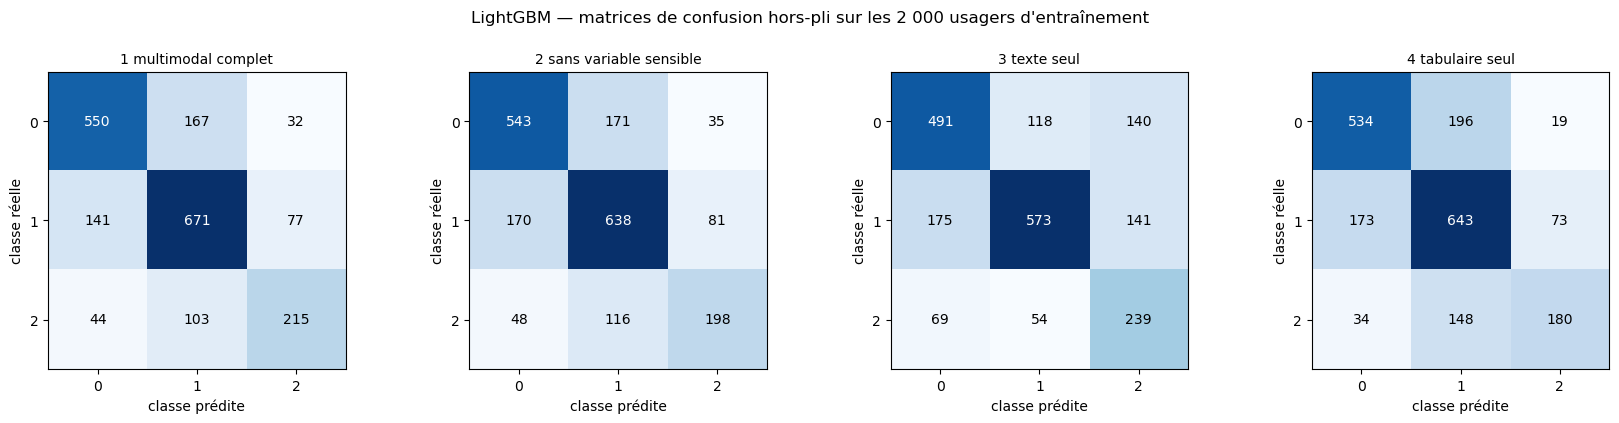

,confusions 0 ↔ 1,confusions 1 ↔ 2,confusions 0 ↔ 2,classe 2 prédite 0,confusion la plus fréquente
scenario,,,,,
1_multimodal_complet,308,180,76,44,0 ↔ 1
2_sans_variable_sensible,341,197,83,48,0 ↔ 1
3_texte_seul,293,195,209,69,0 ↔ 1
4_tabulaire_seul,369,221,53,34,0 ↔ 1


In [26]:
# Chaque ligne d'entraînement est prédite par le modèle du pli où elle servait à la validation
# (prédiction « hors-pli ») : on obtient une matrice de confusion sur 2 000 usagers sans toucher au test.
fig, axes = plt.subplots(1, 4, figsize=(17, 4))
resume_confusions = []
for ax, nom_scenario in zip(axes, scenarios):
    matrice = confusion_matrix(y_train_arr, predictions_oof_scenarios[(nom_scenario, "LightGBM")], labels=[0, 1, 2])
    ax.imshow(matrice, cmap="Blues")
    for i in range(3):
        for j in range(3):
            ax.text(j, i, matrice[i, j], ha="center", va="center", color="white" if matrice[i, j] > matrice.max() / 2 else "black")
    ax.set_xticks(range(3), ["0", "1", "2"])
    ax.set_yticks(range(3), ["0", "1", "2"])
    ax.set_xlabel("classe prédite")
    ax.set_ylabel("classe réelle")
    ax.set_title(nom_scenario.replace("_", " "), fontsize=10)
    confusions = {"0 ↔ 1": matrice[0, 1] + matrice[1, 0], "1 ↔ 2": matrice[1, 2] + matrice[2, 1], "0 ↔ 2": matrice[0, 2] + matrice[2, 0]}
    resume_confusions.append({"scenario": nom_scenario, **{f"confusions {k}": int(v) for k, v in confusions.items()},
                              "classe 2 prédite 0": int(matrice[2, 0]), "confusion la plus fréquente": max(confusions, key=confusions.get)})
plt.suptitle("LightGBM — matrices de confusion hors-pli sur les 2 000 usagers d'entraînement", y=1.02)
plt.tight_layout()
plt.show()
display(pd.DataFrame(resume_confusions).set_index("scenario"))

La confusion la plus fréquente oppose les classes 0 et 1, c'est-à-dire des délais voisins : une
erreur réelle, mais d'une gravité limitée pour l'usager. Les erreurs entre les classes 0 et 2, les
plus graves, sont moins nombreuses, mais elles existent dans tous les scénarios.

### 7.3 Analyse ROC en validation croisée

La courbe ROC montre, pour une classe donnée, comment évoluent les vrais positifs et les fausses
alertes quand on fait varier le seuil de décision. L'aire sous la courbe (AUC) résume cette capacité
à classer les usagers dans le bon ordre de risque : 0,5 correspond au hasard, 1 à un classement
parfait. En multiclasse, je calcule une AUC par classe (« une classe contre les autres ») et leur
moyenne. J'isole l'AUC de la classe 2, la plus importante pour le métier.

In [27]:
resultats_auc = []
for nom_scenario in scenarios:
    for nom_modele, _, _ in candidats_boosting:
        probas = probas_oof_scenarios[(nom_scenario, nom_modele)]
        resultats_auc.append({"scenario": nom_scenario, "modele": nom_modele,
                              "auc_macro": roc_auc_score(y_train_arr, probas, multi_class="ovr", average="macro"),
                              "auc_classe2": roc_auc_score((y_train_arr == 2).astype(int), probas[:, 2])})
auc_df = pd.DataFrame(resultats_auc).set_index(["scenario", "modele"])
display(auc_df.unstack("modele").round(3))

auc_macro         auc_classe2        
modele                    LightGBM XGBoost    LightGBM XGBoost
scenario                                                      
1_multimodal_complet         0.861   0.862       0.876   0.872
2_sans_variable_sensible     0.837   0.840       0.852   0.851
3_texte_seul                 0.741   0.741       0.719   0.719
4_tabulaire_seul             0.798   0.794       0.803   0.799

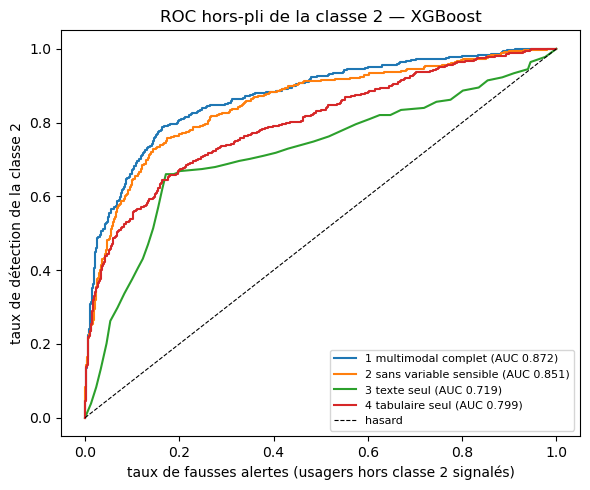

In [28]:
# Courbes ROC hors-pli de la classe 2, XGBoost, pour les quatre scénarios.
fig, ax = plt.subplots(figsize=(6, 5))
for nom_scenario in scenarios:
    probas = probas_oof_scenarios[(nom_scenario, "XGBoost")]
    taux_faux_positifs, taux_vrais_positifs, _ = roc_curve((y_train_arr == 2).astype(int), probas[:, 2])
    ax.plot(taux_faux_positifs, taux_vrais_positifs,
            label=f"{nom_scenario.replace('_', ' ')} (AUC {auc(taux_faux_positifs, taux_vrais_positifs):.3f})")
ax.plot([0, 1], [0, 1], "k--", lw=0.8, label="hasard")
ax.set_xlabel("taux de fausses alertes (usagers hors classe 2 signalés)")
ax.set_ylabel("taux de détection de la classe 2")
ax.set_title("ROC hors-pli de la classe 2 — XGBoost")
ax.legend(fontsize=8, loc="lower right")
plt.tight_layout()
plt.show()

L'AUC confirme le classement obtenu avec le F1-macro, pour les deux modèles : Scénario 1 (0,862 et
0,861), Scénario 2 (0,840 et 0,837), Scénario 4 (0,794 et 0,798), Scénario 3 (0,741). Retirer la
nationalité coûte 0,022 (XGBoost) et 0,024 (LightGBM) d'AUC macro : le même ordre de grandeur que la
perte de F1-macro. Pour la classe 2, l'AUC du Scénario 2 atteint 0,851 avec XGBoost : le modèle
ordonne bien les usagers selon leur risque de chômage long, même si la règle de décision par défaut
(la classe la plus probable) en laisse passer une partie. Cette distinction entre « bien ordonner »
et « bien décider » est exactement ce qu'exploite l'ajustement du seuil .

### 7.4 Choix du scénario

| Scénario | Utilisable en production ? | Pourquoi |
|---|---|---|
| 1 — complet | Non | Il utilise la nationalité : un critère de discrimination interdit pour orienter un usager  |
| 2 — sans variable sensible | **Oui, retenu** | Meilleur F1-macro parmi les scénarios sans nationalité ; coût du retrait mesuré et assumé |
| 3 — texte seul | Non | Trop faible, et le plus exposé aux erreurs critiques |
| 4 — tabulaire | Non en l'état | Il contient la nationalité  |
| 4b — tabulaire sans nationalité | Pas en version 1 | Seule option possible pour un pré-tri avant l'entretien, mais nettement en dessous du Scénario 2 |

**Je retiens le Scénario 2.** Renoncer à la nationalité coûte 2,2 points de F1-macro avec XGBoost
 : c'est le prix d'un modèle utilisable légalement et défendable devant un usager. Pour le pré-tri avant entretien, la Scénario 4b serait la seule
candidate ; ses performances, plus faibles, ne justifient pas de l'utiliser pour orienter qui que ce
soit. Je la garde comme piste à réévaluer avec davantage de données .

**Et l'âge ?** C'est aussi un critère protégé par le droit de la non-discrimination. Je le conserve
dans le Scénario 2, mais seulement après avoir mesuré ce que coûterait son retrait et défini des
garde-fous.

## 8. Réduction des erreurs critiques et choix du modèle

Le Scénario 2 laisse passer, par défaut, 12,7 % d'erreurs critiques avec XGBoost. L'énoncé
suggère deux leviers : **donner plus de poids à la classe 2** pendant l'apprentissage, et **abaisser
le seuil de décision** de la classe 2. Je les teste séparément, puis ensemble, toujours en validation
croisée sur l'entraînement.

**La règle de décision est fixée avant de regarder les résultats.** Je retiens la combinaison qui
minimise l'erreur critique parmi celles dont le F1-macro reste au moins égal à un plancher. Ce
plancher vaut 0,68 : c'est le F1-macro de XGBoost sur le Scénario 2 sans aucun réglage (0,683),
arrondi au centième inférieur. Autrement dit, je m'autorise à réduire les erreurs graves à condition
de ne pas dégrader la qualité globale au-delà de cet arrondi.

**Deux façons de calculer les métriques.** Aux sections 6 et , je faisais la moyenne des 5 plis.
Ici, pour comparer des seuils, je rassemble les probabilités hors-pli des 2 000 usagers et je calcule
la métrique une seule fois : c'est plus stable pour des seuils fins. Les deux calculs diffèrent
légèrement ; je précise à chaque fois lequel j'utilise.

In [29]:
X_s2_train = scenarios["2_sans_variable_sensible"]["X_train"]
X_s2_test = scenarios["2_sans_variable_sensible"]["X_test"]
PLANCHER_F1 = 0.68


def probas_oof(X, classe_modele, poids_classe2=None, **parametres):
    """Probabilités hors-pli : chaque usager est prédit par un modèle qui ne l'a pas vu."""
    probas = np.zeros((X.shape[0], 3))
    for idx_app, idx_val in cv.split(X, y_train_arr):
        modele = classe_modele(**parametres)
        if poids_classe2 is None:
            modele.fit(X[idx_app], y_train_arr[idx_app])
        else:
            poids = compute_sample_weight({0: 1, 1: 1, 2: poids_classe2}, y_train_arr[idx_app])
            modele.fit(X[idx_app], y_train_arr[idx_app], sample_weight=poids)
        probas[idx_val] = modele.predict_proba(X[idx_val])
    return probas


def predire_avec_seuil(probas, seuil):
    """Classe 2 dès que sa probabilité atteint le seuil ; sinon, la plus probable des classes 0 et 1."""
    return np.where(probas[:, 2] >= seuil, 2, np.argmax(probas[:, :2], axis=1))


def mesurer(y_vrai, y_pred):
    """F1-macro, part et nombre d'erreurs critiques."""
    matrice = confusion_matrix(y_vrai, y_pred, labels=[0, 1, 2])
    return {"f1_macro": f1_score(y_vrai, y_pred, average="macro"),
            "erreur_critique": matrice[2, 0] / matrice[2].sum(),
            "erreurs_critiques": int(matrice[2, 0])}

### 8.1 Premier levier : pondérer la classe 2

f1_macro_cv         erreur_critique_cv        
modele           LightGBM XGBoost           LightGBM XGBoost
poids_classe2                                               
1                   0.669   0.683              0.132   0.127
2                   0.680   0.678              0.110   0.121
3                   0.674   0.669              0.113   0.110
4                   0.667   0.671              0.119   0.110
5                   0.670   0.672              0.108   0.105
6                   0.675   0.675              0.108   0.108
8                   0.664   0.663              0.108   0.108
10                  0.664   0.663              0.108   0.099
15                  0.660   0.657              0.113   0.094

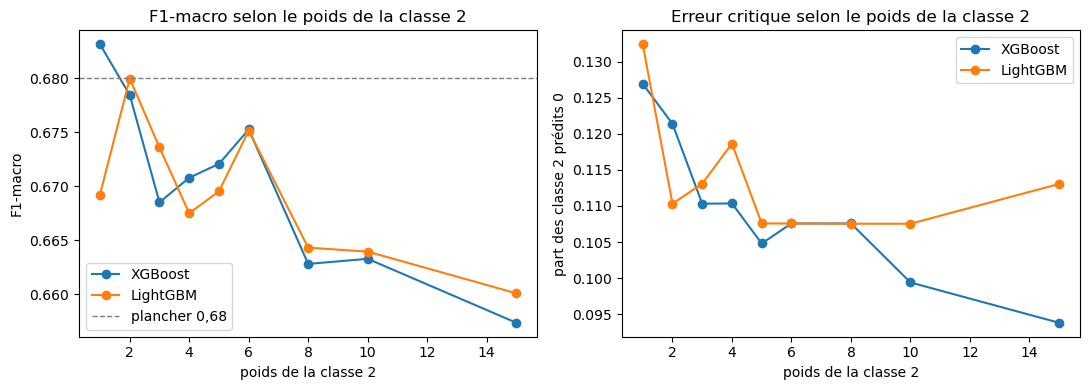

In [30]:
def evaluer_ponderation(classe_modele, poids_classe2, **parametres):
    """F1-macro et erreur critique moyens sur les 5 plis (moyenne par pli)."""
    f1_plis, erreurs_plis = [], []
    for idx_app, idx_val in cv.split(X_s2_train, y_train_arr):
        poids = compute_sample_weight({0: 1, 1: 1, 2: poids_classe2}, y_train_arr[idx_app])
        modele = classe_modele(**parametres).fit(X_s2_train[idx_app], y_train_arr[idx_app], sample_weight=poids)
        prediction = modele.predict(X_s2_train[idx_val])
        f1_plis.append(f1_score(y_train_arr[idx_val], prediction, average="macro"))
        erreurs_plis.append(erreur_critique(y_train_arr[idx_val], prediction))
    return np.mean(f1_plis), np.mean(erreurs_plis)


poids_a_tester = [1, 2, 3, 4, 5, 6, 8, 10, 15]
lignes_ponderation = []
for nom_modele, classe_modele, parametres in candidats_boosting:
    for poids in poids_a_tester:
        f1_moyen, erreur_moyenne = evaluer_ponderation(classe_modele, poids, **parametres)
        lignes_ponderation.append({"modele": nom_modele, "poids_classe2": poids,
                                   "f1_macro_cv": f1_moyen, "erreur_critique_cv": erreur_moyenne})
ponderation_df = pd.DataFrame(lignes_ponderation).set_index(["modele", "poids_classe2"])
display(ponderation_df.unstack("modele").round(3))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for nom_modele, _, _ in candidats_boosting:
    bloc = ponderation_df.loc[nom_modele]
    axes[0].plot(bloc.index, bloc["f1_macro_cv"], "o-", label=nom_modele)
    axes[1].plot(bloc.index, bloc["erreur_critique_cv"], "o-", label=nom_modele)
axes[0].axhline(PLANCHER_F1, color="grey", ls="--", lw=1, label="plancher 0,68")
axes[0].set(title="F1-macro selon le poids de la classe 2", xlabel="poids de la classe 2", ylabel="F1-macro")
axes[1].set(title="Erreur critique selon le poids de la classe 2", xlabel="poids de la classe 2", ylabel="part des classe 2 prédits 0")
axes[0].legend(); axes[1].legend()
plt.tight_layout()
plt.show()


La pondération agit dans le bon sens, mais lentement. Avec XGBoost, passer d'un poids de 1 à un
poids de 15 fait baisser l'erreur critique de 12,7 % à 9,4 %, tandis que le F1-macro descend de 0,683
à 0,657, sous le plancher. Surpondérer la classe 2 pousse le modèle à la prédire plus souvent, y
compris pour des usagers qui n'en relèvent pas : les classes 0 et 1 en pâtissent.

### 8.2 Second levier : abaisser le seuil de la classe 2

Par défaut, le modèle prédit la classe la plus probable (règle « argmax »). Avec un seuil, je
prédis la classe 2 dès que sa probabilité dépasse une valeur fixée, même si une autre classe est plus
probable ; sinon, je choisis la plus probable des classes 0 et 1.

f1_macro  erreur_critique  erreurs_critiques
modele   regle                                                   
XGBoost  argmax         0.683            0.127                 46
         seuil 0.50     0.676            0.138                 50
         seuil 0.40     0.689            0.127                 46
         seuil 0.35     0.687            0.122                 44
         seuil 0.30     0.689            0.116                 42
         seuil 0.25     0.683            0.110                 40
         seuil 0.20     0.684            0.099                 36
         seuil 0.15     0.669            0.088                 32
         seuil 0.10     0.636            0.077                 28
LightGBM argmax         0.669            0.133                 48
         seuil 0.50     0.660            0.144                 52
         seuil 0.40     0.677            0.127                 46
         seuil 0.35     0.678            0.122                 44
         seuil 0.30     0.667            0.122                 44
         seuil 0.25     0.665            0.119                 43
         seuil 0.20     0.663            0.116                 42
         seuil 0.15     0.649            0.102                 37
         seuil 0.10     0.637            0.080                 29

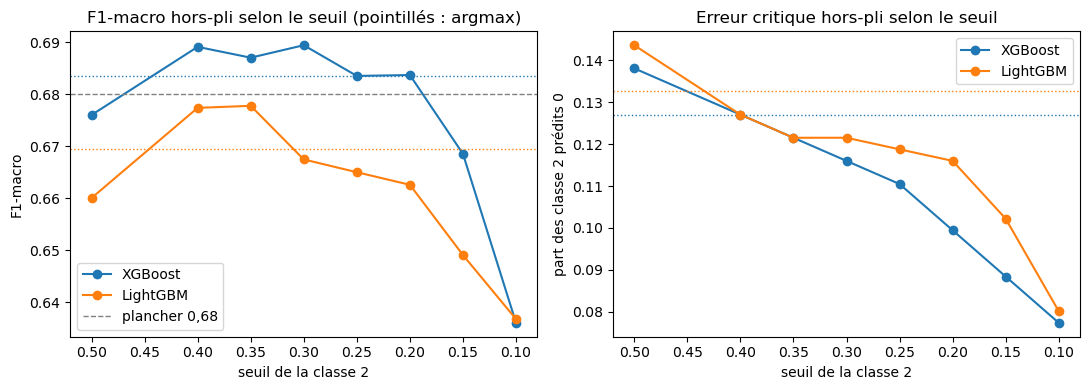

In [31]:
# Les probabilités hors-pli du Scénario 2 ont déjà été calculées au § 7.1 : je les réutilise.
probas_oof_par_modele = {nom: probas_oof_scenarios[("2_sans_variable_sensible", nom)] for nom, _, _ in candidats_boosting}
seuils_a_tester = [0.50, 0.40, 0.35, 0.30, 0.25, 0.20, 0.15, 0.10]
lignes_seuil = []
for nom_modele, probas in probas_oof_par_modele.items():
    lignes_seuil.append({"modele": nom_modele, "regle": "argmax", "seuil": np.nan, **mesurer(y_train_arr, probas.argmax(axis=1))})
    for seuil in seuils_a_tester:
        lignes_seuil.append({"modele": nom_modele, "regle": f"seuil {seuil:.2f}", "seuil": seuil,
                             **mesurer(y_train_arr, predire_avec_seuil(probas, seuil))})
seuils_df = pd.DataFrame(lignes_seuil)
display(seuils_df.drop(columns="seuil").set_index(["modele", "regle"]).round(3))

reference_argmax = seuils_df[seuils_df["regle"] == "argmax"].set_index("modele")
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for nom_modele in probas_oof_par_modele:
    bloc = seuils_df[(seuils_df["modele"] == nom_modele) & seuils_df["seuil"].notna()]
    ligne, = axes[0].plot(bloc["seuil"], bloc["f1_macro"], "o-", label=nom_modele)
    axes[0].axhline(reference_argmax.loc[nom_modele, "f1_macro"], color=ligne.get_color(), ls=":", lw=1)
    axes[1].plot(bloc["seuil"], bloc["erreur_critique"], "o-", color=ligne.get_color(), label=nom_modele)
    axes[1].axhline(reference_argmax.loc[nom_modele, "erreur_critique"], color=ligne.get_color(), ls=":", lw=1)
axes[0].axhline(PLANCHER_F1, color="grey", ls="--", lw=1, label="plancher 0,68")
axes[0].set(title="F1-macro hors-pli selon le seuil (pointillés : argmax)", xlabel="seuil de la classe 2", ylabel="F1-macro")
axes[1].set(title="Erreur critique hors-pli selon le seuil", xlabel="seuil de la classe 2", ylabel="part des classe 2 prédits 0")
axes[0].invert_xaxis(); axes[1].invert_xaxis()
axes[0].legend(); axes[1].legend()
plt.tight_layout()
plt.show()

Le seuil est un levier beaucoup plus efficace que la pondération. Pour XGBoost, en descendant de 0,50
à 0,20, l'erreur critique hors-pli passe de 13,8 % à 9,9 %, alors que le F1-macro reste stable
(0,676 au seuil 0,50, 0,684 au seuil 0,20) : on détecte davantage d'usagers de classe 2 sans
dégrader la qualité globale. En dessous de 0,20, le F1-macro décroche (0,669 à 0,15, 0,636 à 0,10) :
le modèle signale trop d'usagers en classe 2 à tort. LightGBM suit la même tendance, en moins bien
(0,663 et 11,6 % au seuil 0,20).

Pourquoi le seuil fait mieux que la pondération ? Le modèle ordonne déjà bien les usagers selon leur
risque (AUC de la classe 2 de 0,851, ) : il suffit de déplacer la frontière de décision, sans
réapprendre un modèle déformé par les poids.

### 8.3 Les deux leviers ensemble

In [32]:
lignes_combinees = []
for nom_modele, classe_modele, parametres in candidats_boosting:
    probas_ponderees = probas_oof(X_s2_train, classe_modele, poids_classe2=3, **parametres)
    for seuil in [0.40, 0.30, 0.25, 0.20, 0.15]:
        lignes_combinees.append({"modele": nom_modele, "poids_classe2": 3, "seuil": seuil,
                                 **mesurer(y_train_arr, predire_avec_seuil(probas_ponderees, seuil))})
combinees_df = pd.DataFrame(lignes_combinees).set_index(["modele", "seuil"])
display(combinees_df.round(3))

poids_classe2  f1_macro  erreur_critique  erreurs_critiques
modele   seuil                                                             
XGBoost  0.40               3     0.671            0.105                 38
         0.30               3     0.668            0.097                 35
         0.25               3     0.660            0.091                 33
         0.20               3     0.652            0.072                 26
         0.15               3     0.633            0.061                 22
LightGBM 0.40               3     0.677            0.110                 40
         0.30               3     0.667            0.097                 35
         0.25               3     0.659            0.097                 35
         0.20               3     0.652            0.088                 32
         0.15               3     0.641            0.075                 27

Combiner les deux leviers fait descendre l'erreur critique encore plus bas (7,2 % avec XGBoost, poids
3 et seuil 0,20), mais le F1-macro tombe à 0,652. Aucune des dix combinaisons testées ne respecte le
plancher de 0,68 : les deux leviers poussent dans le même sens, et les cumuler revient à signaler trop
d'usagers en classe 2. Je garde cette option en réserve, pour le cas où l'agence voudrait privilégier
encore plus nettement la détection des situations à risque.

### 8.4 Choix de la combinaison modèle × seuil

J'applique maintenant la règle fixée en introduction à une grille de 21 combinaisons : les trois
familles de modèles, dont Random Forest, et sept seuils.

In [33]:
probas_grille = dict(probas_oof_par_modele)
probas_grille["Random Forest"] = probas_oof(X_s2_train, RandomForestClassifier, n_estimators=300, random_state=GRAINE, n_jobs=-1)
seuils_grille = [0.50, 0.40, 0.35, 0.30, 0.25, 0.20, 0.15]
grille_df = pd.DataFrame([
    {"modele": nom_modele, "seuil": seuil, **mesurer(y_train_arr, predire_avec_seuil(probas, seuil))}
    for nom_modele, probas in probas_grille.items() for seuil in seuils_grille
])
eligibles = grille_df[grille_df["f1_macro"] >= PLANCHER_F1]
if eligibles.empty:
    raise RuntimeError("Aucune combinaison ne respecte le plancher de F1-macro : la règle de décision ne peut pas s'appliquer. "
                       "Vérifier les versions des bibliothèques (§ 2) avant d'aller plus loin.")
gagnant = eligibles.loc[eligibles["erreur_critique"].idxmin()]
MODELE_RETENU, SEUIL_RETENU = gagnant["modele"], float(gagnant["seuil"])

display(grille_df.pivot(index="seuil", columns="modele", values="f1_macro").sort_index(ascending=False).round(3)
        .style.set_caption("F1-macro hors-pli"))
display(grille_df.pivot(index="seuil", columns="modele", values="erreur_critique").sort_index(ascending=False).round(3)
        .style.set_caption("Erreur critique hors-pli"))
print(f"Combinaisons testées : {len(grille_df)} | éligibles (F1-macro ≥ {PLANCHER_F1}) : {len(eligibles)}")
print(f"Retenu : {MODELE_RETENU}, seuil {SEUIL_RETENU:.2f} — F1-macro {gagnant['f1_macro']:.4f}, "
      f"erreur critique {gagnant['erreur_critique']:.4f} ({gagnant['erreurs_critiques']} sur {int((y_train_arr == 2).sum())})")

modele,LightGBM,Random Forest,XGBoost
seuil,,,
0.500000,0.660000,0.645000,0.676000
0.400000,0.677000,0.652000,0.689000
0.350000,0.678000,0.660000,0.687000
0.300000,0.667000,0.656000,0.689000
0.250000,0.665000,0.652000,0.683000
0.200000,0.663000,0.642000,0.684000
0.150000,0.649000,0.619000,0.669000


modele,LightGBM,Random Forest,XGBoost
seuil,,,
0.500000,0.144000,0.218000,0.138000
0.400000,0.127000,0.199000,0.127000
0.350000,0.122000,0.171000,0.122000
0.300000,0.122000,0.157000,0.116000
0.250000,0.119000,0.127000,0.110000
0.200000,0.116000,0.099000,0.099000
0.150000,0.102000,0.061000,0.088000


Combinaisons testées : 21 | éligibles (F1-macro ≥ 0.68) : 5
Retenu : XGBoost, seuil 0.20 — F1-macro 0.6837, erreur critique 0.0994 (36 sur 362)


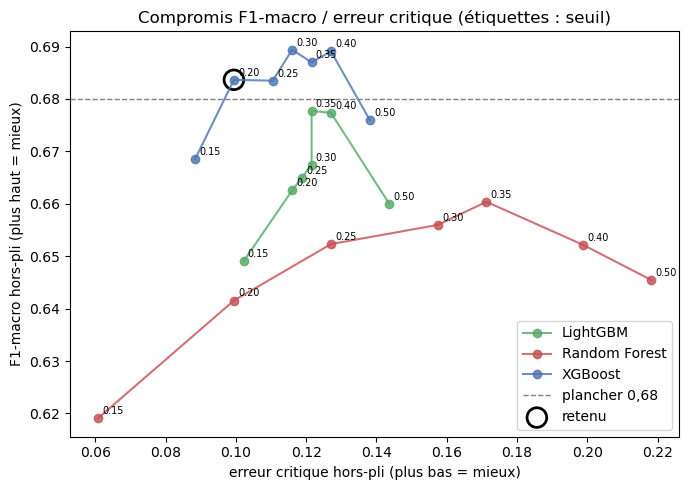

In [34]:
fig, ax = plt.subplots(figsize=(7, 5))
couleurs = {"XGBoost": "#4c72b0", "LightGBM": "#55a868", "Random Forest": "#c44e52"}
for nom_modele, bloc in grille_df.groupby("modele"):
    ax.plot(bloc["erreur_critique"], bloc["f1_macro"], "o-", color=couleurs[nom_modele], label=nom_modele, alpha=0.8)
    for _, ligne in bloc.iterrows():
        ax.annotate(f"{ligne['seuil']:.2f}", (ligne["erreur_critique"], ligne["f1_macro"]), fontsize=7,
                    xytext=(3, 3), textcoords="offset points")
ax.axhline(PLANCHER_F1, color="grey", ls="--", lw=1, label="plancher 0,68")
ax.scatter([gagnant["erreur_critique"]], [gagnant["f1_macro"]], s=200, facecolors="none", edgecolors="black", lw=2, label="retenu")
ax.set_xlabel("erreur critique hors-pli (plus bas = mieux)")
ax.set_ylabel("F1-macro hors-pli (plus haut = mieux)")
ax.set_title("Compromis F1-macro / erreur critique (étiquettes : seuil)")
ax.legend()
plt.tight_layout()
plt.show()

**XGBoost au seuil 0,20 est retenu** : F1-macro hors-pli de 0,6837 et 36 erreurs critiques sur 362
usagers de classe 2, soit 9,9 %. Les cinq combinaisons qui respectent le plancher sont toutes des
réglages de XGBoost ; aucun réglage de LightGBM ni de Random Forest n'atteint 0,68.

Random Forest mérite une nuance : c'est lui qui atteint l'erreur critique la plus basse de toute la
grille (6,1 % au seuil 0,15), mais avec un F1-macro de 0,619, loin du plancher. Si l'agence décidait qu'éviter
les erreurs critiques prime sur tout le reste, c'est cette option qu'il faudrait regarder, en
acceptant davantage de fausses alertes. C'est un arbitrage métier, que je signale plutôt que de le
trancher seul.

### 8.5 Hyperparamètres : réglages effectifs, recherche aléatoire et stabilité

je garde les réglages par défaut. Je réponds en trois
temps : quels sont exactement ces réglages, une recherche aléatoire fait-elle mieux, et l'avance de
XGBoost sur LightGBM est-elle solide ?

In [35]:
modele_decrit = XGBClassifier(random_state=GRAINE, eval_metric="mlogloss").fit(X_s2_train, y_train_arr)
configuration = json.loads(modele_decrit.get_booster().save_config())
parametres_arbres = configuration["learner"]["gradient_booster"]["tree_train_param"]
nombre_arbres = modele_decrit.get_booster().num_boosted_rounds()
print("XGBoost — réglages effectifs, lus dans le modèle entraîné :")
print(f"   itérations de boosting : {nombre_arbres}")
for cle in ["max_depth", "learning_rate", "subsample", "colsample_bytree", "min_child_weight", "gamma", "reg_lambda"]:
    print(f"   {cle:18s}: {parametres_arbres.get(cle)}")
print(f"   objectif : {configuration['learner']['objective']['name']}")

defauts_lgbm = LGBMClassifier().get_params()
print("\nLightGBM :", {cle: defauts_lgbm[cle] for cle in ["n_estimators", "num_leaves", "learning_rate", "max_depth", "min_child_samples"]})
defauts_rf = RandomForestClassifier(n_estimators=300).get_params()
print("Random Forest :", {cle: defauts_rf[cle] for cle in ["n_estimators", "max_depth", "min_samples_leaf", "max_features"]})

XGBoost — réglages effectifs, lus dans le modèle entraîné :
   itérations de boosting : 100
   max_depth         : 6
   learning_rate     : 0.300000012
   subsample         : 1
   colsample_bytree  : 1
   min_child_weight  : 1
   gamma             : 0
   reg_lambda        : 1
   objectif : multi:softprob

LightGBM : {'n_estimators': 100, 'num_leaves': 31, 'learning_rate': 0.1, 'max_depth': -1, 'min_child_samples': 20}
Random Forest : {'n_estimators': 300, 'max_depth': None, 'min_samples_leaf': 1, 'max_features': 'sqrt'}


In [36]:
# Recherche aléatoire : 30 configurations par modèle, évaluées au seuil retenu, hors-pli.
# Durée : quelques minutes (300 entraînements par modèle).
grilles_hyperparametres = {
    "XGBoost": {"n_estimators": randint(150, 700), "max_depth": randint(2, 7),
                "learning_rate": loguniform(0.01, 0.25), "subsample": uniform(0.6, 0.4),
                "colsample_bytree": uniform(0.5, 0.5), "min_child_weight": randint(1, 12),
                "reg_lambda": loguniform(0.5, 20), "gamma": uniform(0, 1.5)},
    "LightGBM": {"n_estimators": randint(150, 700), "num_leaves": randint(8, 64),
                 "learning_rate": loguniform(0.01, 0.25), "subsample": uniform(0.6, 0.4),
                 "subsample_freq": randint(1, 3), "colsample_bytree": uniform(0.5, 0.5),
                 "min_child_samples": randint(5, 60), "reg_lambda": loguniform(0.5, 20)},
}
lignes_recherche = []
for nom_modele, classe_modele, parametres in candidats_boosting:
    lignes_recherche.append({"modele": nom_modele, "configuration": "par défaut", "reglages": {},
                             **mesurer(y_train_arr, predire_avec_seuil(probas_oof_par_modele[nom_modele], SEUIL_RETENU))})
    for i, tirage in enumerate(ParameterSampler(grilles_hyperparametres[nom_modele], n_iter=30, random_state=7)):
        probas = probas_oof(X_s2_train, classe_modele, **{**parametres, **tirage})
        lignes_recherche.append({"modele": nom_modele, "configuration": f"essai_{i:02d}", "reglages": tirage,
                                 **mesurer(y_train_arr, predire_avec_seuil(probas, SEUIL_RETENU))})
recherche_df = pd.DataFrame(lignes_recherche)

bilan_recherche = {}
for nom_modele, bloc in recherche_df.groupby("modele", sort=False):
    eligibles_hp = bloc[bloc["f1_macro"] >= PLANCHER_F1]
    meilleure_erreur = eligibles_hp.loc[eligibles_hp["erreur_critique"].idxmin()] if len(eligibles_hp) else None
    meilleur_f1 = bloc.loc[bloc["f1_macro"].idxmax()]
    bilan_recherche[nom_modele] = {"eligibles": len(eligibles_hp), "testees": len(bloc),
                                   "retenue": None if meilleure_erreur is None else meilleure_erreur["configuration"]}
    print(f"{nom_modele} : {len(eligibles_hp)} configurations éligibles sur {len(bloc)}")
    if meilleure_erreur is not None:
        print(f"   la moins exposée aux erreurs critiques : {meilleure_erreur['configuration']} "
              f"(F1 {meilleure_erreur['f1_macro']:.4f}, erreur {meilleure_erreur['erreur_critique']:.4f})")
    print(f"   la meilleure en F1-macro : {meilleur_f1['configuration']} "
          f"(F1 {meilleur_f1['f1_macro']:.4f}, erreur {meilleur_f1['erreur_critique']:.4f})")
display(recherche_df.sort_values(["modele", "f1_macro"], ascending=[True, False]).groupby("modele").head(5)
        .drop(columns="reglages").round(4))

XGBoost : 5 configurations éligibles sur 31
   la moins exposée aux erreurs critiques : par défaut (F1 0.6837, erreur 0.0994)
   la meilleure en F1-macro : essai_20 (F1 0.6864, erreur 0.1077)
LightGBM : 1 configurations éligibles sur 31
   la moins exposée aux erreurs critiques : essai_15 (F1 0.6817, erreur 0.1188)
   la meilleure en F1-macro : essai_15 (F1 0.6817, erreur 0.1188)


,modele,configuration,f1_macro,erreur_critique,erreurs_critiques
47,LightGBM,essai_15,0.682,0.119,43
36,LightGBM,essai_04,0.680,0.105,38
35,LightGBM,essai_03,0.675,0.099,36
51,LightGBM,essai_19,0.675,0.116,42
42,LightGBM,essai_10,0.672,0.113,41
21,XGBoost,essai_20,0.686,0.108,39
16,XGBoost,essai_15,0.685,0.116,42
9,XGBoost,essai_08,0.684,0.116,42
0,XGBoost,par défaut,0.684,0.099,36
30,XGBoost,essai_29,0.682,0.113,41


**La recherche aléatoire ne justifie pas de quitter les réglages par défaut.** Sur 31 configurations
de XGBoost (les réglages par défaut et 30 tirages), 5 respectent le plancher, et c'est la
configuration par défaut qui fait le moins d'erreurs critiques. La meilleure en F1-macro, `essai_20`
(0,6864), ne gagne que 0,0027 de F1-macro pour 0,0083 d'erreur critique en plus (10,77 % contre
9,94 %) : un mauvais échange au regard du critère métier. Côté LightGBM, une seule configuration sur
31 passe le plancher (`essai_15`), avec 11,88 % d'erreurs critiques.

Garder les réglages par défaut est donc un choix mesuré, pas un oubli : 100 arbres de profondeur 6,
un taux d'apprentissage de 0,3. Une limite : la recherche est évaluée sur les mêmes plis que ceux qui
ont servi à choisir le seuil ; l'évaluation sur le test reste la seule mesure indépendante.

In [37]:
# Stabilité : 5 plis × 4 répétitions, avec un autre découpage que celui des sections précédentes.
cv_repetee = RepeatedStratifiedKFold(n_splits=5, n_repeats=4, random_state=7)
f1_repetes, erreurs_repetees = {}, {}
for nom_modele, classe_modele, parametres in candidats_boosting:
    f1_plis, erreurs_plis = [], []
    for idx_app, idx_val in cv_repetee.split(X_s2_train, y_train_arr):
        modele = classe_modele(**parametres).fit(X_s2_train[idx_app], y_train_arr[idx_app])
        mesure = mesurer(y_train_arr[idx_val], predire_avec_seuil(modele.predict_proba(X_s2_train[idx_val]), SEUIL_RETENU))
        f1_plis.append(mesure["f1_macro"])
        erreurs_plis.append(mesure["erreur_critique"])
    f1_repetes[nom_modele], erreurs_repetees[nom_modele] = np.array(f1_plis), np.array(erreurs_plis)
    print(f"{nom_modele:9s} — F1-macro {np.mean(f1_plis):.4f} ± {np.std(f1_plis):.4f} | erreur critique {np.mean(erreurs_plis):.4f}")

difference = f1_repetes["XGBoost"] - f1_repetes["LightGBM"]
nombre_plis = len(difference)
test_classique = stats.ttest_rel(f1_repetes["XGBoost"], f1_repetes["LightGBM"])
# Correction de Nadeau et Bengio : les 20 mesures ne sont pas indépendantes (les apprentissages se
# recouvrent). Le test classique sous-estime la variance ; on la corrige par le rapport des tailles
# validation / apprentissage (400 / 1 600).
rapport_tailles = 1 / (5 - 1)
t_corrige = difference.mean() / np.sqrt((1 / nombre_plis + rapport_tailles) * difference.var(ddof=1))
p_corrige = 2 * stats.t.sf(abs(t_corrige), df=nombre_plis - 1)
print(f"\nÉcart moyen XGBoost − LightGBM : {difference.mean():+.4f} | XGBoost devant sur {int((difference > 0).sum())} plis sur {nombre_plis}")
print(f"Test t apparié classique : p = {test_classique.pvalue:.4f}")
print(f"Test t corrigé (Nadeau et Bengio) : t = {t_corrige:.2f}, p = {p_corrige:.3f}")

XGBoost   — F1-macro 0.6713 ± 0.0197 | erreur critique 0.0938
LightGBM  — F1-macro 0.6644 ± 0.0182 | erreur critique 0.1056

Écart moyen XGBoost − LightGBM : +0.0068 | XGBoost devant sur 15 plis sur 20
Test t apparié classique : p = 0.0063
Test t corrigé (Nadeau et Bengio) : t = 1.25, p = 0.226


Sur 20 découpages différents, XGBoost garde l'avantage : F1-macro de 0,6713 contre 0,6644, erreur
critique de 9,38 % contre 10,56 %, et il est devant sur 15 plis sur 20. Le test t apparié classique
donne p = 0,0063, ce qui semblerait très significatif. Mais ce test suppose des mesures
indépendantes, alors que les 20 apprentissages partagent l'essentiel de leurs données : il est connu
pour être trop optimiste dans ce cas. Avec la correction de Nadeau et Bengio, qui tient compte de ce
recouvrement, l'écart **n'est plus significatif** (p affichée ci-dessus).

Ma conclusion est donc mesurée : XGBoost est constamment un peu devant, notamment sur les erreurs
critiques, mais l'écart avec LightGBM est faible. Le choix de XGBoost repose sur la règle métier
 et sur cette régularité, pas sur une supériorité statistique démontrée.

### 8.6 Deux contrôles de la méthode : lignes incohérentes et préparation par pli

**Premier contrôle.** Les 51 dossiers incohérents du paragraphe 4.3 ont été gardés. Et si leur présence
dégradait le modèle ? Je compare, pli par pli, un modèle entraîné sur toutes les lignes et un modèle
entraîné sans les lignes incohérentes, tous deux évalués sur les mêmes lignes cohérentes de
validation.

In [38]:
masque_incoherent = X_train["anciennete_incoherente"].to_numpy().astype(bool)
print(f"Dossiers incohérents dans l'entraînement : {int(masque_incoherent.sum())} ({masque_incoherent.mean():.2%})")
lignes_sensibilite = []
for pli, (idx_app, idx_val) in enumerate(cv.split(X_s2_train, y_train_arr), start=1):
    idx_val_coherents = idx_val[~masque_incoherent[idx_val]]
    for variante, idx_ajustement in [("toutes les lignes", idx_app), ("sans les lignes incohérentes", idx_app[~masque_incoherent[idx_app]])]:
        modele = XGBClassifier(random_state=GRAINE, eval_metric="mlogloss").fit(X_s2_train[idx_ajustement], y_train_arr[idx_ajustement])
        prediction = predire_avec_seuil(modele.predict_proba(X_s2_train[idx_val_coherents]), SEUIL_RETENU)
        lignes_sensibilite.append({"pli": pli, "variante": variante, **mesurer(y_train_arr[idx_val_coherents], prediction)})
sensibilite_df = pd.DataFrame(lignes_sensibilite)
display(sensibilite_df.groupby("variante")[["f1_macro", "erreur_critique"]].agg(["mean", "std"]).round(4))
ecarts_par_pli = sensibilite_df.pivot(index="pli", columns="variante", values="f1_macro")
ecarts_par_pli = ecarts_par_pli["sans les lignes incohérentes"] - ecarts_par_pli["toutes les lignes"]
print("Écart de F1-macro par pli (sans − avec) :", ecarts_par_pli.round(4).tolist())

Dossiers incohérents dans l'entraînement : 45 (2.25%)


f1_macro        erreur_critique       
                                 mean    std            mean    std
variante                                                           
sans les lignes incohérentes    0.677  0.031           0.093  0.046
toutes les lignes               0.685  0.024           0.093  0.050

Écart de F1-macro par pli (sans − avec) : [-0.0226, 0.002, 0.0047, -0.0024, -0.0237]


Retirer les lignes incohérentes n'aide pas : le F1-macro moyen passe de 0,6854 à 0,6770 (−0,0084),
l'erreur critique moyenne est identique (9,31 %), et l'écart change de signe d'un pli à l'autre. Ces
lignes ne dégradent donc pas le modèle ; les garder, avec leur indicateur, est le choix le plus
simple et le plus honnête.

**Second contrôle.** Jusqu'ici, l'imputation, le one-hot et le TF-IDF ont été appris une fois sur les
2 000 lignes d'entraînement : dans la validation croisée, le pli de validation a donc un peu
influencé la préparation. Je refais le calcul en réapprenant toute la préparation à
l'intérieur de chaque pli, sur les seules lignes d'apprentissage.

In [39]:
# Lignes brutes de l'entraînement, avant toute imputation ; les indicateurs de manque ne dépendent que de la ligne.
brut_train = df.loc[X_train.index].reset_index(drop=True)
for colonne in colonnes_incompletes:
    brut_train[f"{colonne}_manquant"] = brut_train[colonne].isna().astype(int)


def matrices_du_pli(apprentissage, validation, sans_age=False):
    """Prépare un pli en apprenant imputation, one-hot et TF-IDF sur les seules lignes d'apprentissage."""
    apprentissage, validation = apprentissage.reset_index(drop=True), validation.reset_index(drop=True)
    mediane_age = apprentissage["age"].median()
    mode_diplome = apprentissage["niveau_diplome"].mode()[0]
    mode_allocation = apprentissage["est_allocataire"].mode()[0]
    encodeur = OneHotEncoder(handle_unknown="ignore", sparse_output=True, dtype=np.float64)
    encodeur.fit(apprentissage[["departement", "code_rome_vise"]])
    vectoriseur = TfidfVectorizer(max_features=100).fit(apprentissage["synthese_entretien"].fillna("").astype(str))

    def assembler(bloc):
        colonnes = [bloc["age"].fillna(mediane_age), bloc["anciennete_poste_ans"],
                    bloc["niveau_diplome"].fillna(mode_diplome).map(mapping_diplome),
                    bloc["est_allocataire"].fillna(mode_allocation), bloc["age_manquant"],
                    bloc["niveau_diplome_manquant"], bloc["est_allocataire_manquant"],
                    bloc["synthese_entretien_manquant"], bloc["anciennete_incoherente"]]
        if sans_age:     # retire l'âge, son indicateur de manque et l'indicateur qui en dépend
            colonnes = [colonnes[i] for i in (1, 2, 3, 5, 6, 7)]
        numeriques = csr_matrix(np.column_stack([colonne.to_numpy(dtype=float) for colonne in colonnes]))
        return hstack([numeriques, encodeur.transform(bloc[["departement", "code_rome_vise"]]),
                       vectoriseur.transform(bloc["synthese_entretien"].fillna("").astype(str))]).tocsr()

    return assembler(apprentissage), assembler(validation)


def evaluer_preparation_par_pli(sans_age=False):
    """Probabilités hors-pli de XGBoost et F1-macro de chaque pli, préparation réapprise dans chaque pli."""
    probas, f1_plis = np.zeros((len(y_train_arr), 3)), []
    for idx_app, idx_val in cv.split(brut_train, y_train_arr):
        X_app, X_val = matrices_du_pli(brut_train.iloc[idx_app], brut_train.iloc[idx_val], sans_age)
        modele = XGBClassifier(random_state=GRAINE, eval_metric="mlogloss").fit(X_app, y_train_arr[idx_app])
        probas[idx_val] = modele.predict_proba(X_val)
        f1_plis.append(f1_score(y_train_arr[idx_val], predire_avec_seuil(probas[idx_val], SEUIL_RETENU), average="macro"))
    return probas, np.array(f1_plis)


probas_preparation_par_pli, f1_plis_preparation = evaluer_preparation_par_pli()
comparaison_preparation = pd.DataFrame({
    "préparation apprise sur les 2 000 lignes (protocole principal)": mesurer(y_train_arr, predire_avec_seuil(probas_oof_par_modele["XGBoost"], SEUIL_RETENU)),
    "préparation réapprise dans chaque pli": mesurer(y_train_arr, predire_avec_seuil(probas_preparation_par_pli, SEUIL_RETENU)),
}).T
display(comparaison_preparation.round(4))

,f1_macro,erreur_critique,erreurs_critiques
préparation apprise sur les 2 000 lignes (protocole principal),0.684,0.099,36.0
préparation réapprise dans chaque pli,0.683,0.105,38.0


L'effet est négligeable : F1-macro de 0,6833 au lieu de 0,6837, et 38 erreurs critiques au lieu de
36. La simplification du protocole principal ne biaise donc pas mes comparaisons. Ce second calcul
utilise un TF-IDF limité à 100 mots, sans effet ici puisque le vocabulaire n'en compte que 68. Je
réutilise cette fonction pour mesurer ce que coûterait le retrait de l'âge.

### 8.7 Le TF-IDF apporte-t-il plus qu'un simple codage des formulations ?

Le 3.7 a montré que la synthèse ne contient que 9 formulations. Un one-hot de ces formulations
(une colonne par formulation) pourrait suffire. Je compare les deux représentations dans le
Scénario 2, au seuil retenu.

In [40]:
ohe_texte = OneHotEncoder(handle_unknown="ignore", sparse_output=True).fit(X_train[["synthese_entretien"]])
texte_train_formulations = ohe_texte.transform(X_train[["synthese_entretien"]])
representations_texte = {
    "TF-IDF (68 mots)": X_s2_train,
    "one-hot des formulations": hstack([tabulaire_train_sans_sensible, texte_train_formulations]).tocsr(),
}
lignes_texte = []
for nom_representation, matrice in representations_texte.items():
    f1_plis = []
    for idx_app, idx_val in cv.split(matrice, y_train_arr):
        modele = XGBClassifier(random_state=GRAINE, eval_metric="mlogloss").fit(matrice[idx_app], y_train_arr[idx_app])
        f1_plis.append(f1_score(y_train_arr[idx_val], predire_avec_seuil(modele.predict_proba(matrice[idx_val]), SEUIL_RETENU), average="macro"))
    lignes_texte.append({"representation": nom_representation,
                         "colonnes_texte": matrice.shape[1] - tabulaire_train_sans_sensible.shape[1],
                         "f1_macro_moyen_par_pli": np.mean(f1_plis), "ecart_type": np.std(f1_plis)})
comparaison_texte = pd.DataFrame(lignes_texte).set_index("representation")
display(comparaison_texte.round(3))

,colonnes_texte,f1_macro_moyen_par_pli,ecart_type
representation,,,
TF-IDF (68 mots),68,0.683,0.017
one-hot des formulations,10,0.684,0.027


Sur ces données, les deux représentations font jeu égal (0,683 et 0,684). Le TF-IDF n'apporte donc
rien de plus **tant que les conseillers utilisent les 9 formulations types**. Je le garde pour une
raison qui se vérifie au paragraphe suivant : en production, un conseiller écrira librement, et un
one-hot ne reconnaîtrait plus aucune formulation nouvelle, alors que le TF-IDF retrouve des mots
connus.

### 8.8 Robustesse du texte face au bruit

L'énoncé demande d'évaluer le Scénario 3 face au « bruit stochastique » du texte. Le texte fourni ne
contient que des formulations propres : je simule donc des perturbations réalistes sur
les lignes de validation, sans jamais toucher aux lignes d'apprentissage :

- **mots supprimés** (10 % ou 30 % des mots), comme une saisie abrégée ;
- **fautes de frappe** (une lettre retirée dans 10 % ou 30 % des mots) ;
- **paraphrases** : j'ai réécrit chacune des 9 formulations avec d'autres mots, comme le ferait un
  conseiller qui n'utilise pas les formulations types.

Je compare trois modèles : le Scénario 3 avec TF-IDF, le Scénario 3 avec le one-hot des formulations,
et le modèle complet du Scénario 2. La règle de décision est l'argmax, pour isoler l'effet du texte.

,S3 TF-IDF,S3 one-hot,S2 complet
texte d'origine,0.635000,0.635000,0.683000
10 % des mots supprimés,0.579000,0.461000,0.651000
30 % des mots supprimés,0.501000,0.260000,0.622000
fautes de frappe (10 % des mots),0.604000,0.474000,0.666000
fautes de frappe (30 % des mots),0.574000,0.281000,0.651000
paraphrases,0.329000,0.228000,0.518000


,S3 TF-IDF,S3 one-hot,S2 complet
texte d'origine,0.191000,0.191000,0.127000
10 % des mots supprimés,0.191000,0.097000,0.116000
30 % des mots supprimés,0.334000,0.039000,0.127000
fautes de frappe (10 % des mots),0.193000,0.105000,0.127000
fautes de frappe (30 % des mots),0.224000,0.033000,0.133000
paraphrases,0.301000,0.028000,0.097000


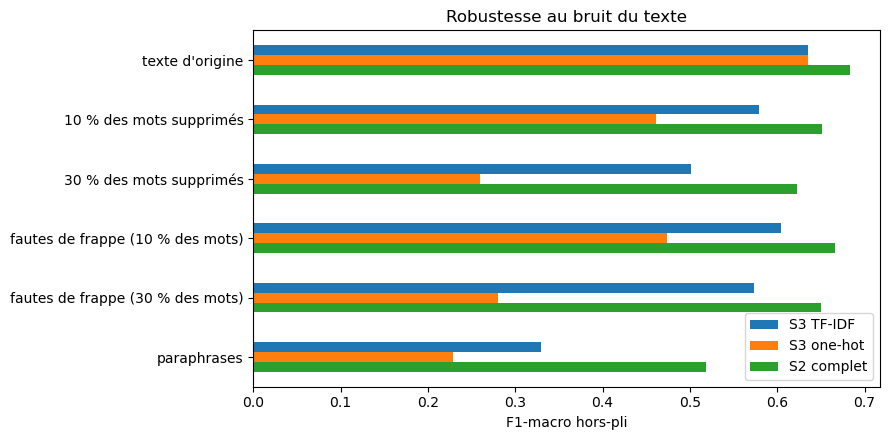

In [41]:
PARAPHRASES = {
    "compétences à réactualiser sur les outils numériques. motivation correcte.":
        "doit remettre à niveau ses compétences sur les outils informatiques, reste motivé.",
    "problème ponctuel de mobilité géographique. zone mal desservie.":
        "difficulté de mobilité passagère, habite un secteur peu desservi par les transports.",
    "profil autonome; recherche active; aucun frein périphérique identifié.":
        "personne autonome, en recherche active, pas de frein particulier.",
    "projet de reconversion à affiner. besoin d'une formation complémentaire.":
        "souhaite une reconversion, projet encore flou, une formation sera nécessaire.",
    "excellente présentation; compétences techniques à jour. reprise rapide visée.":
        "très bonne présentation, compétences à jour, vise une reprise rapide.",
    "candidat très dynamique; mobilité nationale validée. projet clair.":
        "candidate dynamique, prête à une mobilité nationale, projet professionnel clair.",
    "cumul de difficultés. pas de moyen de transport et garde d'enfants complexe.":
        "plusieurs difficultés : pas de véhicule, garde des enfants compliquée.",
    "perte de confiance importante. risque d'exclusion; barrière de la langue.":
        "manque de confiance en soi, risque d'isolement, maîtrise limitée de la langue.",
    "freins périphériques majeurs. situation d'illettrisme numérique constatée.":
        "freins importants, illettrisme numérique : ne sait pas utiliser un ordinateur.",
}


def cle_formulation(texte):
    """Neutralise la ponctuation « ; » ou « , » selon la version du fichier de données."""
    return re.sub(r"[;,]", ",", texte)


PARAPHRASES_NORMALISEES = {cle_formulation(origine): paraphrase for origine, paraphrase in PARAPHRASES.items()}


def paraphraser(texte, generateur=None):
    return PARAPHRASES_NORMALISEES.get(cle_formulation(texte), texte)


def supprimer_mots(texte, proportion, generateur):
    return " ".join(mot for mot in texte.split() if generateur.random() >= proportion)


def fautes_de_frappe(texte, proportion, generateur):
    def alterer(mot):
        if len(mot) > 3 and generateur.random() < proportion:
            position = int(generateur.integers(1, len(mot) - 1))
            return mot[:position] + mot[position + 1:]
        return mot
    return " ".join(alterer(mot) for mot in texte.split())


perturbations = {
    "texte d'origine": lambda texte, generateur: texte,
    "10 % des mots supprimés": lambda texte, generateur: supprimer_mots(texte, 0.10, generateur),
    "30 % des mots supprimés": lambda texte, generateur: supprimer_mots(texte, 0.30, generateur),
    "fautes de frappe (10 % des mots)": lambda texte, generateur: fautes_de_frappe(texte, 0.10, generateur),
    "fautes de frappe (30 % des mots)": lambda texte, generateur: fautes_de_frappe(texte, 0.30, generateur),
    "paraphrases": paraphraser,
}
formulations_train = {cle_formulation(t) for t in X_train["synthese_entretien"] if t}

textes_train = X_train["synthese_entretien"].to_numpy()
predictions_bruit = {(representation, perturbation): np.zeros(len(y_train_arr), dtype=int)
                     for representation in ("S3 TF-IDF", "S3 one-hot", "S2 complet") for perturbation in perturbations}
for pli, (idx_app, idx_val) in enumerate(cv.split(X_s2_train, y_train_arr)):
    modeles_texte = {
        "S3 TF-IDF": XGBClassifier(random_state=GRAINE, eval_metric="mlogloss").fit(texte_train[idx_app], y_train_arr[idx_app]),
        "S3 one-hot": XGBClassifier(random_state=GRAINE, eval_metric="mlogloss").fit(texte_train_formulations[idx_app], y_train_arr[idx_app]),
        "S2 complet": XGBClassifier(random_state=GRAINE, eval_metric="mlogloss").fit(X_s2_train[idx_app], y_train_arr[idx_app]),
    }
    for numero, (perturbation, transformer) in enumerate(perturbations.items()):
        generateur = np.random.default_rng(GRAINE + 100 * numero + pli)
        textes = [transformer(texte, generateur) for texte in textes_train[idx_val]]
        vecteurs = tfidf.transform(textes)
        matrices = {
            "S3 TF-IDF": vecteurs,
            "S3 one-hot": ohe_texte.transform(pd.DataFrame({"synthese_entretien": textes})),
            "S2 complet": hstack([tabulaire_train_sans_sensible[idx_val], vecteurs]).tocsr(),
        }
        for representation, modele in modeles_texte.items():
            predictions_bruit[(representation, perturbation)][idx_val] = modele.predict(matrices[representation])

robustesse = pd.DataFrame(
    {representation: {perturbation: f1_score(y_train_arr, predictions_bruit[(representation, perturbation)], average="macro")
                      for perturbation in perturbations} for representation in ("S3 TF-IDF", "S3 one-hot", "S2 complet")})
erreurs_bruit = pd.DataFrame(
    {representation: {perturbation: erreur_critique(y_train_arr, predictions_bruit[(representation, perturbation)])
                      for perturbation in perturbations} for representation in ("S3 TF-IDF", "S3 one-hot", "S2 complet")})
display(robustesse.round(3).style.set_caption("F1-macro hors-pli (argmax) selon la perturbation du texte"))
display(erreurs_bruit.round(3).style.set_caption("Erreur critique hors-pli selon la perturbation du texte"))

ax = robustesse.plot(kind="barh", figsize=(9, 4.5))
ax.set_xlabel("F1-macro hors-pli")
ax.set_title("Robustesse au bruit du texte")
ax.invert_yaxis()
plt.tight_layout()
plt.show()


**Ce que montre ce test** (les pertes exactes sont affichées ci-dessus) :

- **Le texte seul est fragile.** Dès que des mots disparaissent ou changent, le Scénario 3 perd une
  partie de son signal : il ne repose que sur quelques mots-clés.
- **Face aux paraphrases, le TF-IDF résiste mieux que le one-hot.** Le one-hot ne reconnaît qu'une
  formulation écrite exactement à l'identique ; une paraphrase devient pour lui un texte inconnu. Le
  TF-IDF retrouve les mots communs (« mobilité », « formation », « freins »…). C'est la raison pour
  laquelle je garde le TF-IDF.
- **Le modèle complet amortit le bruit**, parce que les variables administratives prennent le relais
  quand le texte devient moins lisible.

Deux limites à garder en tête : les paraphrases sont écrites par moi, donc un échantillon restreint
et non représentatif des pratiques réelles ; et le vocabulaire nouveau (« véhicule », « ordinateur »)
est ignoré par le TF-IDF, qui ne connaît que les 68 mots de l'entraînement. En production, le
journal des synthèses permettra de mesurer cette dérive du vocabulaire.



### 8.9 Modèle final, coût d'inférence et éco-conception

J'entraîne maintenant le modèle final sur les 2 000 lignes d'entraînement, avec les réglages
retenus. C'est ce modèle, et lui seul, qui sera mesuré sur le jeu de test.

In [42]:
modele_final = XGBClassifier(random_state=GRAINE, eval_metric="mlogloss").fit(X_s2_train, y_train_arr)
modele_lightgbm_s2 = LGBMClassifier(random_state=GRAINE, verbose=-1).fit(X_s2_train, y_train_arr)

# Latence pour un usager, mesurée sur une ligne d'entraînement (le test reste intact jusqu'au § 9).
une_ligne = X_s2_train[[0]]
latences_modele = {}
for nom, modele in [("XGBoost (retenu)", modele_final), ("LightGBM", modele_lightgbm_s2)]:
    modele.predict_proba(une_ligne)
    debut = time.perf_counter()
    for _ in range(200):
        modele.predict_proba(une_ligne)
    latences_modele[nom] = (time.perf_counter() - debut) / 200 * 1000
latences_modele = pd.Series(latences_modele, name="latence_ms_pour_un_usager")
display(latences_modele.round(3).to_frame())

tampon = io.BytesIO()
joblib.dump(modele_final, tampon)
taille_modele_ko = tampon.getbuffer().nbytes / 1024
print(f"Taille du modèle sérialisé : {taille_modele_ko:.1f} Ko")

,latence_ms_pour_un_usager
XGBoost (retenu),0.897
LightGBM,1.602


Taille du modèle sérialisé : 581.9 Ko


In [43]:
# Ordre de grandeur de l'empreinte énergétique. Les trois constantes sont des HYPOTHÈSES, pas des mesures.
PUISSANCE_UN_COEUR_W = 15            # hypothèse : un cœur de serveur en charge
INFERENCES_PAR_AN = 3_000_000        # hypothèse : volume annuel d'entretiens de cadrage
INTENSITE_CARBONE_G_PAR_KWH = 56     # hypothèse : ordre de grandeur du mix électrique français
HEURES_PAR_AN = 24 * 365

debut = time.perf_counter()
XGBClassifier(random_state=GRAINE, eval_metric="mlogloss").fit(X_s2_train, y_train_arr)
duree_entrainement_s = time.perf_counter() - debut
latence_s = latences_modele["XGBoost (retenu)"] / 1000

energie_entrainement_kwh = PUISSANCE_UN_COEUR_W * duree_entrainement_s / 3.6e6
energie_inferences_an_kwh = PUISSANCE_UN_COEUR_W * latence_s * INFERENCES_PAR_AN / 3.6e6
energie_hebergement_an_kwh = PUISSANCE_UN_COEUR_W * HEURES_PAR_AN / 1000
empreinte = pd.DataFrame({
    "energie_kwh": [energie_entrainement_kwh, energie_inferences_an_kwh, energie_hebergement_an_kwh],
}, index=["un entraînement", "inférences d'une année", "un cœur allumé toute l'année"])
empreinte["co2e_g"] = empreinte["energie_kwh"] * INTENSITE_CARBONE_G_PAR_KWH
display(empreinte.style.format("{:.6f}"))
rapport_hebergement = energie_hebergement_an_kwh / energie_inferences_an_kwh
print(f"L'hébergement continu consomme {rapport_hebergement:,.0f} fois l'énergie des inférences de l'année.".replace(",", " "))

,energie_kwh,co2e_g
un entraînement,0.000001,0.000081
inférences d'une année,0.011213,0.627918
un cœur allumé toute l'année,131.400000,7358.400000


L'hébergement continu consomme 11 719 fois l'énergie des inférences de l'année.


**Ce que ces ordres de grandeur m'apprennent.** Le modèle retenu est léger (moins d'un mégaoctet) et
rapide (quelques millisecondes par usager). Avec mes hypothèses — que je
ne présente pas comme des mesures — l'énergie des prédictions d'une année entière est négligeable ;
ce qui pèse, c'est de laisser un serveur allumé en permanence. Les leviers d'éco-conception utiles
sont donc :

1. **un modèle sobre** : des arbres de boosting sur CPU, sans GPU ni grand modèle de langage, pour
   un gain de performance qu'aucun test ne justifie ici ;
2. **un hébergement dimensionné au juste besoin** : un seul conteneur, un cœur et moins d'un
   gigaoctet de mémoire suffisent.
3. **un réentraînement déclenché par un besoin mesuré** 

### 8.10 Décision

| Élément | Choix | Justification (validation croisée, jamais le test) |
|---|---|---|
| Scénario | 2 — sans la nationalité | Meilleur F1-macro sans variable sensible  |
| Modèle | XGBoost, réglages par défaut | Seul modèle qui respecte le plancher en réduisant les erreurs critiques  ; la recherche aléatoire ne fait pas mieux |
| Règle de décision | Classe 2 dès que sa probabilité atteint 0,20 | Erreur critique hors-pli de 9,9 % (36 sur 362) pour un F1-macro de 0,684  |
| Écart avec LightGBM | Faible et non significatif après correction | Choix fondé sur la règle métier, pas sur un test statistique  |
| Représentation du texte | TF-IDF | Égale au one-hot sur les formulations types, plus robuste aux paraphrases  |

Cette configuration est désormais figée. La section suivante la mesure une seule fois sur le jeu de
test.

## 9. Évaluation finale sur le jeu de test

La configuration est figée paragraphe 8.11. Je la mesure maintenant, une seule fois, sur les 500 usagers du
jeu de test, qui n'ont servi à aucune décision. Pour rendre visible l'effet du seuil, je compare la
règle retenue (seuil 0,20) à la règle par défaut (argmax), appliquées au même modèle.

### 9.1 Mesure unique et incertitude

In [44]:
probas_test = modele_final.predict_proba(X_s2_test)
prediction_argmax = probas_test.argmax(axis=1)
prediction_finale = predire_avec_seuil(probas_test, SEUIL_RETENU)


def resumer(regle, y_pred):
    matrice = confusion_matrix(y_test_arr, y_pred, labels=[0, 1, 2])
    return {"regle": regle, "accuracy": accuracy_score(y_test_arr, y_pred),
            "f1_macro": f1_score(y_test_arr, y_pred, average="macro"),
            "erreur_critique": matrice[2, 0] / matrice[2].sum(),
            "erreurs_critiques": f"{matrice[2, 0]} sur {matrice[2].sum()}"}


evaluation_finale = pd.DataFrame([resumer("argmax (référence)", prediction_argmax),
                                  resumer(f"seuil {SEUIL_RETENU:.2f} (retenu)", prediction_finale)]).set_index("regle")
display(evaluation_finale.round(4))
f1_test = f1_score(y_test_arr, prediction_finale, average="macro")
erreur_test = erreur_critique(y_test_arr, prediction_finale)

controler_valeur("Accuracy au seuil 0,20", evaluation_finale.iloc[1]["accuracy"], 0.708)
controler_valeur("F1-macro au seuil 0,20", f1_test, 0.6906)
controler(evaluation_finale.iloc[1]["erreurs_critiques"] == "7 sur 90", "au seuil 0,20 : 7 erreurs critiques sur 90 usagers de classe 2")
controler_valeur("Accuracy avec l'argmax", evaluation_finale.iloc[0]["accuracy"], 0.740)
controler_valeur("F1-macro avec l'argmax", evaluation_finale.iloc[0]["f1_macro"], 0.7119)
controler(evaluation_finale.iloc[0]["erreurs_critiques"] == "10 sur 90", "avec l'argmax : 10 erreurs critiques sur 90")
# Propriété de la règle : prédire 0 suppose P(2) < 0,20 et P(0) ≥ P(1), donc P(0) > 0,40 > P(2).
controler(np.all(prediction_argmax[prediction_finale == 0] == 0),
          "toute prédiction 0 du seuil est aussi une prédiction 0 de l'argmax : le seuil ne crée aucune erreur critique")

,accuracy,f1_macro,erreur_critique,erreurs_critiques
regle,,,,
argmax (référence),0.740,0.712,0.111,10 sur 90
seuil 0.20 (retenu),0.708,0.691,0.078,7 sur 90


✔ Accuracy au seuil 0,20 : 0.7080 (valeur citée dans le texte : 0.708)
✔ F1-macro au seuil 0,20 : 0.6906 (valeur citée dans le texte : 0.6906)
✔ au seuil 0,20 : 7 erreurs critiques sur 90 usagers de classe 2
✔ Accuracy avec l'argmax : 0.7400 (valeur citée dans le texte : 0.74)
✔ F1-macro avec l'argmax : 0.7119 (valeur citée dans le texte : 0.7119)
✔ avec l'argmax : 10 erreurs critiques sur 90
✔ toute prédiction 0 du seuil est aussi une prédiction 0 de l'argmax : le seuil ne crée aucune erreur critique


True

F1-macro au seuil 0,20        : 0.691   IC 95 % [0.646 ; 0.731]
Erreur critique au seuil 0,20 : 0.078   IC 95 % [0.025 ; 0.138]
Écart seuil − argmax, F1-macro        : IC 95 % [-0.052 ; +0.009]
Écart seuil − argmax, erreur critique : IC 95 % [-0.076 ; +0.000]
Lecture : la perte de F1-macro due au seuil n'est pas distinguable du bruit d'échantillonnage.


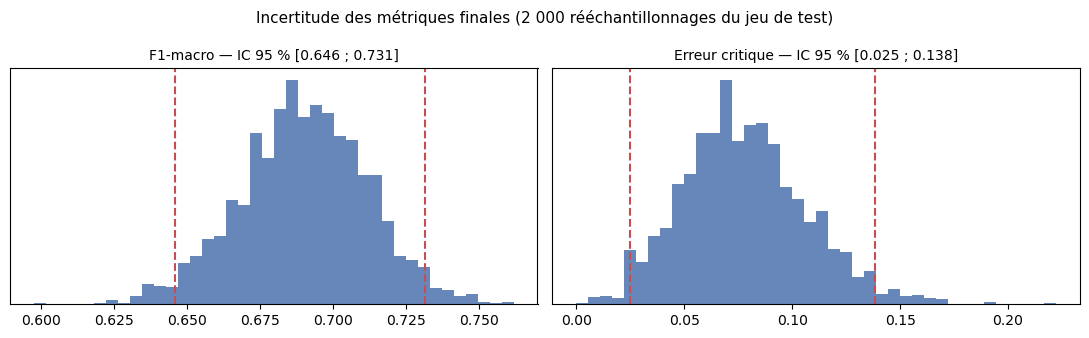

✔ IC 95 % du F1-macro : [0,646 ; 0,731]
✔ IC 95 % de l'erreur critique : [0,025 ; 0,138]
✔ dans aucun rééchantillonnage le seuil ne fait plus d'erreurs critiques que l'argmax


True

In [45]:
# Bootstrap : 2 000 rééchantillonnages du jeu de test, avec remise. Les deux règles sont évaluées
# sur les MÊMES tirages, ce qui permet de mesurer l'incertitude de leur écart (bootstrap apparié).
generateur = np.random.default_rng(0)
f1_bootstrap, erreur_bootstrap, ecart_f1_bootstrap, ecart_erreur_bootstrap = [], [], [], []
for _ in range(2000):
    indices = generateur.integers(0, len(y_test_arr), len(y_test_arr))
    y_tirage, seuil_tirage, argmax_tirage = y_test_arr[indices], prediction_finale[indices], prediction_argmax[indices]
    matrice_seuil = confusion_matrix(y_tirage, seuil_tirage, labels=[0, 1, 2])
    matrice_argmax = confusion_matrix(y_tirage, argmax_tirage, labels=[0, 1, 2])
    f1_seuil = f1_score(y_tirage, seuil_tirage, average="macro")
    erreur_seuil = matrice_seuil[2, 0] / max(matrice_seuil[2].sum(), 1)
    f1_bootstrap.append(f1_seuil)
    erreur_bootstrap.append(erreur_seuil)
    ecart_f1_bootstrap.append(f1_seuil - f1_score(y_tirage, argmax_tirage, average="macro"))
    ecart_erreur_bootstrap.append(erreur_seuil - matrice_argmax[2, 0] / max(matrice_argmax[2].sum(), 1))

ic_f1, ic_erreur = np.percentile(f1_bootstrap, [2.5, 97.5]), np.percentile(erreur_bootstrap, [2.5, 97.5])
ic_ecart_f1, ic_ecart_erreur = np.percentile(ecart_f1_bootstrap, [2.5, 97.5]), np.percentile(ecart_erreur_bootstrap, [2.5, 97.5])
print(f"F1-macro au seuil 0,20        : {f1_test:.3f}   IC 95 % [{ic_f1[0]:.3f} ; {ic_f1[1]:.3f}]")
print(f"Erreur critique au seuil 0,20 : {erreur_test:.3f}   IC 95 % [{ic_erreur[0]:.3f} ; {ic_erreur[1]:.3f}]")
print(f"Écart seuil − argmax, F1-macro        : IC 95 % [{ic_ecart_f1[0]:+.3f} ; {ic_ecart_f1[1]:+.3f}]")
print(f"Écart seuil − argmax, erreur critique : IC 95 % [{ic_ecart_erreur[0]:+.3f} ; {ic_ecart_erreur[1]:+.3f}]")
print("Lecture : la perte de F1-macro due au seuil",
      "dépasse le bruit d'échantillonnage." if ic_ecart_f1[1] < 0 else "n'est pas distinguable du bruit d'échantillonnage.")

fig, axes = plt.subplots(1, 2, figsize=(11, 3.4))
for ax, valeurs, intervalle, titre in [(axes[0], f1_bootstrap, ic_f1, "F1-macro"), (axes[1], erreur_bootstrap, ic_erreur, "Erreur critique")]:
    ax.hist(valeurs, bins=40, color="#4c72b0", alpha=0.85)
    ax.axvline(intervalle[0], color="#c44e52", ls="--")
    ax.axvline(intervalle[1], color="#c44e52", ls="--")
    ax.set_title(f"{titre} — IC 95 % [{intervalle[0]:.3f} ; {intervalle[1]:.3f}]", fontsize=10)
    ax.set_yticks([])
plt.suptitle("Incertitude des métriques finales (2 000 rééchantillonnages du jeu de test)", fontsize=11)
plt.tight_layout()
plt.show()

controler(np.allclose(ic_f1, [0.646, 0.731], atol=5e-4), "IC 95 % du F1-macro : [0,646 ; 0,731]")
controler(np.allclose(ic_erreur, [0.025, 0.138], atol=5e-4), "IC 95 % de l'erreur critique : [0,025 ; 0,138]")
controler(max(ecart_erreur_bootstrap) <= 0, "dans aucun rééchantillonnage le seuil ne fait plus d'erreurs critiques que l'argmax")

**Le seuil fait ce qu'on attend de lui.** Sur les 90 usagers de classe 2 du jeu de test, le modèle
en oriente 7 à tort vers un retour rapide avec le seuil 0,20, contre 10 avec l'argmax : l'erreur
critique passe de 11,1 % à 7,8 %. En contrepartie, l'accuracy passe de 0,740 à 0,708 et le F1-macro
de 0,712 à 0,691, parce que le seuil fait signaler en classe 2 des usagers qui n'en relèvent pas.

**Le seuil ne peut pas créer d'erreur critique.** Il ne prédit la classe 0 que si P(2) < 0,20 et
P(0) ≥ P(1). Comme les trois probabilités font 1, P(0) + P(1) > 0,80, donc P(0) > 0,40 > P(2) :
l'argmax aurait lui aussi prédit 0. Chaque erreur critique du seuil est donc déjà une erreur de
l'argmax ; le bootstrap apparié le confirme sur les 2 000 tirages.

**Ces chiffres ont une marge d'incertitude importante.** Avec 90 usagers de classe 2, un point
d'erreur critique vaut moins d'une personne. L'intervalle de confiance à 95 % du F1-macro va de 0,646
à 0,731, celui de l'erreur critique de 2,5 % à 13,8 %. C'est la raison de fond pour laquelle aucune
décision n'a été prise sur ce jeu : les écarts que j'ai comparés entre modèles et scénarios tiennent
à l'intérieur de ces intervalles.

### 9.2 Matrices de confusion et métriques par classe

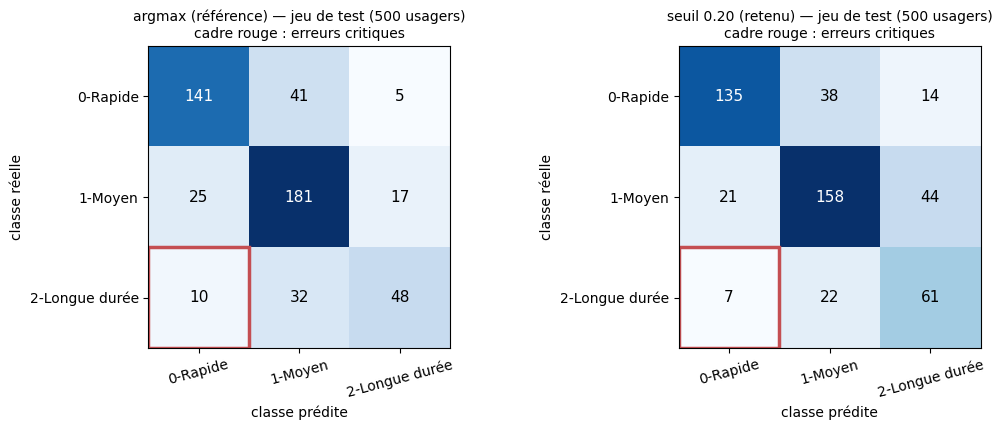

In [46]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.4))
for ax, (titre, y_pred) in zip(axes, [("argmax (référence)", prediction_argmax), (f"seuil {SEUIL_RETENU:.2f} (retenu)", prediction_finale)]):
    matrice = confusion_matrix(y_test_arr, y_pred, labels=[0, 1, 2])
    ax.imshow(matrice, cmap="Blues")
    for i in range(3):
        for j in range(3):
            ax.text(j, i, matrice[i, j], ha="center", va="center", fontsize=11,
                    color="white" if matrice[i, j] > matrice.max() / 2 else "black")
    ax.add_patch(plt.Rectangle((-0.5, 1.5), 1, 1, fill=False, edgecolor="#c44e52", linewidth=2.5))
    ax.set_xticks(range(3), NOMS_CLASSES, rotation=15)
    ax.set_yticks(range(3), NOMS_CLASSES)
    ax.set_xlabel("classe prédite")
    ax.set_ylabel("classe réelle")
    ax.set_title(f"{titre} — jeu de test (500 usagers)\ncadre rouge : erreurs critiques", fontsize=10)
plt.tight_layout()
plt.show()

**Ce que change le seuil, classe par classe.** Il détecte 61 des 90 usagers de classe 2, contre 48
avec l'argmax : le rappel de la classe 2 passe de 0,533 à 0,678. Le prix se lit dans la colonne de la
classe 2 : 58 usagers des classes 0 et 1 y sont désormais signalés (14 + 44), contre 22 (5 + 17). La
précision de la classe 2 tombe ainsi à 0,513 : environ un usager signalé sur deux relève réellement
de la classe 2. Les rappels des classes 0 et 1 baissent en conséquence (0,754 → 0,722 et
0,812 → 0,709).

Pour le métier, c'est un arbitrage assumé : une fausse alerte coûte un accompagnement renforcé non
nécessaire, qu'un conseiller peut réorienter ; une erreur critique prive un usager d'un
accompagnement dont il avait besoin. La confusion la plus fréquente reste celle entre les classes 0
et 1, des délais voisins.

### 9.3 Analyse ROC sur le jeu de test

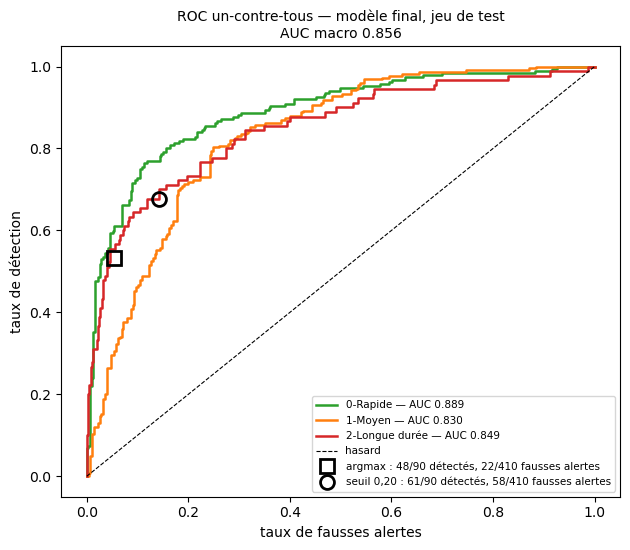

,detectes,fausses_alertes,taux_detection,taux_fausses_alertes
argmax,48,22,0.533,0.054
"seuil 0,20",61,58,0.678,0.141


In [47]:
y_test_binaire = label_binarize(y_test_arr, classes=[0, 1, 2])
auc_test = {classe: roc_auc_score(y_test_binaire[:, classe], probas_test[:, classe]) for classe in range(3)}
auc_macro_test = roc_auc_score(y_test_arr, probas_test, multi_class="ovr", average="macro")
auc_ponderee_test = roc_auc_score(y_test_arr, probas_test, multi_class="ovr", average="weighted")


def point_de_fonctionnement(y_pred):
    """Détection de la classe 2 et fausses alertes, calculées sur les prédictions réelles de la règle."""
    vrais_2 = y_test_arr == 2
    return {"detectes": int(np.sum(y_pred[vrais_2] == 2)), "sur_classe_2": int(vrais_2.sum()),
            "fausses_alertes": int(np.sum(y_pred[~vrais_2] == 2)), "sur_autres": int((~vrais_2).sum()),
            "taux_detection": float(np.mean(y_pred[vrais_2] == 2)), "taux_fausses_alertes": float(np.mean(y_pred[~vrais_2] == 2))}


points = pd.DataFrame([point_de_fonctionnement(prediction_argmax), point_de_fonctionnement(prediction_finale)],
                      index=["argmax", "seuil 0,20"])
fig, ax = plt.subplots(figsize=(6.4, 5.6))
for classe, couleur in zip(range(3), ["#2ca02c", "#ff7f0e", "#d62728"]):
    faux_positifs, vrais_positifs, _ = roc_curve(y_test_binaire[:, classe], probas_test[:, classe])
    ax.plot(faux_positifs, vrais_positifs, color=couleur, lw=1.8, label=f"{NOMS_CLASSES[classe]} — AUC {auc_test[classe]:.3f}")
ax.plot([0, 1], [0, 1], "k--", lw=0.8, label="hasard")
for regle, marqueur in [("argmax", "s"), ("seuil 0,20", "o")]:
    ax.plot(points.loc[regle, "taux_fausses_alertes"], points.loc[regle, "taux_detection"], marqueur, ms=10, mfc="none",
            mec="black", mew=2, label=f"{regle} : {points.loc[regle, 'detectes']}/90 détectés, "
                                       f"{points.loc[regle, 'fausses_alertes']}/410 fausses alertes")
ax.set_xlabel("taux de fausses alertes")
ax.set_ylabel("taux de détection")
ax.set_title(f"ROC un-contre-tous — modèle final, jeu de test\nAUC macro {auc_macro_test:.3f}", fontsize=10)
ax.legend(fontsize=7.5, loc="lower right")
plt.tight_layout()
plt.show()
display(points[["detectes", "fausses_alertes", "taux_detection", "taux_fausses_alertes"]].round(3))

**L'AUC macro atteint 0,856 sur le test** (0,855 pondérée par les effectifs) : 0,889 pour la classe 0,
0,830 pour la classe 1, 0,849 pour la classe 2. C'est du même ordre que la validation croisée (0,840
pour le Scénario 2) : rien n'indique que le modèle se soit sur-ajusté aux plis.

**Les deux points de fonctionnement rendent l'arbitrage lisible.** L'argmax détecte 48 des 90
usagers de classe 2 (53,3 %) pour 22 fausses alertes sur 410 (5,4 %) ; le seuil 0,20 en détecte 61
(67,8 %) pour 58 fausses alertes (14,1 %). Passer de l'un à l'autre fait détecter 13 usagers à risque
de plus, au prix de 36 fausses alertes supplémentaires, et évite 3 erreurs critiques. Les deux
points sont calculés sur les prédictions réelles de chaque règle. L'argmax n'étant pas un seuil sur
la seule probabilité de classe 2, son point n'est en général pas situé sur la courbe rouge.

### 9.4 Analyse des erreurs critiques

Cette analyse est descriptive : elle sert à comprendre les erreurs, pas à modifier le modèle.

In [48]:
analyse_test = df.loc[X_test.index, ["age", "niveau_diplome", "anciennete_poste_ans", "code_rome_vise", "synthese_entretien"]].copy()
analyse_test["classe_reelle"] = y_test_arr
analyse_test["classe_predite"] = prediction_finale
analyse_test["p_classe2"] = probas_test[:, 2].round(3)
erreurs_critiques_test = analyse_test[(analyse_test["classe_reelle"] == 2) & (analyse_test["classe_predite"] == 0)]
print(f"Erreurs critiques sur le test : {len(erreurs_critiques_test)} | probabilité de classe 2 : "
      f"de {erreurs_critiques_test['p_classe2'].min():.3f} à {erreurs_critiques_test['p_classe2'].max():.3f}")
display(erreurs_critiques_test.drop(columns=["classe_reelle", "classe_predite"]))
print("\nFormulations rencontrées dans ces erreurs :")
print(erreurs_critiques_test["synthese_entretien"].fillna("(synthèse absente)").value_counts().to_string())

# Rappel de la classe 2 par tranche d'âge (descriptif : effectifs faibles).
tranches_age = pd.cut(analyse_test["age"], [0, 35, 45, 55, 120], right=False, labels=["moins de 35 ans", "35-44 ans", "45-54 ans", "55 ans et plus"])
analyse_test["tranche_age"] = tranches_age.cat.add_categories("âge non renseigné").fillna("âge non renseigné")
par_tranche = analyse_test[analyse_test["classe_reelle"] == 2].groupby("tranche_age", observed=False).agg(
    usagers_classe2=("classe_reelle", "size"),
    detectes=("classe_predite", lambda s: int((s == 2).sum())),
    erreurs_critiques=("classe_predite", lambda s: int((s == 0).sum())))
par_tranche["rappel_classe2"] = (par_tranche["detectes"] / par_tranche["usagers_classe2"]).round(3)
display(par_tranche)

Erreurs critiques sur le test : 7 | probabilité de classe 2 : de 0.001 à 0.065


,age,niveau_diplome,anciennete_poste_ans,code_rome_vise,synthese_entretien,p_classe2
1850,28.0,Bac,0.7,G1801,"Candidat très dynamique, mobilité nationale va...",0.044
1690,50.0,Bac+5,0.8,K1601,Perte de confiance importante. Risque d'exclus...,0.026
1746,42.0,Bac+2,0.2,A1301,Freins périphériques majeurs. Situation d'ille...,0.059
97,41.0,Bac,1.3,D1210,Perte de confiance importante. Risque d'exclus...,0.065
527,27.0,Bac+2,5.3,M1806,"Excellente présentation, compétences technique...",0.001
369,46.0,Bac+2,6.3,N4101,Perte de confiance importante. Risque d'exclus...,0.023
2174,NaN,Bac+2,0.2,M1705,Freins périphériques majeurs. Situation d'ille...,0.033



Formulations rencontrées dans ces erreurs :
synthese_entretien
Perte de confiance importante. Risque d'exclusion, barrière de la langue.        3
Freins périphériques majeurs. Situation d'illettrisme numérique constatée.       2
Candidat très dynamique, mobilité nationale validée. Projet clair.               1
Excellente présentation, compétences techniques à jour. Reprise rapide visée.    1


,usagers_classe2,detectes,erreurs_critiques,rappel_classe2
tranche_age,,,,
moins de 35 ans,21,10,2,0.476
35-44 ans,4,2,2,0.500
45-54 ans,24,14,2,0.583
55 ans et plus,36,31,0,0.861
âge non renseigné,5,4,1,0.800


Les sept dossiers mal orientés sont listés ci-dessus, avec leur probabilité de classe 2, par
construction inférieure à 0,20 : le modèle les voyait comme peu à risque. Sept cas ne suffisent pas
à dégager un profil type, et je ne tire aucune conclusion statistique du tableau par tranche d'âge,
dont certains effectifs sont très faibles. Ces tableaux ont deux usages concrets : montrer au jury à
quoi ressemble une erreur critique, et fixer la forme du suivi par tranche d'âge que je prévois en
production (§ 10.4 et § 11.15).

### 9.5 Validation croisée et test : deux mesures cohérentes

In [49]:
comparaison_cv_test = pd.DataFrame({
    "validation croisée (hors-pli, 2 000 usagers)": [gagnant["f1_macro"], gagnant["erreur_critique"]],
    "test (500 usagers)": [f1_test, erreur_test],
    "IC 95 % du test — borne basse": [ic_f1[0], ic_erreur[0]],
    "IC 95 % du test — borne haute": [ic_f1[1], ic_erreur[1]],
}, index=["F1-macro (seuil 0,20)", "erreur critique (seuil 0,20)"])
display(comparaison_cv_test.round(4))

,"validation croisée (hors-pli, 2 000 usagers)",test (500 usagers),IC 95 % du test — borne basse,IC 95 % du test — borne haute
"F1-macro (seuil 0,20)",0.684,0.691,0.646,0.731
"erreur critique (seuil 0,20)",0.099,0.078,0.025,0.138


Les valeurs de validation croisée (F1-macro de 0,684, erreur critique de 9,9 %) se situent dans les
intervalles de confiance du test : les deux mesures sont cohérentes. Une différence mérite d'être
dite : sur le test, le seuil coûte 2,1 points de F1-macro, alors qu'en validation croisée il n'en
coûtait presque rien. Les deux mesures ne portent ni sur les mêmes usagers ni sur le même effectif ;
je fonde la décision sur les 2 000 usagers de la validation croisée et je lis le test comme un
contrôle indépendant, dont les intervalles rappellent la précision limitée.

### 9.6 Bilan

| Mesure (jeu de test) | Argmax | Seuil 0,20 retenu |
|---|---|---|
| Accuracy | 0,740 | 0,708 |
| F1-macro | 0,712 | 0,691 — IC 95 % [0,646 ; 0,731] |
| Erreurs critiques | 10 sur 90 (11,1 %) | 7 sur 90 (7,8 %) — IC 95 % [2,5 % ; 13,8 %] |
| Usagers de classe 2 détectés | 48 sur 90 | 61 sur 90 |
| Fausses alertes de classe 2 | 22 sur 410 | 58 sur 410 |
| AUC macro | 0,856 (identique : le seuil ne change pas les probabilités) | |

## 10. Éthique et cadre réglementaire

Un modèle qui oriente des demandeurs d'emploi touche à des droits fondamentaux. Je traite cette
partie comme une série de questions précises, auxquelles je réponds autant que possible par une
mesure. Je distingue ce qui est établi, ce qui reste à confirmer avec le délégué à la protection des
données (DPO) et le service juridique, et ce que je recommande.

### 10.1 Le cadre applicable

| Texte | Ce qu'il impose ici | Réponse dans le projet |
|---|---|---|
| RGPD, art. 5 : licéité, minimisation, limitation de la conservation | Ne traiter que les données nécessaires, pour une durée limitée | Scénario 2 sans nationalité ; retrait recommandé du statut d'allocation ; purge du journal paramétrée (365 jours par défaut, à arbitrer avec le DPO) |
| RGPD, art. 22 | Pas de décision fondée exclusivement sur un traitement automatisé produisant des effets significatifs | Le conseiller décide ; l'API propose, avec ses probabilités et ses avertissements |
| RGPD, art. 13, 14 et 35 | Informer les usagers ; analyse d'impact (AIPD) pour un traitement à risque élevé | Mention d'information et AIPD à réaliser avant tout déploiement |
| Code pénal, art. 225-1 ; loi n° 2008-496 | Interdiction des discriminations fondées notamment sur l'origine, l'appartenance à une nation, l'âge ou la particulière vulnérabilité économique | Nationalité exclue ; âge conservé avec justification et garde-fous  ; statut d'allocation à retirer  |
| Code des relations entre le public et l'administration, art. L. 311-3-1 | Une décision individuelle prise sur le fondement d'un traitement algorithmique doit le mentionner ; l'intéressé peut obtenir les règles du traitement et leur mise en œuvre | Explications globales  et individuelles|
| Règlement européen sur l'IA (UE) 2024/1689 | Système probablement à haut risque (annexe III, accès aux services publics essentiels) : gestion des risques, qualité des données, journalisation, contrôle humain, analyse d'impact sur les droits fondamentaux pour un déployeur public (art. 27) | Éléments préparés dans ce notebook. Depuis le règlement (UE) 2026/1744, ces obligations s'appliquent à partir du 2 décembre 2027 ; la formation des utilisateurs (art. 4) s'applique déjà |

**Une précision juridique importante.** La nationalité n'est pas une « catégorie particulière de
données » au sens de l'article 9 du RGPD (origine raciale ou ethnique, santé, opinions…). C'est en
revanche un critère de discrimination prohibé : l'utiliser pour orienter un usager exposerait
l'organisme à un traitement discriminatoire. C'est la raison principale de son retrait, avant toute
question de performance. Je ne l'utilise ci-dessous que comme instrument de mesure des biais,
jamais comme entrée du modèle ; cet usage devra être prévu dans l'AIPD.

**Et la géographie ?** Le département n'est pas un critère protégé en soi, mais le lieu de résidence
figure parmi les critères de l'article 225-1, et il peut servir de substitut à l'origine.

### 10.2 Ce que coûte le retrait de la nationalité, au seuil retenu

In [50]:
lignes_cout = []
for nom_modele in ("XGBoost", "LightGBM"):
    for scenario in ("1_multimodal_complet", "2_sans_variable_sensible"):
        lignes_cout.append({"modele": nom_modele, "scenario": scenario,
                            **mesurer(y_train_arr, predire_avec_seuil(probas_oof_scenarios[(scenario, nom_modele)], SEUIL_RETENU))})
cout_nationalite = pd.DataFrame(lignes_cout).set_index(["modele", "scenario"])
display(cout_nationalite.round(4))
controler_valeur("XGBoost, Scénario 1 au seuil 0,20 : F1-macro", cout_nationalite.loc[("XGBoost", "1_multimodal_complet"), "f1_macro"], 0.7003)
controler(cout_nationalite.loc[("XGBoost", "1_multimodal_complet"), "erreurs_critiques"] == 34, "XGBoost, Scénario 1 : 34 erreurs critiques")
controler_valeur("LightGBM, Scénario 1 au seuil 0,20 : F1-macro", cout_nationalite.loc[("LightGBM", "1_multimodal_complet"), "f1_macro"], 0.6927)
controler_valeur("LightGBM, Scénario 2 au seuil 0,20 : F1-macro", cout_nationalite.loc[("LightGBM", "2_sans_variable_sensible"), "f1_macro"], 0.6626)
perte_xgboost = cout_nationalite.loc[("XGBoost", "1_multimodal_complet"), "f1_macro"] - cout_nationalite.loc[("XGBoost", "2_sans_variable_sensible"), "f1_macro"]
perte_lightgbm = cout_nationalite.loc[("LightGBM", "1_multimodal_complet"), "f1_macro"] - cout_nationalite.loc[("LightGBM", "2_sans_variable_sensible"), "f1_macro"]
print(f"Perte de F1-macro due au retrait — XGBoost : {perte_xgboost:.4f} | LightGBM : {perte_lightgbm:.4f}")

f1_macro  erreur_critique  erreurs_critiques
modele   scenario                                                              
XGBoost  1_multimodal_complet         0.700            0.094                 34
         2_sans_variable_sensible     0.684            0.099                 36
LightGBM 1_multimodal_complet         0.693            0.091                 33
         2_sans_variable_sensible     0.663            0.116                 42

✔ XGBoost, Scénario 1 au seuil 0,20 : F1-macro : 0.7003 (valeur citée dans le texte : 0.7003)
✔ XGBoost, Scénario 1 : 34 erreurs critiques
✔ LightGBM, Scénario 1 au seuil 0,20 : F1-macro : 0.6927 (valeur citée dans le texte : 0.6927)
✔ LightGBM, Scénario 2 au seuil 0,20 : F1-macro : 0.6626 (valeur citée dans le texte : 0.6626)
Perte de F1-macro due au retrait — XGBoost : 0.0166 | LightGBM : 0.0302


Au seuil retenu, et toujours en validation croisée, retirer la nationalité fait passer le F1-macro de
XGBoost de 0,7003 à 0,6837 (−1,66 point) et ses erreurs critiques de 34 à 36 sur 362. Pour LightGBM,
la perte est plus forte : de 0,6927 à 0,6626 (−3,02 points), et de 33 à 42 erreurs critiques. Le coût
est réel, mesuré, et je l'assume : il est le prix d'un outil qui n'oriente pas les usagers selon leur
nationalité. XGBoost a l'avantage supplémentaire d'être le moins dépendant de cette variable.

### 10.3 Explicabilité globale : sur quoi le modèle s'appuie-t-il ?

L'importance par permutation mesure la chute du F1-macro quand on brouille une information (en
mélangeant ses valeurs entre usagers). Je permute ensemble les colonnes d'un même groupe : brouiller
une seule des 96 colonnes du département ne dirait rien de l'apport de la géographie. Le calcul porte
sur le jeu de test : il décrit le modèle final, il ne sert à aucune décision.

,chute du F1-macro,part de la contribution (%)
Texte (synthèse d'entretien),1.733e-01,37.2
Niveau de diplôme,1.108e-01,23.8
Âge,1.080e-01,23.2
Métier visé (ROME),4.200e-02,9.0
Ancienneté (dernier poste),2.690e-02,5.8
Département,3.100e-03,0.7
Indicateurs de manque et de cohérence,1.900e-03,0.4
Statut d'allocation,3.000e-04,0.1


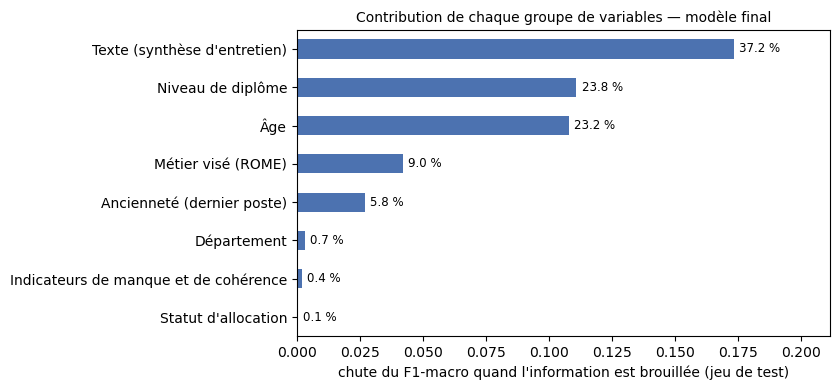

In [51]:
noms_variables_s2 = list(colonnes_sans_sensible) + list(tfidf.get_feature_names_out())


def groupe_de_variable(nom):
    if nom.startswith("departement_"):
        return "Département"
    if nom.startswith("code_rome_vise_"):
        return "Métier visé (ROME)"
    if nom in {"age_manquant", "niveau_diplome_manquant", "est_allocataire_manquant", "synthese_entretien_manquant", "anciennete_incoherente"}:
        return "Indicateurs de manque et de cohérence"
    return {"age": "Âge", "anciennete_poste_ans": "Ancienneté (dernier poste)", "niveau_diplome_encode": "Niveau de diplôme",
            "est_allocataire": "Statut d'allocation"}.get(nom, "Texte (synthèse d'entretien)")


nombre_colonnes_tabulaires = len(colonnes_sans_sensible)
groupes_variables = {}
for position, nom in enumerate(noms_variables_s2):
    groupe = groupe_de_variable(nom) if position < nombre_colonnes_tabulaires else "Texte (synthèse d'entretien)"
    groupes_variables.setdefault(groupe, []).append(position)


def f1_apres_seuil(matrice):
    return f1_score(y_test_arr, predire_avec_seuil(modele_final.predict_proba(matrice), SEUIL_RETENU), average="macro")


f1_reference = f1_apres_seuil(X_s2_test)
X_test_dense = X_s2_test.toarray()
chutes = {}
for groupe, positions in groupes_variables.items():
    pertes = []
    for repetition in range(10):
        X_melange = X_test_dense.copy()
        permutation = np.random.default_rng(repetition).permutation(len(X_melange))
        X_melange[:, positions] = X_melange[np.ix_(permutation, positions)]
        pertes.append(f1_reference - f1_apres_seuil(csr_matrix(X_melange)))
    chutes[groupe] = np.mean(pertes)
importance = pd.Series(chutes).sort_values(ascending=False)
importance_part = importance.clip(lower=0) / importance.clip(lower=0).sum() * 100
display(pd.DataFrame({"chute du F1-macro": importance.round(4), "part de la contribution (%)": importance_part.round(1)}))

fig, ax = plt.subplots(figsize=(8.5, 4))
importance.sort_values().plot(kind="barh", ax=ax, color="#4c72b0")
for position, (groupe, valeur) in enumerate(importance.sort_values().items()):
    ax.text(valeur + 0.002, position, f"{importance_part[groupe]:.1f} %", va="center", fontsize=8.5)
ax.set_xlabel("chute du F1-macro quand l'information est brouillée (jeu de test)")
ax.set_title("Contribution de chaque groupe de variables — modèle final", fontsize=10)
ax.set_xlim(0, importance.max() * 1.22)
plt.tight_layout()
plt.show()

**Quatre enseignements.**

1. **La synthèse d'entretien est le premier appui du modèle** (37,2 % de la contribution totale).
2. **Le niveau de diplôme (23,8 %) et l'âge (23,2 %) viennent ensuite**, à quasi-égalité. L'âge
   étant un critère protégé, cette place impose une discussion à part .
3. **Le département ne pèse que 0,7 %** : brouiller la géographie ne coûte presque rien au modèle. Le
   risque qu'il s'en serve comme substitut de l'origine est donc faible .
4. **Le statut d'allocation ne pèse presque rien (0,1 %)**, ce qui rejoint l'absence de lien
   statistique avec la cible observée au 3.8.

Cette décomposition est exactement le type d'information que l'organisme doit pouvoir fournir à un
usager qui demande les règles du traitement (CRPA, art. L. 311-3-1). Une limite : l'importance par
permutation dit sur quoi le modèle s'appuie, pas pourquoi un usager met du temps à retrouver un
emploi. Ce n'est pas une analyse causale.

### 10.4 L'âge : un critère protégé que je conserve, sous conditions

L'exploration a montré une association forte entre l'âge et la classe : 38,2 % des 55 ans et plus
relèvent de la classe 2, contre 7,6 % des 35-45 ans . Je mesure ce que coûterait le retrait
strict de l'âge, de son indicateur de valeur manquante et de l'indicateur d'incohérence qui en
dépend, avec la préparation réapprise dans chaque pli.

In [52]:
probas_sans_age, f1_plis_sans_age = evaluer_preparation_par_pli(sans_age=True)
mesure_avec_age = mesurer(y_train_arr, predire_avec_seuil(probas_preparation_par_pli, SEUIL_RETENU))
mesure_sans_age = mesurer(y_train_arr, predire_avec_seuil(probas_sans_age, SEUIL_RETENU))
ablation_age = pd.DataFrame({"avec l'âge": mesure_avec_age, "sans l'âge": mesure_sans_age}).T
display(ablation_age.round(4))
ecarts_age = f1_plis_sans_age - f1_plis_preparation
print("Écart de F1-macro par pli (sans − avec) :", np.round(ecarts_age, 4).tolist())

,f1_macro,erreur_critique,erreurs_critiques
avec l'âge,0.683,0.105,38.0
sans l'âge,0.617,0.141,51.0


Écart de F1-macro par pli (sans − avec) : [-0.0525, -0.0725, -0.0673, -0.0914, -0.0485]


**Le retrait de l'âge coûte cher** : le F1-macro passe de 0,6833 à 0,6166 (−6,66 points) et les
erreurs critiques de 38 à 51 sur 362 (de 10,5 % à 14,1 %). La dégradation se retrouve dans chacun
des cinq plis : ce n'est pas un effet du découpage.

**Pourquoi je traite l'âge autrement que la nationalité.** Le droit de la non-discrimination admet
des différences de traitement fondées sur l'âge lorsqu'elles sont objectivement et raisonnablement
justifiées par un but légitime et que les moyens sont nécessaires et appropriés. Le code du travail
(art. L. 1133-2) cite d'ailleurs expressément le but de favoriser l'insertion professionnelle ; je
raisonne ici par analogie, le texte visant les relations de travail. Le but poursuivi est d'orienter
vers un accompagnement renforcé les personnes les plus exposées au chômage de longue durée, ce qui
les avantage. Aucune justification de ce type n'existe pour la nationalité. Cette qualification
reste à confirmer par le service juridique.

**Les garde-fous qui conditionnent ce choix** :

1. le conseiller décide ; le modèle n'écarte jamais un usager d'un accompagnement ;
2. l'usage de l'âge est documenté et assumé dans l'information des usagers et dans l'AIPD ;
3. le rappel de la classe 2 est suivi par tranche d'âge en production (tableau du  9.4) ;
4. l'API signale tout âge hors de la plage d'entraînement (18 à 63 ans) comme une extrapolation.

### 10.5 Explicabilité individuelle : expliquer une orientation à un usager

XGBoost calcule nativement la contribution de chaque variable à une prédiction (valeurs de Shapley,
méthode TreeSHAP), sans bibliothèque supplémentaire. Je regroupe les contributions par information
métier, pour deux usagers réels du jeu de test.


Usager n° 14 du jeu de test — orienté vers un accompagnement renforcé
classe réelle 2 | classe prédite 2 | P(classe 2) = 0.432
   point de départ commun                   -0.643
   Texte (synthèse d'entretien)             +0.936   augmente le risque
   Niveau de diplôme                        +0.542   augmente le risque
   Ancienneté (dernier poste)               -0.398   diminue le risque
   Âge                                      -0.252   diminue le risque
   Département                              +0.151   augmente le risque
   Métier visé (ROME)                       +0.146   augmente le risque
   Indicateurs de manque et de cohérence    -0.036   diminue le risque
   Statut d'allocation                      +0.027   augmente le risque
   total (échelle interne du modèle)        +0.474

Usager n° 8 du jeu de test — orienté vers un suivi standard
classe réelle 0 | classe prédite 0 | P(classe 2) = 0.003
   point de départ commun                   -0.643
   Texte (synthèse d'entreti

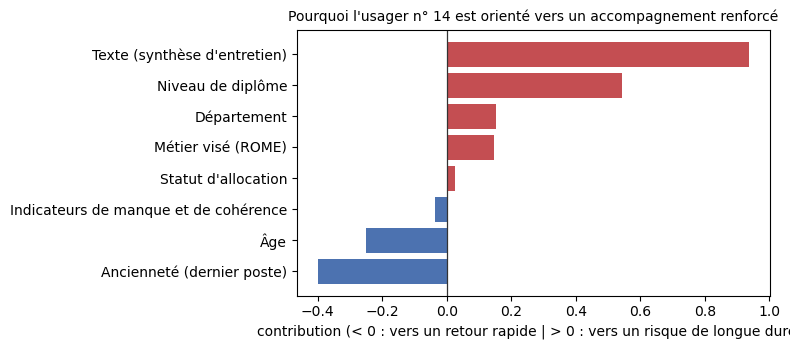

In [53]:
# Forme : (usagers, classes, variables + 1) ; la dernière colonne est la valeur de départ commune.
contributions = np.array(modele_final.get_booster().predict(DMatrix(X_s2_test), pred_contribs=True))


def expliquer_usager(indice, classe=2):
    valeurs = contributions[indice, classe, :]
    par_groupe = pd.Series({groupe: float(valeurs[positions].sum()) for groupe, positions in groupes_variables.items()})
    return float(valeurs[-1]), par_groupe.sort_values(key=np.abs, ascending=False)


indice_risque = int(np.where((prediction_finale == 2) & (y_test_arr == 2))[0][0])
indice_rapide = int(np.where((prediction_finale == 0) & (y_test_arr == 0))[0][0])
for indice, intitule in [(indice_risque, "orienté vers un accompagnement renforcé"), (indice_rapide, "orienté vers un suivi standard")]:
    depart, parts = expliquer_usager(indice)
    print(f"\nUsager n° {indice} du jeu de test — {intitule}")
    print(f"classe réelle {y_test_arr[indice]} | classe prédite {prediction_finale[indice]} | P(classe 2) = {probas_test[indice, 2]:.3f}")
    print(f"   {'point de départ commun':40s} {depart:+.3f}")
    for groupe, valeur in parts.items():
        print(f"   {groupe:40s} {valeur:+.3f}   {'augmente' if valeur > 0 else 'diminue'} le risque")
    print(f"   {'total (échelle interne du modèle)':40s} {depart + parts.sum():+.3f}")

depart, parts = expliquer_usager(indice_risque)
fig, ax = plt.subplots(figsize=(8, 3.6))
parts_triees = parts.sort_values()
ax.barh(parts_triees.index, parts_triees.values, color=["#c44e52" if v > 0 else "#4c72b0" for v in parts_triees.values])
ax.axvline(0, color="#333", lw=0.9)
ax.set_xlabel("contribution (< 0 : vers un retour rapide | > 0 : vers un risque de longue durée)")
ax.set_title(f"Pourquoi l'usager n° {indice_risque} est orienté vers un accompagnement renforcé", fontsize=10)
plt.tight_layout()
plt.show()

**Ce que cela permet de dire à un usager.** Pour l'usager n° 14 (probabilité de classe 2 de 0,432,
au-dessus du seuil), la synthèse d'entretien (+0,936) et le niveau de diplôme (+0,542) poussent vers
un risque de longue durée, tandis que l'ancienneté dans le dernier poste (−0,398) et l'âge (−0,252)
poussent en sens inverse. On peut en tirer une explication en langage courant, sans chiffres :
« votre situation a été signalée principalement en raison des éléments de votre entretien et de
votre niveau de formation ; votre ancienneté dans votre dernier poste a joué en sens inverse ».

**Trois précautions.**

1. Ces contributions expliquent le modèle, pas la réalité : ce ne sont pas des causes.
2. Elles sont exprimées sur l'échelle interne du modèle (un logarithme de rapport de cotes), additive
   mais pas directement lisible en pourcentage : une interface destinée aux usagers doit montrer un
   sens et un ordre d'importance, pas ces nombres.
3. La contribution du texte est donnée globalement : le détail mot par mot serait illisible.

**Conséquence pour l'industrialisation.** Ce calcul est rapide ; une route d'explication renvoyant
ces contributions groupées, journalisées avec la prédiction, est la première évolution de l'API que
je recommande . Sans elle, il faudrait rejouer a posteriori une prédiction avec une version du
modèle qui n'est peut-être plus celle qui a servi.

### 10.6 Les variables restantes permettent-elles de retrouver la nationalité ?

Retirer une variable ne suffit pas si d'autres permettent de la reconstituer. J'entraîne un modèle à
prédire la nationalité à partir des 223 variables du Scénario 2 : s'il y parvient, le risque de
discrimination indirecte existe.

In [54]:
nationalite_train = X_train["nationalite_hors_ue"].to_numpy()
auc_substitut = cross_val_score(XGBClassifier(random_state=GRAINE, eval_metric="logloss"), X_s2_train, nationalite_train,
                                cv=5, scoring="roc_auc").mean()
print(f"AUC de reconstitution de la nationalité : {auc_substitut:.3f} (0,5 : aucune information ; 1 : reconstitution parfaite)")

AUC de reconstitution de la nationalité : 0.516 (0,5 : aucune information ; 1 : reconstitution parfaite)


Avec une AUC de 0,516, à peine au-dessus du hasard, les variables du Scénario 2 ne permettent pas de
retrouver la nationalité. Le seuil d'alerte que je retiens pour cet audit (une AUC de 0,60) est une
convention de travail, pas une norme. Ce test ne couvre que ce jeu de données : il devra être refait
à chaque réentraînement, puisque de nouvelles données peuvent créer de nouveaux substituts.

### 10.7 Le modèle rend-il un service de même qualité aux deux groupes ?

J'utilise ici la nationalité uniquement pour mesurer, sur le jeu de test. Le rappel de la classe 2
(la part des usagers à risque effectivement détectés) est la mesure qui compte : un rappel plus
faible pour un groupe signifierait qu'il est plus souvent privé d'accompagnement renforcé.

In [55]:
nationalite_test = X_test["nationalite_hors_ue"].to_numpy()
lignes_equite = []
for valeur, libelle in [(0, "nationalité UE"), (1, "nationalité hors UE")]:
    masque = nationalite_test == valeur
    matrice = confusion_matrix(y_test_arr[masque], prediction_finale[masque], labels=[0, 1, 2])
    lignes_equite.append({"groupe": libelle, "effectif": int(masque.sum()),
                          "part_reelle_classe2": np.mean(y_test_arr[masque] == 2),
                          "part_predite_classe2": np.mean(prediction_finale[masque] == 2),
                          "rappel_classe2": matrice[2, 2] / matrice[2].sum(),
                          "erreurs_critiques": f"{matrice[2, 0]} sur {matrice[2].sum()}"})
equite = pd.DataFrame(lignes_equite).set_index("groupe")

# Incertitude du rappel par groupe : bootstrap sur les usagers de classe 2 de chaque groupe.
generateur_equite = np.random.default_rng(1)
intervalles = {}
for valeur, libelle in [(0, "nationalité UE"), (1, "nationalité hors UE")]:
    detections = (prediction_finale[(nationalite_test == valeur) & (y_test_arr == 2)] == 2).astype(float)
    tirages = [detections[generateur_equite.integers(0, len(detections), len(detections))].mean() for _ in range(2000)]
    intervalles[libelle] = np.percentile(tirages, [2.5, 97.5])
equite["rappel_IC95_bas"] = [intervalles[g][0] for g in equite.index]
equite["rappel_IC95_haut"] = [intervalles[g][1] for g in equite.index]
display(equite.round(3))

,effectif,part_reelle_classe2,part_predite_classe2,rappel_classe2,erreurs_critiques,rappel_IC95_bas,rappel_IC95_haut
groupe,,,,,,,
nationalité UE,444,0.158,0.230,0.686,7 sur 70,0.571,0.786
nationalité hors UE,56,0.357,0.304,0.650,0 sur 20,0.450,0.850


**Ce que montre l'audit.** Le rappel de la classe 2 est proche dans les deux groupes (0,686 pour les
usagers de nationalité UE, 0,650 hors UE), et les 7 erreurs critiques concernent toutes des usagers
de nationalité UE (7 sur 70, contre 0 sur 20). Mais deux constats appellent la prudence :

- **Le modèle sous-estime la part de classe 2 chez les usagers hors UE** (30,4 % prédits pour 35,7 %
  réels) et la surestime chez les autres (23,0 % pour 15,8 %). Aveugle à la nationalité, il ne
  reproduit pas l'écart observé dans les données : c'est l'effet recherché du point de vue de
  l'égalité de traitement, mais cela signifie aussi qu'une partie des besoins réels des usagers hors
  UE peut lui échapper. Le conseiller reste indispensable.
- **Avec 20 usagers de classe 2 hors UE, les intervalles sont très larges** (affichés ci-dessus).
  L'absence d'écart n'est pas une preuve d'équité : c'est une absence de signal d'alerte, à confirmer
  sur un volume plus important.

C'est pourquoi le garde-fou de la CI refuse aussi un modèle dont l'écart de rappel entre les deux
groupes dépasserait 15 points , et pourquoi cet audit fait partie du suivi .

### 10.8 Le statut d'allocation : une variable protégée qui n'apporte rien

Trois mesures convergent : aucun lien avec la cible (p = 0,69), une contribution de 0,1 % ,et le test de retrait ci-dessous, en validation croisée sur l'entraînement.

In [56]:
def f1_hors_pli(X):
    """F1-macro hors-pli au seuil retenu (même protocole qu'au § 8.4)."""
    return f1_score(y_train_arr, predire_avec_seuil(probas_oof(X, XGBClassifier, random_state=GRAINE, eval_metric="mlogloss"), SEUIL_RETENU), average="macro")


position_allocation = colonnes_sans_sensible.index("est_allocataire")
position_indicateur = colonnes_sans_sensible.index("est_allocataire_manquant")
sans_allocation = [j for j in range(X_s2_train.shape[1]) if j != position_allocation]
sans_allocation_ni_indicateur = [j for j in range(X_s2_train.shape[1]) if j not in (position_allocation, position_indicateur)]
retrait_allocation = pd.Series({
    "modèle retenu": gagnant["f1_macro"],
    "sans le statut d'allocation": f1_hors_pli(X_s2_train[:, sans_allocation]),
    "sans le statut ni son indicateur de manque": f1_hors_pli(X_s2_train[:, sans_allocation_ni_indicateur]),
}, name="f1_macro_hors_pli")
display(retrait_allocation.round(4).to_frame())

,f1_macro_hors_pli
modèle retenu,0.684
sans le statut d'allocation,0.686
sans le statut ni son indicateur de manque,0.682


Retirer la variable fait passer le F1-macro hors-pli de 0,6837 à 0,6857 ; retirer aussi son
indicateur de manque le ramène à 0,6823 : des écarts de deux millièmes, dans les deux sens, donc
aucun effet mesurable. Or le statut d'allocation renseigne sur la situation économique, et la
particulière vulnérabilité résultant de la situation économique est un critère de discrimination
(code pénal, art. 225-1). Garder une variable liée à un critère protégé qui n'apporte rien n'est pas
défendable au regard du principe de minimisation.

**Ma décision : retirer `est_allocataire` dans la prochaine version du modèle.** Je ne l'applique
pas à cette livraison, parce que cela imposerait de remesurer la performance sur le jeu de test déjà
consulté : ce serait choisir une configuration en regardant le contrôle final, ce que je me suis
interdit. La prochaine version disposera d'un jeu de validation dédié.

### 10.9 Responsabilité, contrôle humain et gouvernance

- **Le conseiller reste décisionnaire.** L'interface présente une proposition, des probabilités
  arrondies et des avertissements ; elle ne bloque ni n'impose rien. C'est la condition pour que la
  décision ne soit pas « fondée exclusivement » sur un traitement automatisé (RGPD, art. 22).
- **Une erreur d'orientation peut engager la responsabilité de l'organisme.** Un usager de classe 2
  orienté à tort vers un suivi standard pourrait invoquer une perte de chance d'accompagnement. La
  réduction des erreurs critiques, le journal horodaté des prédictions et des versions de
  modèle , et la décision humaine sont les trois éléments qui permettent de répondre.
- **Avant tout déploiement réel** : AIPD (RGPD, art. 35) et analyse d'impact sur les droits
  fondamentaux (règlement sur l'IA, art. 27), inscription au registre des traitements, mention
  d'information des usagers, formation des conseillers aux limites de l'outil (règlement sur l'IA,
  art. 4), et durée de conservation du journal arbitrée avec le DPO.
- **Sécurité.** L'API sait exiger une clé de service et une clé d'administration distincte pour le
  réentraînement ; l'image Docker n'embarque aucune donnée personnelle.

### 10.10 Synthèse

| Question | Réponse mesurée | Où |
|---|---|---|
| La nationalité est-elle utilisée ? | Non : retirée du modèle, absente du schéma de l'API et de l'interface | § 7.4, § 11.6 |
| Que coûte ce retrait ? | −1,66 point de F1-macro et 2 erreurs critiques de plus (XGBoost, seuil 0,20) | § 10.2 |
| Peut-on la reconstituer ? | Non : AUC de 0,516 | § 10.6 |
| Le service est-il de même qualité ? | Rappels proches (0,686 et 0,650), mais effectifs trop faibles pour conclure | § 10.7 |
| L'âge est-il justifié ? | Retrait coûteux (−6,66 points) ; conservé sous conditions, à valider juridiquement | § 10.4 |
| Le statut d'allocation est-il utile ? | Non : retrait sans effet ; décidé pour la prochaine version | § 10.8 |
| Peut-on expliquer une décision ? | Oui, globalement et individuellement | § 10.3, § 10.5 |

## 11. Industrialisation : artefacts, API, suivi et CI/CD

Un modèle n'est utile que s'il peut servir, être surveillé et être remplacé sans risque. Cette
section décrit l'architecture cible, puis démontre chaque brique sur la version livrée : le script
d'entraînement, l'API, le journal, le réentraînement avec les retours des conseillers, MLflow,
l'interface, le monitoring et la chaîne CI/CD. Chaque démonstration est vérifiée par le calcul.

### 11.1 Architecture cible

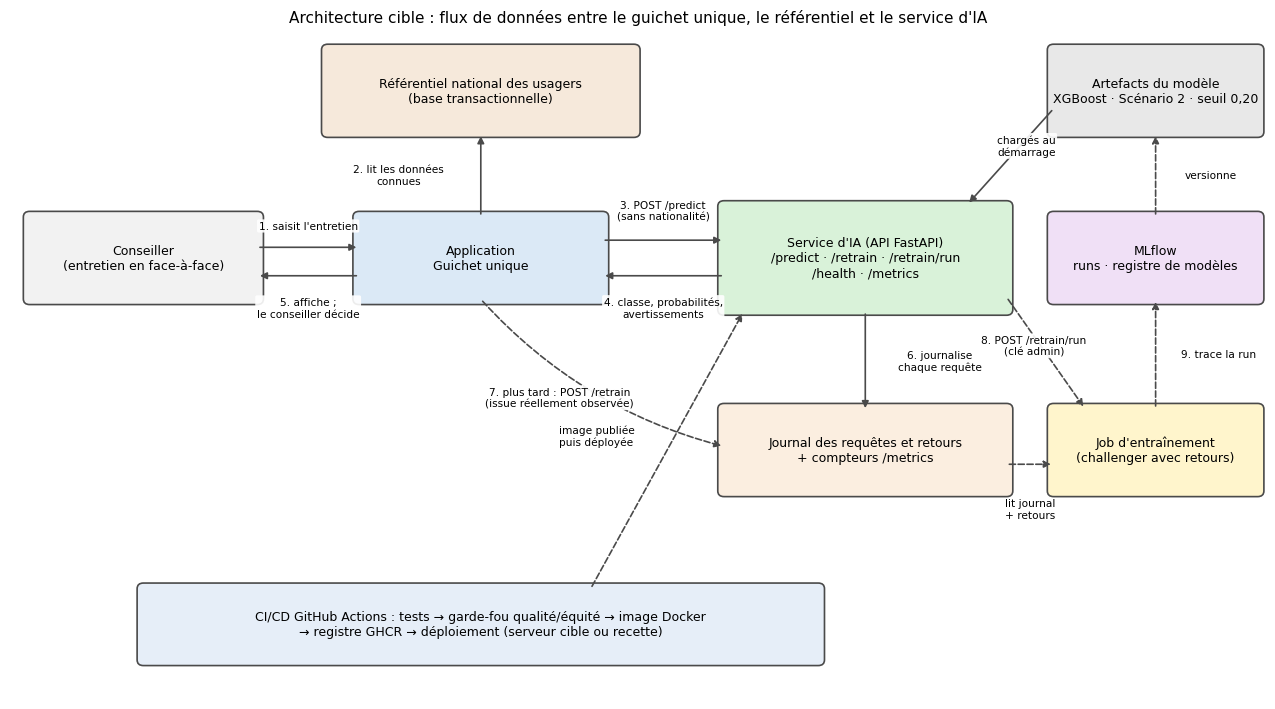

In [57]:
fig, ax = plt.subplots(figsize=(13, 7.2))
ax.set_xlim(0, 16)
ax.set_ylim(0, 9.4)
ax.axis("off")


def boite(x, y, texte, couleur, largeur=3.1, hauteur=1.15):
    ax.add_patch(patches.FancyBboxPatch((x - largeur / 2, y - hauteur / 2), largeur, hauteur, boxstyle="round,pad=0.08",
                                        linewidth=1.2, edgecolor="#4a4a4a", facecolor=couleur))
    ax.text(x, y, texte, ha="center", va="center", fontsize=9)


def fleche(depart, arrivee, texte="", pointille=False, courbure=0.0, decalage=(0, 0.22), taille=7.6):
    ax.annotate("", xy=arrivee, xytext=depart,
                arrowprops=dict(arrowstyle="-|>", color="#4a4a4a", lw=1.2, linestyle="--" if pointille else "-",
                                connectionstyle=f"arc3,rad={courbure}"))
    if texte:
        milieu = ((depart[0] + arrivee[0]) / 2 + decalage[0], (depart[1] + arrivee[1]) / 2 + decalage[1])
        ax.text(*milieu, texte, ha="center", va="center", fontsize=taille,
                bbox=dict(boxstyle="round,pad=0.15", facecolor="white", edgecolor="none", alpha=0.9))


boite(1.7, 6.2, "Conseiller\n(entretien en face-à-face)", "#f2f2f2", largeur=2.9)
boite(6.0, 6.2, "Application\nGuichet unique", "#dbe9f6")
boite(6.0, 8.55, "Référentiel national des usagers\n(base transactionnelle)", "#f6e9db", largeur=3.9)
boite(10.9, 6.2, "Service d'IA (API FastAPI)\n/predict · /retrain · /retrain/run\n/health · /metrics", "#d9f2d9", largeur=3.6, hauteur=1.45)
boite(14.6, 8.55, "Artefacts du modèle\nXGBoost · Scénario 2 · seuil 0,20", "#e8e8e8", largeur=2.6)
boite(14.6, 6.2, "MLflow\nruns · registre de modèles", "#f0e0f6", largeur=2.6)
boite(10.9, 3.5, "Journal des requêtes et retours\n+ compteurs /metrics", "#fbeee0", largeur=3.6)
boite(14.6, 3.5, "Job d'entraînement\n(challenger avec retours)", "#fff5cc", largeur=2.6)
boite(6.0, 1.05, "CI/CD GitHub Actions : tests → garde-fou qualité/équité → image Docker\n→ registre GHCR → déploiement (serveur cible ou recette)",
      "#e6eef8", largeur=8.6, hauteur=1.0)

fleche((3.15, 6.35), (4.45, 6.35), "1. saisit l'entretien", decalage=(0, 0.3))
fleche((6.0, 6.78), (6.0, 7.95), "2. lit les données\nconnues", decalage=(-1.05, 0))
fleche((7.55, 6.45), (9.1, 6.45), "3. POST /predict\n(sans nationalité)", decalage=(0, 0.42))
fleche((9.1, 5.95), (7.55, 5.95), "4. classe, probabilités,\navertissements", decalage=(0, -0.45))
fleche((4.45, 5.95), (3.15, 5.95), "5. affiche ;\nle conseiller décide", decalage=(0, -0.45))
fleche((10.9, 5.45), (10.9, 4.05), "6. journalise\nchaque requête", decalage=(0.95, 0))
fleche((6.0, 5.62), (9.1, 3.55), "7. plus tard : POST /retrain\n(issue réellement observée)", pointille=True, courbure=0.15, decalage=(-0.55, -0.35))
fleche((12.7, 5.65), (13.7, 4.08), "8. POST /retrain/run\n(clé admin)", pointille=True, decalage=(-0.15, 0.1))
fleche((12.7, 3.3), (13.3, 3.3), "", pointille=True)
ax.text(13.0, 2.55, "lit journal\n+ retours", ha="center", fontsize=7.6)
fleche((14.6, 4.08), (14.6, 5.62), "9. trace la run", pointille=True, decalage=(0.8, 0))
fleche((14.6, 6.78), (14.6, 7.95), "versionne", pointille=True, decalage=(0.7, 0))
fleche((13.3, 8.3), (12.2, 6.95), "chargés au\ndémarrage", decalage=(0.2, 0.15))
fleche((7.4, 1.55), (9.35, 5.45), "image publiée\npuis déployée", pointille=True, decalage=(-0.9, 0.2))
ax.set_title("Architecture cible : flux de données entre le guichet unique, le référentiel et le service d'IA", fontsize=11)
plt.tight_layout()
plt.show()

**Les choix structurants.**

- **Un service d'IA séparé**, appelé par l'application de guichet unique : le modèle peut évoluer
  sans toucher à l'application métier, et l'application garde la main sur l'affichage.
- **Le conteneur d'inférence n'embarque aucune donnée personnelle** : seulement le modèle et ses
  encodeurs. Le réentraînement relève d'un job distinct, qui a accès au référentiel.
- **Chaque prédiction est journalisée** avec la version du modèle : c'est la trace qui permet de
  répondre à un usager, d'auditer l'équité et de relier plus tard un retour de conseiller à sa
  prédiction.
- **Le remplacement du modèle est contrôlé** : un challenger est entraîné et tracé dans MLflow, la
  CI vérifie qu'il respecte les seuils de qualité et d'équité, et la promotion reste une décision
  humaine.

### 11.2 Flux de données

| Étape | Données | Source | Stockage | Conservation |
|---|---|---|---|---|
| 1-2. Saisie et lecture | Âge, diplôme, date de début de poste, métier visé, commune, statut d'allocation | Référentiel national (hypothèse) | Aucun côté IA | — |
| 1. Synthèse | Texte rédigé par le conseiller | Application de guichet unique | Aucun côté IA avant l'appel | — |
| 3-4. Prédiction | Les champs ci-dessus, **jamais la nationalité** | Appel HTTP à `/predict` | Journal des requêtes | 365 jours par défaut, paramétrable, à arbitrer avec le DPO |
| 7. Retour du conseiller | Identifiant de session et classe observée | Appel à `/retrain` | Fichier des retours | Même règle que le journal |
| 8-9. Réentraînement | Jeu d'entraînement + retours reliés à leur prédiction | Job d'entraînement | Artefacts du challenger, run MLflow | Selon la politique de versionnement |

### 11.3 Hébergement et ressources

L'hébergement cible est un conteneur Docker unique, sur l'infrastructure existante de l'agence. 
Les besoins sont modestes, et mesurés plus loin :

- **Stockage** : les artefacts pèsent moins d'un mégaoctet ;
- **Calcul** : quelques millisecondes par prédiction côté serveur, sur un seul cœur  ; aucun
  GPU n'est nécessaire ;
- **Mémoire** : je dimensionne le conteneur à 1 cœur et 1 Go. Ce n'est pas une mesure : c'est une
  hypothèse de dimensionnement, appliquée comme limite dans `docker-compose.yml` pour être vérifiée
  en recette avec `docker stats`.

La montée en charge se ferait en multipliant les conteneurs derrière un répartiteur ; les compteurs
de `/metrics` devraient alors être agrégés (limite signalée dans le code de l'API).

### 11.4 Génération et vérification des artefacts


In [58]:
for dossier in (CHEMIN_ARTEFACTS, CHEMIN_CANDIDAT):
    shutil.rmtree(dossier, ignore_errors=True)
debut = time.perf_counter()
execution = subprocess.run([sys.executable, "entrainer_modele.py"], cwd=DOSSIER_SRC, env=os.environ.copy(),
                           capture_output=True, text=True, encoding="utf-8", errors="replace")
print(execution.stdout[-2500:])
if execution.returncode != 0:
    print(execution.stderr[-4000:])
    raise RuntimeError("Le script d'entraînement a échoué : voir le message ci-dessus.")
print(f"Durée d'exécution du script : {time.perf_counter() - debut:.1f} s")

fichiers_artefacts = ["modele_xgboost.joblib", "onehot_encoder.joblib", "tfidf_vectorizer.joblib",
                      "parametres_imputation.joblib", "metriques.json", "run_mlflow.json"]
controler(all((CHEMIN_ARTEFACTS / nom).is_file() for nom in fichiers_artefacts), "le script produit les six fichiers d'artefacts attendus")
modele_script = joblib.load(CHEMIN_ARTEFACTS / "modele_xgboost.joblib")
ohe_script = joblib.load(CHEMIN_ARTEFACTS / "onehot_encoder.joblib")
tfidf_script = joblib.load(CHEMIN_ARTEFACTS / "tfidf_vectorizer.joblib")
parametres_script = joblib.load(CHEMIN_ARTEFACTS / "parametres_imputation.joblib")
metriques_script = json.loads((CHEMIN_ARTEFACTS / "metriques.json").read_text(encoding="utf-8"))

ecart_probabilites = float(np.abs(modele_script.predict_proba(X_s2_test) - probas_test).max())
print(f"Écart maximal entre les probabilités du script et celles du notebook : {ecart_probabilites:.2e}")
controler(ecart_probabilites < 1e-9, "le modèle produit par le script donne les mêmes probabilités que celui du notebook")
controler(tfidf_script.vocabulary_ == tfidf.vocabulary_ and all((a == b).all() for a, b in zip(ohe_script.categories_, ohe.categories_)),
          "le script apprend le même vocabulaire et les mêmes catégories que le notebook")
controler(parametres_script["seuil_classe2"] == SEUIL_RETENU and parametres_script["age_median"] == age_median
          and parametres_script["diplome_mode"] == diplome_mode and parametres_script["alloc_mode"] == int(alloc_mode),
          "le seuil et les valeurs d'imputation enregistrés sont ceux du notebook")
controler(abs(metriques_script["f1_macro_test"] - f1_test) < 1e-12 and abs(metriques_script["taux_erreur_critique_test"] - erreur_test) < 1e-12,
          "les métriques enregistrées par le script sont celles du § 9")

tailles_ko = pd.Series({nom: (CHEMIN_ARTEFACTS / nom).stat().st_size / 1024 for nom in fichiers_artefacts}, name="taille_ko")
display(tailles_ko.round(1).to_frame())
print(f"Total : {tailles_ko.sum() / 1024:.2f} Mo")
EMPREINTE_MODELE_CHAMPION = hashlib.sha256((CHEMIN_ARTEFACTS / "modele_xgboost.joblib").read_bytes()).hexdigest()
print("Empreinte SHA-256 du modèle champion :", EMPREINTE_MODELE_CHAMPION[:16] + "…")

1/4 — Préparation des données (Scénario 2)...
     X_train: (2000, 223)  |  X_test: (500, 223)  |  retours intégrés : 0
2/4 — Entraînement du modèle (XGBoost, seuil=0.2)...
     accuracy_test: 0.7080
     f1_macro_test: 0.6906
     taux_erreur_critique_test: 0.0778
     part_predite_classe2_ue: 0.2297
     rappel_classe2_ue: 0.6857
     effectif_classe2_ue_test: 70.0000
     part_predite_classe2_hors_ue: 0.3036
     rappel_classe2_hors_ue: 0.6500
     effectif_classe2_hors_ue_test: 20.0000
     nb_retours_conseillers_integres: 0.0000
3/4 — Sauvegarde des artefacts sur disque...
     Artefacts écrits dans C:\Users\A630180\Documents\Version-certificat\certification_cisia_atlas\src\artefacts_modele/
4/4 — Enregistrement de la run MLflow...
     Run MLflow enregistrée : 6e70ddc9baee4dbda1166716d0faa17f

Entraînement terminé avec succès.

Durée d'exécution du script : 28.6 s
✔ le script produit les six fichiers d'artefacts attendus
Écart maximal entre les probabilités du script et celles du

,taille_ko
modele_xgboost.joblib,581.9
onehot_encoder.joblib,2.0
tfidf_vectorizer.joblib,2.2
parametres_imputation.joblib,0.2
metriques.json,0.4
run_mlflow.json,0.2


Total : 0.57 Mo
Empreinte SHA-256 du modèle champion : 2d605639edf3920d…


Le script et le notebook produisent le même modèle, au sens le plus strict : mêmes probabilités sur
les 500 usagers du test, même vocabulaire, mêmes catégories, mêmes valeurs d'imputation, même seuil.
Il n'existe donc qu'une implémentation de l'entraînement, et les chiffres de ce notebook sont bien
ceux du modèle servi par l'API.

### 11.5 Latence acceptable : l'objectif

La prédiction intervient pendant l'entretien, en face-à-face.

- **moins d'une seconde de bout en bout**, entre le clic du conseiller et l'affichage : au-delà,
  l'attente devient perceptible dans l'échange ;
- **moins de 200 ms côté serveur pour 95 % des requêtes** : c'est la part que je maîtrise ; le reste
  du budget couvre le réseau et l'affichage.


### 11.6 L'API en fonctionnement

L'API est testée ici en mémoire, avec le client de test de FastAPI : les requêtes passent par le même
code que sur un serveur (validation, prétraitement, prédiction, journal), sans réseau. La clé
d'administration définie ci-dessous est fictive et ne sert qu'à la démonstration.

In [59]:
os.environ["CLE_ADMIN"] = "cle-admin-demonstration"
os.environ.pop("CLE_API", None)
if str(DOSSIER_SRC) not in sys.path:
    sys.path.insert(0, str(DOSSIER_SRC))
import api as service_ia
service_ia = importlib.reload(service_ia)      # relit la configuration si le module était déjà chargé
from fastapi.testclient import TestClient


def date_debut_il_y_a(annees):
    """Date de début de poste « il y a X années », calculée à partir d'aujourd'hui."""
    return (datetime.now(timezone.utc).date() - timedelta(days=round(annees * 365.25))).isoformat()


exemple_complet = {"age": 45, "niveau_diplome": "Bac", "date_debut_poste": date_debut_il_y_a(12),
                   "code_rome_vise": "M1607", "code_insee_commune": "07240", "est_allocataire": 1,
                   "synthese_entretien": "Freins périphériques majeurs. Situation d'illettrisme numérique constatée."}
minimal = {"date_debut_poste": date_debut_il_y_a(3), "code_rome_vise": "M1607", "code_insee_commune": "07240"}
demain = (datetime.now(timezone.utc).date() + timedelta(days=1)).isoformat()
demonstrations = {}
with TestClient(service_ia.app) as client:
    sante = client.get("/health").json()
    demonstrations["cas complet"] = client.post("/predict", json=exemple_complet)
    demonstrations["champs facultatifs absents"] = client.post("/predict", json=minimal)
    demonstrations["code ROME mal formé"] = client.post("/predict", json={**minimal, "code_rome_vise": "XX999"})
    demonstrations["date de début dans le futur"] = client.post("/predict", json={**minimal, "date_debut_poste": demain})
    demonstrations["âge de 16 ans, 3 ans d'ancienneté"] = client.post("/predict", json={**minimal, "age": 16})
    demonstrations["âge absent, 30 ans d'ancienneté"] = client.post("/predict", json={**minimal, "date_debut_poste": date_debut_il_y_a(30)})
    demonstrations["département absent de l'entraînement"] = client.post("/predict", json={**minimal, "age": 40, "code_insee_commune": "75115"})
    demonstrations["nationalité envoyée malgré tout"] = client.post("/predict", json={**exemple_complet, "nationalite_hors_ue": 1})

print("GET /health →", sante)
reponses = {}
for nom, reponse in demonstrations.items():
    reponses[nom] = reponse.json()
    if reponse.status_code == 200:
        resume = {cle: reponses[nom][cle] for cle in ("classe_predite", "probabilites", "avertissements", "duree_ms")}
    else:
        resume = reponses[nom]["detail"][0]["msg"] if isinstance(reponses[nom]["detail"], list) else reponses[nom]["detail"]
    print(f"\nPOST /predict — {nom} → {reponse.status_code}\n   {resume}")

[startup] Artefacts chargés depuis C:\Users\A630180\Documents\Version-certificat\certification_cisia_atlas\src\artefacts_modele/ — version : xgboost_scenario2_v2
[startup] Journal purgé : 0 ligne(s) au-delà de 365 jours.
[startup] ⚠️  CLE_API non définie : l'API est ouverte. Acceptable en démonstration, JAMAIS en production (voir README.md, section Sécurité).
[startup] ⚠️  CORS ouvert à toutes les origines. En production, définir ORIGINES_AUTORISEES sur le seul domaine de l'application de guichet unique.
GET /health → {'status': 'ok', 'modele_charge': True, 'version_modele': 'xgboost_scenario2_v2', 'seuil_classe2': 0.2, 'authentification_active': False, 'cors_restreint': False, 'retention_journal_jours': 365}

POST /predict — cas complet → 200
   {'classe_predite': 1, 'probabilites': {'0_rapide': 0.026, '1_moyen': 0.856, '2_longue_duree': 0.118}, 'avertissements': [], 'duree_ms': 7.32}

POST /predict — champs facultatifs absents → 200
   {'classe_predite': 2, 'probabilites': {'0_rapide

**Ce que montrent ces démonstrations.**

- **Validation des entrées** : un code ROME mal formé ou une date de début de poste dans le futur
  sont rejetés avant d'atteindre le modèle, avec un message explicite (code 422).
- **Gestion des données manquantes** : sans âge, diplôme, statut ni synthèse, la prédiction reste
  possible ; les valeurs imputées sont celles apprises à l'entraînement.
- **Avertissements au conseiller** : une incohérence entre l'âge et l'ancienneté, un âge hors de la
  plage d'entraînement ou un département jamais vu sont signalés, sans bloquer la prédiction.
- **La nationalité n'entre jamais dans le modèle** : le schéma de l'API ne la contient pas. Envoyée
  malgré tout, elle est ignorée — la prédiction est identique — et elle n'est pas journalisée.

### 11.7 Latence mesurée

In [60]:
with TestClient(service_ia.app) as client:
    for _ in range(5):                                   # échauffement, non compté
        client.post("/predict", json=exemple_complet)
    durees_serveur, durees_requete = [], []
    for _ in range(200):
        debut = time.perf_counter()
        reponse = client.post("/predict", json=exemple_complet)
        durees_requete.append((time.perf_counter() - debut) * 1000)
        durees_serveur.append(reponse.json()["duree_ms"])
latences_api = pd.DataFrame({"traitement serveur (ms)": durees_serveur, "requête complète en mémoire (ms)": durees_requete})
display(latences_api.describe(percentiles=[0.5, 0.95, 0.99]).T[["mean", "50%", "95%", "99%", "max"]].round(2))

[startup] Artefacts chargés depuis C:\Users\A630180\Documents\Version-certificat\certification_cisia_atlas\src\artefacts_modele/ — version : xgboost_scenario2_v2
[startup] Journal purgé : 0 ligne(s) au-delà de 365 jours.
[startup] ⚠️  CLE_API non définie : l'API est ouverte. Acceptable en démonstration, JAMAIS en production (voir README.md, section Sécurité).
[startup] ⚠️  CORS ouvert à toutes les origines. En production, définir ORIGINES_AUTORISEES sur le seul domaine de l'application de guichet unique.


,mean,50%,95%,99%,max
traitement serveur (ms),4.44,4.40,4.99,5.13,5.46
requête complète en mémoire (ms),7.84,7.77,8.58,8.97,15.71


Les deux objectifs sont atteints avec une large marge (valeurs ci-dessus, qui dépendent de la
machine). Le « traitement serveur » est la durée mesurée par l'API elle-même, de la réception des
données validées à la réponse ; la « requête complète » ajoute la validation, le journal et la
sérialisation, mais pas le réseau, absent de ce test en mémoire.

### 11.8 L'API reproduit-elle exactement le notebook ?

Je soumets à l'API 25 usagers du jeu de test tirés au hasard, avec leurs valeurs brutes (valeurs
manquantes comprises), et je compare ses réponses aux prédictions du § 9.

In [61]:
brut_test = df.loc[X_test.index].reset_index(drop=True)
# Exclut les dossiers exactement à la frontière de la règle d'incohérence (âge − ancienneté = 14 ans) :
# l'API recalcule l'ancienneté à partir d'une date, au jour près.
eligibles_parite = np.where((np.abs(brut_test["age"] - brut_test["anciennete_poste_ans"] - 14) > 0.01) | brut_test["age"].isna())[0]
echantillon_parite = np.sort(np.random.default_rng(GRAINE).choice(eligibles_parite, size=25, replace=False))


def date_pour_anciennete(annees):
    """Date de début de poste qui redonne au moins l'ancienneté exacte (arrondi au jour supérieur)."""
    return (datetime.now(timezone.utc).date() - timedelta(days=int(np.ceil(annees * 365.25)))).isoformat()


lignes_parite = []
with TestClient(service_ia.app) as client:
    for i in echantillon_parite:
        ligne = brut_test.iloc[i]
        charge = {
            "age": None if pd.isna(ligne["age"]) else float(ligne["age"]),
            "niveau_diplome": None if pd.isna(ligne["niveau_diplome"]) else ligne["niveau_diplome"],
            "date_debut_poste": date_pour_anciennete(float(ligne["anciennete_poste_ans"])),
            "code_rome_vise": ligne["code_rome_vise"],
            "code_insee_commune": ligne["code_insee_commune"],
            "est_allocataire": None if pd.isna(ligne["est_allocataire"]) else int(ligne["est_allocataire"]),
            "synthese_entretien": None if pd.isna(ligne["synthese_entretien"]) else ligne["synthese_entretien"],
        }
        corps = client.post("/predict", json=charge).json()
        attendues = probas_test[i]
        lignes_parite.append({
            "usager_du_test": int(i), "valeurs_manquantes": int(ligne[colonnes_incompletes].isna().sum()),
            "classe_api": corps["classe_predite"], "classe_notebook": int(prediction_finale[i]),
            "ecart_max_probabilites": max(abs(corps["probabilites"]["0_rapide"] - attendues[0]),
                                          abs(corps["probabilites"]["1_moyen"] - attendues[1]),
                                          abs(corps["probabilites"]["2_longue_duree"] - attendues[2])),
        })
parite = pd.DataFrame(lignes_parite)
display(parite.head(10))
print(f"{len(parite)} usagers comparés, dont {int((parite['valeurs_manquantes'] > 0).sum())} avec au moins une valeur manquante ; "
      f"écart maximal : {parite['ecart_max_probabilites'].max():.6f}")
controler((parite["classe_api"] == parite["classe_notebook"]).all(), "l'API et le notebook donnent la même classe pour les 25 usagers")
controler(parite["ecart_max_probabilites"].max() <= 5e-4 + 1e-9,
          "les probabilités de l'API ne diffèrent de celles du notebook que par l'arrondi à 3 décimales")

[startup] Artefacts chargés depuis C:\Users\A630180\Documents\Version-certificat\certification_cisia_atlas\src\artefacts_modele/ — version : xgboost_scenario2_v2
[startup] Journal purgé : 0 ligne(s) au-delà de 365 jours.
[startup] ⚠️  CLE_API non définie : l'API est ouverte. Acceptable en démonstration, JAMAIS en production (voir README.md, section Sécurité).
[startup] ⚠️  CORS ouvert à toutes les origines. En production, définir ORIGINES_AUTORISEES sur le seul domaine de l'application de guichet unique.


,usager_du_test,valeurs_manquantes,classe_api,classe_notebook,ecart_max_probabilites
0,41,1,1,1,2.373e-04
1,42,1,0,0,4.134e-04
2,45,0,0,0,4.535e-04
3,63,0,2,2,4.265e-04
4,90,0,2,2,4.239e-04
5,97,0,1,1,3.180e-04
6,184,0,1,1,5.239e-05
7,207,0,2,2,3.854e-04
8,210,0,0,0,1.518e-04
9,222,0,1,1,4.988e-04


25 usagers comparés, dont 4 avec au moins une valeur manquante ; écart maximal : 0.000499
✔ l'API et le notebook donnent la même classe pour les 25 usagers
✔ les probabilités de l'API ne diffèrent de celles du notebook que par l'arrondi à 3 décimales


True

L'API reproduit le notebook : même classe pour chaque usager, et des probabilités qui ne diffèrent
que par l'arrondi à trois décimales de la réponse JSON. Le test couvre des dossiers incomplets, ce
qui vérifie aussi que l'API impute exactement comme l'entraînement.

### 11.9 Réentraînement avec les retours des conseillers

L'énoncé demande que le modèle puisse être réentraîné avec les données corrigées par les
conseillers. Le circuit est le suivant :

1. le conseiller signale, via `/retrain`, la classe réellement observée pour une session ( ce retour est une étiquette validée) ;
2. `/retrain/run`, protégé par une clé d'administration, lance `entrainer_modele.py --avec-feedback` :
   chaque retour est relié à la prédiction journalisée de la même session, et la ligne ainsi
   reconstituée est ajoutée **au seul jeu d'entraînement** ; le jeu de test ne change pas, ce qui
   rend le challenger comparable au champion ;
3. le challenger est enregistré dans un dossier distinct et tracé dans MLflow ; la route renvoie la
   comparaison avec le champion, **sans jamais le remplacer**.

In [62]:
session_retour = reponses["cas complet"]["session_id"]
with TestClient(service_ia.app) as client:
    retour = client.post("/retrain", json={"session_id": session_retour, "classe_reelle_observee": 2,
                                           "commentaire_conseiller": "Démonstration : situation observée après 12 mois"})
    refus = client.post("/retrain/run")
    debut = time.perf_counter()
    reentrainement = client.post("/retrain/run", headers={"X-Cle-Admin": os.environ["CLE_ADMIN"]})
    duree_reentrainement = time.perf_counter() - debut
corps_reentrainement = reentrainement.json()
print("POST /retrain →", retour.status_code, retour.json())
print("POST /retrain/run sans clé →", refus.status_code, refus.json()["detail"])
print(f"POST /retrain/run avec la clé → {reentrainement.status_code} en {duree_reentrainement:.1f} s")
if reentrainement.status_code != 200:
    print(corps_reentrainement)
else:
    print("   statut :", corps_reentrainement["statut"], "| recommandation :", corps_reentrainement["recommandation"])
    print("   retours conseillers :", corps_reentrainement["retours_conseillers"])
    indicateurs = ["f1_macro_test", "taux_erreur_critique_test", "rappel_classe2_ue", "rappel_classe2_hors_ue", "nb_retours_conseillers_integres"]
    display(pd.DataFrame({"champion": corps_reentrainement["metriques_champion"],
                          "challenger": corps_reentrainement["metriques_challenger"]}).loc[indicateurs].round(4))

controler(retour.status_code == 200 and refus.status_code == 401, "le retour est enregistré ; le réentraînement est refusé sans clé d'administration")
controler(reentrainement.status_code == 200 and corps_reentrainement.get("statut") == "challenger entraîné, non promu",
          "le réentraînement produit un challenger, sans le promouvoir")
controler(reentrainement.status_code == 200 and corps_reentrainement["retours_conseillers"].get("retours_integres") == 1
          and corps_reentrainement["metriques_challenger"].get("nb_retours_conseillers_integres") == 1,
          "le retour du conseiller est relié à sa prédiction et intégré à l'entraînement du challenger")
controler(hashlib.sha256((CHEMIN_ARTEFACTS / "modele_xgboost.joblib").read_bytes()).hexdigest() == EMPREINTE_MODELE_CHAMPION,
          "le modèle champion en service n'a pas été modifié")

[startup] Artefacts chargés depuis C:\Users\A630180\Documents\Version-certificat\certification_cisia_atlas\src\artefacts_modele/ — version : xgboost_scenario2_v2
[startup] Journal purgé : 0 ligne(s) au-delà de 365 jours.
[startup] ⚠️  CLE_API non définie : l'API est ouverte. Acceptable en démonstration, JAMAIS en production (voir README.md, section Sécurité).
[startup] ⚠️  CORS ouvert à toutes les origines. En production, définir ORIGINES_AUTORISEES sur le seul domaine de l'application de guichet unique.
POST /retrain → 200 {'statut': 'feedback enregistré pour ré-entraînement supervisé ultérieur', 'session_id': '7c0d01a3-0a76-4912-914c-10927d94a71f'}
POST /retrain/run sans clé → 401 Clé d'administration absente ou invalide (en-tête X-Cle-Admin).
POST /retrain/run avec la clé → 200 en 18.7 s
   statut : challenger entraîné, non promu | recommandation : conserver le champion
   retours conseillers : {'retours_lus': 1, 'retours_invalides': 0, 'retours_retenus_apres_deduplication': 1, 'ret

,champion,challenger
f1_macro_test,0.691,0.687
taux_erreur_critique_test,0.078,0.089
rappel_classe2_ue,0.686,0.700
rappel_classe2_hors_ue,0.650,0.600
nb_retours_conseillers_integres,0.000,1.000


✔ le retour est enregistré ; le réentraînement est refusé sans clé d'administration
✔ le réentraînement produit un challenger, sans le promouvoir
✔ le retour du conseiller est relié à sa prédiction et intégré à l'entraînement du challenger
✔ le modèle champion en service n'a pas été modifié


True

Le circuit fonctionne de bout en bout : le retour est relié à sa prédiction, intégré au seul
entraînement du challenger, et le champion reste en service. Avec un seul retour, les métriques du
challenger ne peuvent guère différer de celles du champion ; la démonstration porte sur le circuit,
pas sur un gain de performance.

**Ce que je ne ferais pas en production.** Réentraîner à chaque retour, ou promouvoir
automatiquement le meilleur modèle. Un retour isolé peut être erroné.

### 11.10 Journalisation

In [63]:
lignes_journal = [json.loads(ligne) for ligne in CHEMIN_JOURNAL.read_text(encoding="utf-8").splitlines() if ligne.strip()]
lignes_retours = [json.loads(ligne) for ligne in CHEMIN_FEEDBACK.read_text(encoding="utf-8").splitlines() if ligne.strip()]
print(f"Journal des requêtes : {len(lignes_journal)} prédictions | fichier des retours : {len(lignes_retours)} retour(s)")
print("Champs d'une ligne du journal :", list(lignes_journal[0]))
print("Première ligne :", json.dumps(lignes_journal[0], ensure_ascii=False)[:700])
controler(len(lignes_journal) == service_ia.COMPTEURS["succes"], "le journal contient exactement une ligne par prédiction réussie")
controler(all("nationalite_hors_ue" not in ligne["entree"] for ligne in lignes_journal), "aucune ligne du journal ne contient la nationalité")
controler(all(ligne["version_modele"] == parametres_script["version_modele"] for ligne in lignes_journal),
          "chaque prédiction journalisée indique la version du modèle qui l'a produite")
controler(all(ligne["session_id"] != "string" for ligne in lignes_journal),
          "le journal de cette exécution ne contient aucune requête de test manuel")
controler(len(lignes_retours) == 1 and lignes_retours[0]["session_id"] == session_retour,
          "le fichier des retours contient uniquement le retour de la démonstration")

Journal des requêtes : 236 prédictions | fichier des retours : 1 retour(s)
Champs d'une ligne du journal : ['timestamp', 'session_id', 'entree', 'sortie', 'version_modele', 'duree_ms']
Première ligne : {"timestamp": "2026-10-03T22:23:53.235738+00:00", "session_id": "7c0d01a3-0a76-4912-914c-10927d94a71f", "entree": {"age": 45.0, "niveau_diplome": "Bac", "date_debut_poste": "2014-10-03", "code_rome_vise": "M1607", "code_insee_commune": "07240", "est_allocataire": 1, "synthese_entretien": "Freins périphériques majeurs. Situation d'illettrisme numérique constatée.", "session_id": null}, "sortie": {"classe_predite": 1, "probabilites": {"0_rapide": 0.026, "1_moyen": 0.856, "2_longue_duree": 0.118}, "anciennete_calculee_ans": 12.0, "avertissements": [], "version_modele": "xgboost_scenario2_v2"}, "version_modele": "xgboost_scenario2_v2", "duree_ms": 7.32}
✔ le journal contient exactement une ligne par prédiction réussie
✔ aucune ligne du journal ne contient la nationalité
✔ chaque prédiction j

True

Chaque prédiction réussie laisse une ligne horodatée : les données reçues (sans la nationalité), la
réponse, la version du modèle et la durée de traitement. Les requêtes rejetées ne sont pas
journalisées, mais comptées (§ 11.13). Ce journal est remis à zéro au début de chaque exécution du
notebook, pour que les chiffres de cette section décrivent cette exécution et elle seule.

Ce journal contient des données personnelles : en production, il doit être stocké dans une base
chiffrée, à accès restreint, avec la purge automatique déjà prévue dans l'API.

### 11.11 Suivi des expériences et registre de modèles (MLflow)

In [64]:
from mlflow.tracking import MlflowClient

mlflow.set_tracking_uri(URI_MLFLOW)
client_mlflow = MlflowClient(tracking_uri=URI_MLFLOW)
NOM_MODELE_REGISTRE = "prediction_retour_emploi"
suivi_champion = json.loads((CHEMIN_ARTEFACTS / "run_mlflow.json").read_text(encoding="utf-8"))
suivi_challenger = json.loads((CHEMIN_CANDIDAT / "run_mlflow.json").read_text(encoding="utf-8"))

for suivi, declenchement in [(suivi_champion, "notebook § 11.4"), (suivi_challenger, "API /retrain/run, notebook § 11.9")]:
    client_mlflow.set_tag(suivi["run_id"], "id_execution", ID_EXECUTION)
    client_mlflow.set_tag(suivi["run_id"], "declenchement", declenchement)
# Les métriques de validation croisée, qui ont fondé la décision, rejoignent la run du champion.
with mlflow.start_run(run_id=suivi_champion["run_id"]):
    mlflow.log_metrics({"f1_macro_cv_hors_pli": float(gagnant["f1_macro"]), "erreur_critique_cv_hors_pli": float(gagnant["erreur_critique"])})

version_champion = mlflow.register_model(suivi_champion["model_uri"], NOM_MODELE_REGISTRE)
client_mlflow.set_registered_model_alias(NOM_MODELE_REGISTRE, "champion", version_champion.version)
version_challenger = mlflow.register_model(suivi_challenger["model_uri"], NOM_MODELE_REGISTRE)
client_mlflow.set_registered_model_alias(NOM_MODELE_REGISTRE, "challenger", version_challenger.version)

runs_execution = mlflow.search_runs(experiment_names=[EXPERIENCE_MLFLOW], filter_string=f"tags.id_execution = '{ID_EXECUTION}'")
colonnes_runs = ["run_id", "tags.role", "tags.declenchement", "metrics.f1_macro_test", "metrics.taux_erreur_critique_test",
                 "metrics.nb_retours_conseillers_integres", "metrics.f1_macro_cv_hors_pli"]
display(runs_execution[[c for c in colonnes_runs if c in runs_execution.columns]])
print(f"Registre « {NOM_MODELE_REGISTRE} » : champion = version {version_champion.version}, challenger = version {version_challenger.version}")

controler(len(runs_execution) == 2 and set(runs_execution["tags.role"]) == {"champion", "challenger"},
          "cette exécution a produit deux runs MLflow : le champion et le challenger")
controler(client_mlflow.get_model_version_by_alias(NOM_MODELE_REGISTRE, "champion").run_id == suivi_champion["run_id"],
          "l'alias « champion » du registre désigne le modèle en service")

Registered model 'prediction_retour_emploi' already exists. Creating a new version of this model...
Created version '3' of model 'prediction_retour_emploi'.
Registered model 'prediction_retour_emploi' already exists. Creating a new version of this model...
Created version '4' of model 'prediction_retour_emploi'.


,run_id,tags.role,tags.declenchement,metrics.f1_macro_test,metrics.taux_erreur_critique_test,metrics.nb_retours_conseillers_integres,metrics.f1_macro_cv_hors_pli
0,d14954caeac94de58176e34108199ab1,challenger,"API /retrain/run, notebook § 11.9",0.687,0.089,1.0,NaN
1,6e70ddc9baee4dbda1166716d0faa17f,champion,notebook § 11.4,0.691,0.078,0.0,0.684


Registre « prediction_retour_emploi » : champion = version 3, challenger = version 4
✔ cette exécution a produit deux runs MLflow : le champion et le challenger
✔ l'alias « champion » du registre désigne le modèle en service


True

MLflow garde, pour chaque entraînement, les paramètres (dont l'empreinte SHA-256 des données et la
règle de sélection), les métriques et le modèle lui-même. Le registre ajoute deux alias :
« champion » pour le modèle en service, « challenger » pour le candidat. Promouvoir un challenger
revient à déplacer l'alias après validation, ce qui garde l'historique complet et permet de revenir
en arrière. Les runs de cette exécution sont retrouvées par leur étiquette `id_execution`, affichée au
§ 2 : les exécutions antérieures éventuellement présentes dans la base ne se mélangent pas à celles-ci.
L'interface de MLflow est accessible avec `docker compose up` (port 5000).

### 11.12 Interface du conseiller

L'interface (`src/interface.html`) est une page autonome qui appelle l'API. Je vérifie son contenu
dans le fichier lui-même, puis je montre un schéma de l'écran.

✔ le formulaire contient les sept champs attendus par l'API
✔ l'interface ne demande pas la nationalité
✔ l'interface appelle /predict, /retrain et /health
✔ l'historique des évaluations est conservé sur le poste du conseiller
✔ l'écran rappelle que la décision revient au conseiller
✔ les probabilités sont affichées en pourcentages entiers


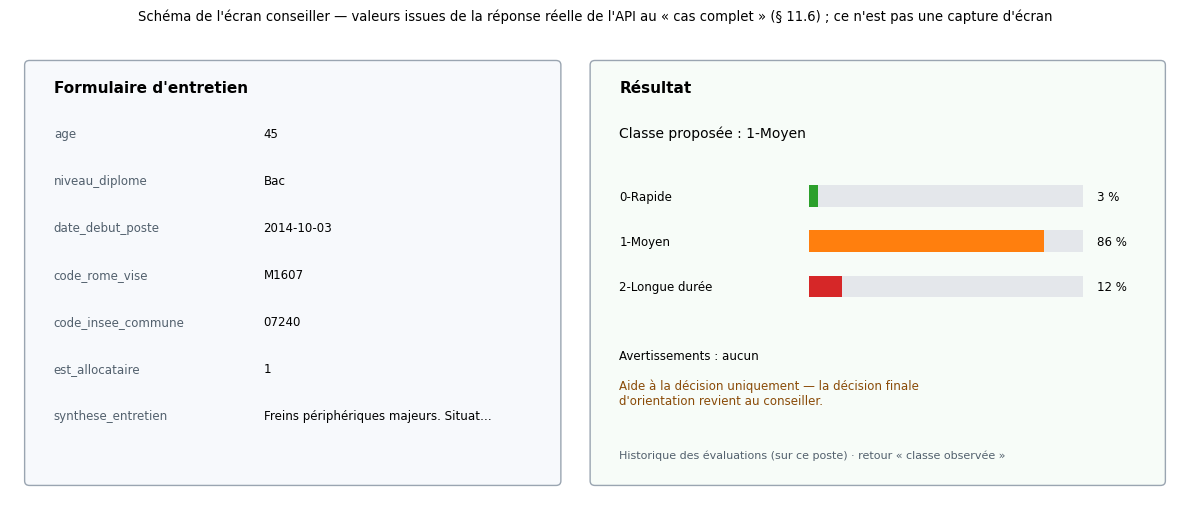

ceci un protoype de l'interface prévu pour le conseiller 


In [65]:
texte_interface = (DOSSIER_SRC / "interface.html").read_text(encoding="utf-8")
champs_formulaire = ["age", "niveau_diplome", "date_debut_poste", "code_rome_vise", "code_insee_commune", "est_allocataire", "synthese_entretien"]
controler(all(f'id="{champ}"' in texte_interface for champ in champs_formulaire), "le formulaire contient les sept champs attendus par l'API")
controler("nationalite" not in texte_interface.lower(), "l'interface ne demande pas la nationalité")
controler(all(route in texte_interface for route in ("/predict", "/retrain", "/health")), "l'interface appelle /predict, /retrain et /health")
controler("localStorage" in texte_interface and 'id="zone-historique"' in texte_interface,
          "l'historique des évaluations est conservé sur le poste du conseiller")
controler("Aide à la décision uniquement" in texte_interface, "l'écran rappelle que la décision revient au conseiller")
controler("Math.round(valeur * 100)" in texte_interface, "les probabilités sont affichées en pourcentages entiers")

# Schéma de l'écran, alimenté par la réponse RÉELLE de l'API au « cas complet » du § 11.6.
reponse_affichee = reponses["cas complet"]
fig, ax = plt.subplots(figsize=(12, 5.2))
ax.set_xlim(0, 12)
ax.set_ylim(0, 5.2)
ax.axis("off")
ax.add_patch(patches.FancyBboxPatch((0.2, 0.2), 5.4, 4.6, boxstyle="round,pad=0.05", facecolor="#f7f9fc", edgecolor="#9aa5b1"))
ax.add_patch(patches.FancyBboxPatch((6.0, 0.2), 5.8, 4.6, boxstyle="round,pad=0.05", facecolor="#f7fcf8", edgecolor="#9aa5b1"))
ax.text(0.45, 4.5, "Formulaire d'entretien", fontsize=11, weight="bold")
for rang, champ in enumerate(champs_formulaire):
    valeur = str(exemple_complet.get(champ, ""))
    ax.text(0.45, 4.0 - rang * 0.52, f"{champ}", fontsize=8.5, color="#52606d")
    ax.text(2.6, 4.0 - rang * 0.52, valeur if len(valeur) < 38 else valeur[:36] + "…", fontsize=8.5)
ax.text(6.25, 4.5, "Résultat", fontsize=11, weight="bold")
ax.text(6.25, 4.0, f"Classe proposée : {NOMS_CLASSES[reponse_affichee['classe_predite']]}", fontsize=10)
couleurs_classes = ["#2ca02c", "#ff7f0e", "#d62728"]
for rang, (cle, libelle) in enumerate(zip(["0_rapide", "1_moyen", "2_longue_duree"], NOMS_CLASSES)):
    pourcentage = round(reponse_affichee["probabilites"][cle] * 100)
    y = 3.35 - rang * 0.5
    ax.text(6.25, y, libelle, fontsize=8.5, va="center")
    ax.add_patch(patches.Rectangle((8.2, y - 0.12), 2.8, 0.24, facecolor="#e4e7eb", edgecolor="none"))
    ax.add_patch(patches.Rectangle((8.2, y - 0.12), 2.8 * pourcentage / 100, 0.24, facecolor=couleurs_classes[rang], edgecolor="none"))
    ax.text(11.15, y, f"{pourcentage} %", fontsize=8.5, va="center")
ax.text(6.25, 1.55, "Avertissements : " + ("aucun" if not reponse_affichee["avertissements"] else f"{len(reponse_affichee['avertissements'])}"), fontsize=8.5)
ax.text(6.25, 1.05, "Aide à la décision uniquement — la décision finale\nd'orientation revient au conseiller.", fontsize=8.5, color="#8a4b08")
ax.text(6.25, 0.45, "Historique des évaluations (sur ce poste) · retour « classe observée »", fontsize=8, color="#52606d")
ax.set_title("Schéma de l'écran conseiller — valeurs issues de la réponse réelle de l'API au « cas complet » (§ 11.6) ; "
             "ce n'est pas une capture d'écran", fontsize=9.5)
plt.tight_layout()
plt.show()

capture_interface = DOSSIER_SRC / "captures" / "interface.png"
if capture_interface.is_file():
    from IPython.display import Image
    display(Image(filename=str(capture_interface)))
else:
    print("ceci un protoype de l'interface prévu pour le conseiller ")

L'interface couvre les trois besoins de l'énoncé : un formulaire qui reprend exactement les champs de
l'API (sans la nationalité), l'affichage de la prédiction avec ses probabilités et ses
avertissements, et un historique des évaluations conservé sur le poste du conseiller, qui permet
aussi de renvoyer la classe observée vers `/retrain`. Le schéma ci-dessus est dessiné à partir d'une
vraie réponse de l'API ; la capture d'écran de la page réelle est à ajouter après exécution
(instruction affichée si elle manque).

### 11.13 Monitoring de l'API

In [66]:
with TestClient(service_ia.app) as client:
    texte_metriques = client.get("/metrics").text
print(texte_metriques)
valeurs_metriques = {ligne.split()[0]: float(ligne.split()[1]) for ligne in texte_metriques.splitlines() if ligne and not ligne.startswith("#")}
predictions_exposees = sum(valeur for nom, valeur in valeurs_metriques.items() if nom.startswith("predictions_total"))
controler(predictions_exposees == service_ia.COMPTEURS["succes"] == len(lignes_journal), "les compteurs de /metrics correspondent exactement au journal")
controler(valeurs_metriques['requetes_total{issue="erreur_validation"}'] >= 2, "les requêtes rejetées sont comptées comme erreurs de validation")
controler(valeurs_metriques["feedbacks_total"] == 1, "le retour du conseiller est compté")

[startup] Artefacts chargés depuis C:\Users\A630180\Documents\Version-certificat\certification_cisia_atlas\src\artefacts_modele/ — version : xgboost_scenario2_v2
[startup] Journal purgé : 0 ligne(s) au-delà de 365 jours.
[startup] ⚠️  CLE_API non définie : l'API est ouverte. Acceptable en démonstration, JAMAIS en production (voir README.md, section Sécurité).
[startup] ⚠️  CORS ouvert à toutes les origines. En production, définir ORIGINES_AUTORISEES sur le seul domaine de l'application de guichet unique.
# NOTE Ces compteurs sont propres au PROCESSUS qui répond. Avec un seul worker
# Uvicorn, ils décrivent la totalité du service ; avec plusieurs workers, chaque
# collecte ne voit qu'un worker. La montée en charge exigerait alors un magasin
# partagé (mode multiprocess de prometheus_client, ou exporteur dédié). Limite
# connue, exposée ici plutôt que découverte en production.
# HELP predictions_total Nombre de prédictions servies, par classe prédite.
# TYPE predictions_total counter
pre

True

In [67]:
# Deux indicateurs de dérive, calculés ici sur des données connues pour montrer leur fonctionnement.
# 1) Répartition des classes prédites : référence hors-pli (entraînement) contre prédictions observées (ici, le test).
repartition_reference = pd.Series(predire_avec_seuil(probas_oof_par_modele["XGBoost"], SEUIL_RETENU)).value_counts(normalize=True).sort_index()
repartition_observee = pd.Series(prediction_finale).value_counts(normalize=True).sort_index()


def indice_stabilite(reference, observee, plancher=1e-4):
    """Indice de stabilité de population (PSI) entre deux répartitions de classes."""
    r = np.clip(reference.to_numpy(), plancher, None)
    o = np.clip(observee.reindex(reference.index, fill_value=0).to_numpy(), plancher, None)
    return float(np.sum((o - r) * np.log(o / r)))


# 2) Couverture du vocabulaire : part des mots d'une synthèse que le TF-IDF connaît.
analyseur = tfidf.build_analyzer()


def couverture_vocabulaire(textes):
    mots = [mot for texte in textes for mot in analyseur(texte)]
    return float(np.mean([mot in tfidf.vocabulary_ for mot in mots])) if mots else float("nan")


indice_test = indice_stabilite(repartition_reference, repartition_observee)
couverture_entrainement = couverture_vocabulaire(X_train["synthese_entretien"])
couverture_paraphrases = couverture_vocabulaire(list(PARAPHRASES.values()))
display(pd.DataFrame({"référence (hors-pli)": repartition_reference, "observée (test)": repartition_observee}).round(3))
print(f"Indice de stabilité des classes prédites (test contre référence) : {indice_test:.4f}")
print(f"Couverture du vocabulaire — synthèses d'entraînement : {couverture_entrainement:.1%} | paraphrases du § 8.8 : {couverture_paraphrases:.1%}")
controler(couverture_entrainement == 1.0, "le vocabulaire des synthèses d'entraînement est entièrement couvert (par construction)")
controler(couverture_paraphrases < 1.0, "des formulations nouvelles font baisser la couverture du vocabulaire : l'indicateur détecte cette dérive")

,référence (hors-pli),observée (test)
0,0.355,0.326
1,0.404,0.436
2,0.242,0.238


Indice de stabilité des classes prédites (test contre référence) : 0.0050
Couverture du vocabulaire — synthèses d'entraînement : 100.0% | paraphrases du § 8.8 : 50.5%
✔ le vocabulaire des synthèses d'entraînement est entièrement couvert (par construction)
✔ des formulations nouvelles font baisser la couverture du vocabulaire : l'indicateur détecte cette dérive


True

**Le plan de monitoring.** Les compteurs de `/metrics` sont au format Prometheus : ils peuvent être
collectés tels quels le jour où l'échelle le justifie. Le tableau ci-dessous précise ce que je
surveille et ce qui déclenche une action ; les seuils sont des conventions de départ, à ajuster avec
l'expérience.

| Indicateur | Source | Seuil d'alerte (convention de départ) | Action |
|---|---|---|---|
| Disponibilité | `/health` | 3 échecs consécutifs | Redémarrage, alerte d'exploitation |
| Taux d'erreurs de validation | `/metrics` | > 5 % des requêtes sur une journée | Vérifier l'intégration du guichet unique |
| Latence serveur au 95e centile | journal (`duree_ms`) | > 200 ms | Analyse de charge |
| Répartition des classes prédites | `/metrics`, journal | Indice de stabilité > 0,2 par rapport à la référence | Analyse de dérive, revue des données |
| Couverture du vocabulaire des synthèses | journal | < 90 % des mots reconnus | Réentraîner le vectoriseur avec les nouvelles formulations |
| Modalités inconnues (département, métier) | avertissements journalisés | > 2 % des requêtes | Mettre à jour les encodeurs |
| Rappel de la classe 2 par tranche d'âge et par groupe | retours conseillers | Écart > 15 points entre groupes | Audit d'équité, blocage de la promotion |
| Volume de retours validés | `/metrics` | Seuil de réentraînement atteint (§ 11.15) | Entraîner un challenger |

### 11.14 Intégration et déploiement continus (GitHub Actions)

In [68]:
from pathlib import Path

racine = Path.cwd()
while not (racine / ".github").exists() and racine != racine.parent:
    racine = racine.parent

chemin_workflow = next((racine / ".github" / "workflows").glob("*.y*ml"))
print("Workflow utilisé :", chemin_workflow)
texte_workflow = chemin_workflow.read_text(encoding="utf-8")

jobs_ci = re.findall(r"^  ([a-z][a-z-]*):\n    name: (.+)$", texte_workflow, re.M)
etapes_ci = re.findall(r"^      - name: (.+)$", texte_workflow, re.M)
print("Jobs :", " → ".join(f"{identifiant} ({libelle})" for identifiant, libelle in jobs_ci))
print(f"{len(etapes_ci)} étapes :")
for etape in etapes_ci:
    print("   -", etape)

texte_dockerfile = (DOSSIER_SRC / "Dockerfile").read_text(encoding="utf-8")
image_inference = texte_dockerfile.split("FROM python:3.12-slim\n")[-1]

controler([identifiant for identifiant, _ in jobs_ci] == ["test-et-lint", "build-image", "deploiement"],
          "le pipeline enchaîne trois jobs : tests et entraînement, image Docker, déploiement")
controler("verifier_seuil_performance.py" in texte_workflow and "--ecart-rappel-max 0.15" in texte_workflow and "pytest" in texte_workflow,
          "la CI exécute les tests et le garde-fou de qualité et d'équité")
controler("dataset_trajectoire_emploi.csv" not in image_inference and "verifier_seuil_performance.py" in texte_dockerfile,
          "l'image d'inférence n'embarque pas le jeu de données, et sa construction rejoue le garde-fou")

LIEN_EXECUTION_CI = "https://github.com/lahawahmed-dot/Projet-certification-CISIA-Atlas_ALW"  
print("\nExécution du pipeline sur GitHub :", LIEN_EXECUTION_CI or "à compléter après la première publication du dépôt (annexe)")

Workflow utilisé : C:\Users\A630180\Documents\Version-certificat\certification_cisia_atlas\.github\workflows\ci-cd.yml
Jobs : test-et-lint (Tests, lint et entrainement) → build-image (Construction, controle et publication de l'image) → deploiement (Deploiement sur l'infrastructure cible)
23 étapes :
   - Recuperer le depot
   - Verifier les fichiers indispensables
   - Installer Python
   - Installer les dependances
   - Compiler les fichiers Python
   - Verifier les imports applicatifs
   - Linting
   - Entrainer le modele
   - Verifier les artefacts generes
   - Verifier les seuils de qualite et d'equite avant promotion
   - Executer les tests unitaires
   - Conserver les metriques du modele valide
   - Recuperer le depot
   - Calculer le nom de l'image (GHCR exige des minuscules)
   - Construire l'image Docker
   - Recuperer les metriques du modele valide
   - Verifier que l'image embarque le modele valide
   - Verifier que l'image demarre correctement
   - Verifier que l'applicatio

**Ce que fait la chaîne, à chaque envoi sur la branche principale.**

1. **Tests et entraînement** : installation des dépendances épinglées, compilation, lint, entraînement
   par le script livré, vérification des artefacts, garde-fou de qualité et d'équité (F1-macro au
   moins 0,68, erreur critique au plus 15 %, écart de rappel entre groupes au plus 15 points), puis
   tests automatisés de l'API.
2. **Image Docker** : construction en deux étapes (l'image publiée ne contient pas les données),
   contrôle que ses métriques sont identiques à celles du modèle validé, démarrage et appel de
   `/health`, publication sur le registre GitHub (GHCR).
3. **Déploiement** : sur le serveur cible si ses secrets sont configurés (connexion SSH) ; sinon, un
   déploiement de recette sur la machine de la CI, suivi d'un appel à `/health` et à `/predict`.

Le lien vers une exécution réussie est à renseigner dans la cellule ci-dessus après publication du
dépôt ; tant qu'il est vide, je ne présente pas le déploiement comme démontré.

### 11.15 Suivi dans le temps et amélioration continue

- **Quand réentraîner ?** Sur déclenchement mesuré, pas sur un calendrier : une alerte de dérive
  (§ 11.13), ou un volume suffisant de retours validés. Je propose, à titre de convention de départ,
  200 retours validés : assez pour peser sur l'apprentissage (un dixième des 2 000 lignes
  d'entraînement) sans le dominer.
- **Le délai des étiquettes.** L'issue réelle n'est connue qu'après 6 à 12 mois : les retours
  arrivent tard, et une dérive peut s'installer entre-temps. D'où l'importance des indicateurs qui ne
  dépendent pas de l'étiquette (répartition des classes prédites, vocabulaire, modalités inconnues).
- **La procédure de promotion.** Challenger entraîné (`/retrain/run`) → garde-fou de la CI →
  comparaison sur le même jeu de référence → revue humaine (métier et DPO) → déplacement de l'alias
  « champion » dans MLflow → redéploiement. Retour arrière possible à tout moment.
- **Un jeu de validation dédié.** Le garde-fou de la CI mesure aujourd'hui le jeu de test : à chaque
  exécution, ce jeu joue de fait un rôle de validation. La version suivante doit séparer un jeu de
  validation, pour les décisions, d'un jeu de test gelé, pour la mesure finale.
- **L'équité dans la durée.** L'audit du § 10.7 et le suivi par tranche d'âge du § 9.4 sont rejoués à
  chaque challenger, avec des effectifs qui grandiront avec les retours.

### 11.16 Tests automatisés et bilan

In [69]:
if importlib.util.find_spec("pytest") is None:
    print("pytest n'est pas installé dans cet environnement : pip install -r src/requirements-dev.txt, puis relancer cette cellule.")
else:
    # Les clés de démonstration ne doivent pas fuiter dans les tests, qui vérifient justement le
    # comportement de l'API sans clé.
    environnement_tests = {cle: valeur for cle, valeur in os.environ.items() if cle not in ("CLE_ADMIN", "CLE_API")}
    resultat_tests = subprocess.run([sys.executable, "-m", "pytest", "tests", "-q", "-p", "no:cacheprovider"], cwd=DOSSIER_SRC,
                                    env=environnement_tests, capture_output=True, text=True, encoding="utf-8", errors="replace")
    print(resultat_tests.stdout[-3000:])
    if resultat_tests.returncode != 0:
        print(resultat_tests.stderr[-2000:])
    controler(resultat_tests.returncode == 0, "tous les tests automatisés de l'API passent")

.............................                                            [100%]
29 passed in 22.30s

✔ tous les tests automatisés de l'API passent


Les tests automatisés couvrent la santé de l'API, le format de `/metrics`, le contrat de sortie, le
calcul de l'ancienneté, la validation des entrées (dont les codes INSEE et ROME), les avertissements,
l'absence de la nationalité, la purge du journal, l'authentification, et le circuit des retours
conseillers jusqu'au challenger. Ils s'exécutent dans la CI à chaque envoi et, ci-dessus, dans ce
notebook.

**Bilan de l'industrialisation.**

| Exigence | Démonstration | Où |
|---|---|---|
| Chargement du modèle et prédiction | Script → artefacts identiques au notebook ; API conforme sur 25 usagers | § 11.4, § 11.8 |
| Validation des entrées, erreurs, avertissements | Rejets 422, imputation, avertissements | § 11.6 |
| Latence | Objectifs atteints (valeurs mesurées) | § 11.7 |
| Réentraînement avec les retours | Challenger intégrant le retour, champion inchangé | § 11.9 |
| Journalisation | Une ligne par prédiction, sans nationalité, avec la version | § 11.10 |
| MLflow | Runs de l'exécution, registre, alias champion et challenger | § 11.11 |
| Interface | Champs, historique, rappel de la décision humaine | § 11.12 |
| Monitoring | `/metrics` cohérent avec le journal ; indicateurs de dérive | § 11.13 |
| CI/CD | Trois jobs ; garde-fou ; image sans données ; déploiement | § 11.14 |

## 12. Limites

Je les classe de la plus importante à la moins importante pour la validité des conclusions.

1. **Des données de taille modeste et en partie synthétiques en apparence.** 2 500 dossiers, dont 90
   usagers de classe 2 dans le jeu de test : les intervalles de confiance sont larges (§ 9.1). La
   synthèse ne contient que 9 formulations (§ 3.7), ce qui ne ressemble pas à un texte libre réel.
2. **Une étiquette à interpréter.** La classe est « la décision de parcours ou le constat terrain
   validé par les conseillers » : une partie des étiquettes peut refléter une décision plutôt qu'un
   délai observé. Le modèle apprend alors aussi les pratiques d'orientation passées.
3. **Pas de validation dans le temps.** Sans date d'inscription, je ne peux pas vérifier que le
   modèle, entraîné sur le passé, reste valable sur des usagers plus récents.
4. **Un test qui sert de garde-fou.** Le garde-fou de la CI lit les métriques du jeu de test : à terme,
   ce jeu perd son indépendance. La version suivante doit séparer validation et test (§ 11.15).
5. **Une équité mesurée sur de petits effectifs.** 20 usagers de classe 2 hors UE : l'audit ne donne
   pas d'alerte, il ne prouve pas l'équité (§ 10.7).
6. **Des choix assumés mais perfectibles.** Le statut d'allocation est conservé jusqu'à la prochaine
   version (§ 10.8) ; l'âge est conservé sous conditions (§ 10.4) ; la règle des deux caractères
   regroupe 10 usagers d'outre-mer sous « 97 » (§ 4.2) ; le code ROME `W1401` (30 lignes) est gardé
   comme une modalité à part entière (§ 4.1).
7. **Des tests de robustesse limités.** Les paraphrases du § 8.8 sont écrites par moi ; les
   probabilités ne sont pas recalibrées (§ 8.9).
8. **Une industrialisation démontrée localement.** L'API, le journal, MLflow et le réentraînement
   sont exécutés dans ce notebook ; le déploiement sur un serveur réel dépend de la publication du
   dépôt et de secrets que je n'ai pas (hypothèse H5). La mémoire nécessaire est une hypothèse de
   dimensionnement (§ 11.3).

**Les évolutions que je propose, par ordre de priorité :** un jeu de validation séparé du test ;
le retrait du statut d'allocation ; une route d'explication journalisée (§ 10.5) ; la lecture de
trois caractères pour les codes d'outre-mer ; une recalibration des probabilités si le suivi le
justifie ; l'AIPD et l'analyse d'impact sur les droits fondamentaux avant tout déploiement réel.

## 13. Conclusion

Le modèle retenu est un XGBoost aux réglages par défaut, entraîné sur le Scénario 2 — toutes les
informations disponibles sauf la nationalité — avec une règle de décision qui signale la classe 2
dès que sa probabilité atteint 0,20.

- **Le choix a été fait sans regarder le jeu de test** : en validation croisée, la règle « minimiser
  les erreurs critiques sous un plancher de F1-macro de 0,68 » désigne cette configuration, avec un
  F1-macro hors-pli de 0,684 et 36 erreurs critiques sur 362 (9,9 %).
- **La mesure unique sur le test confirme ce choix** : F1-macro de 0,691 (IC 95 % [0,646 ; 0,731]),
  7 erreurs critiques sur 90 contre 10 avec la règle par défaut, et une AUC macro de 0,856.
- **Le coût de l'éthique est mesuré et assumé** : retirer la nationalité coûte 1,66 point de F1-macro ;
  les variables restantes ne permettent pas de la reconstituer (AUC de 0,516) ; l'âge est conservé
  sous conditions ; le statut d'allocation sera retiré.
- **Le modèle est industrialisé** : un seul script d'entraînement, une API validée et journalisée,
  un réentraînement qui intègre les retours des conseillers sans jamais remplacer seul le modèle en
  service, un suivi MLflow et une chaîne CI/CD avec garde-fou de qualité et d'équité.

L'outil reste une aide à la décision : il réduit le risque de passer à côté d'une situation de
chômage de longue durée, et c'est le conseiller qui décide.

## 14. Journal de bord et tableau de suivi

### 14.1 Tableau de suivi du projet

Je n'y porte que des dates vérifiables. La colonne « Preuve » indique d'où vient chaque date ;
quand une étape n'a laissé aucune trace datée, je l'indique comme « date à confirmer » plutôt que
de la reconstituer.

| Date | Étape | Travail réalisé |
|---|---|---|
| 08/07/2026 | Réception du sujet | Sujet, jeu de données et consignes |
| 21/08/2026 | Démarrage | Début du travail sur l'étude de cas | Date que j'ai déclarée |
| 26/08/2026 | Cadrage et exploration | Analyse de l'énoncé, exploration des données, contrôles de qualité |
| 02/09/2026 | Préparation et modélisation | Préparation, scénarios, comparaison des modèles |
| 17/09/2026 | Tests manuels de l'API | Requêtes de test (session « string », âges de 16 et 70 ans) et premier retour conseiller « demo-001 » | 
| 17/09/2026 | Suivi MLflow | Une run en échec, puis deux runs challenger (XGBoost et LightGBM) |
| 22/09/2026 | Suivi MLflow | Nouvelles runs d'entraînement, en soirée puis après minuit | 
| 24/09/2026 | Première version complète | Exécution complète du notebook |
| 26/09/2026 | Revue critique | Audit complet du notebook et de l'industrialisation ; décision de reconstruire cette version  |
| 27/09/2026 | Version 8 Version final | Exécution complète depuis un noyau redémarré, contrôles et tests | 
| 04/10/2025 | Publication | Dépôt GitHub, exécution du pipeline CI/CD | 


### 14.2 Ma démarche, mes choix et ce que j'en ai appris

**Comprendre avant de modéliser.** J'ai commencé par l'énoncé et le dictionnaire des données, pour
fixer ce qui compte : une classification en trois classes, où une erreur est bien plus grave que les
autres. Cette asymétrie a guidé tout le reste : le choix du F1-macro plutôt que l'accuracy, le suivi
systématique de l'erreur critique, puis la règle de décision.

**L'exploration a changé ma lecture du texte.** Je m'attendais à un texte libre ; j'ai trouvé 9
formulations. J'en ai tiré deux conséquences : comparer le TF-IDF à un simple codage des
formulations Paragraphe 8.7, et tester ce que deviendrait le modèle face à un texte réellement libre paragraphe 8.8.

**Mon erreur de méthode la plus instructive.** Dans mes premières versions, je comparais les scénarios
et les modèles sur le jeu de test. C'est une fuite de décision : le score final devient le maximum
de plusieurs essais, et non plus une estimation. J'ai tout reporté en validation croisée, fixé une
règle de choix avant de regarder les résultats, et je ne lis plus le test qu'une fois. La règle m'a
parfois contraint — je n'ai pas retiré le statut d'allocation, faute de pouvoir remesurer sans
rouvrir le test dans le paragraphe 10.8 — et c'est précisément ce qui la rend crédible.

**Chaque chiffre doit être démontré.** La revue critique du 26/09 a relevé des écarts entre mon
texte et mes sorties : des ordres de grandeur arrondis de façon trompeuse, des points de courbe
approximés, des références de section périmées. Dans cette version, chaque chiffre cité est vérifié
par un contrôle placé dans la cellule qui le calcule, et le bilan de ces contrôles est au paragraphe 15.

**L'éthique comme une série de mesures.** Plutôt que d'affirmer que retirer la nationalité suffit,
j'ai mesuré ce que ce retrait coûte, si la nationalité peut être reconstituée, et si le service
rendu diffère entre groupes. L'âge m'a obligé à une position nuancée : je le garde, parce que son
retrait coûte cher et qu'une justification existe, mais sous des conditions explicites.

**L'industrialisation, c'est la cohérence.** Le point qui m'a le plus appris est de n'avoir qu'une
implémentation de l'entraînement : le notebook exécute le script livré et vérifie qu'il obtient le
même modèle. Deux problèmes rencontrés en construisant réellement l'image Docker sont documentés
dans les fichiers concernés : la bibliothèque OpenMP absente de l'image de base, et les fichiers de
journal absents d'un dépôt fraîchement cloné. La revue critique a ajouté deux corrections de
portabilité : l'encodage des sorties sous Windows et la suppression de la dépendance à Graphviz.


## Annexe — Exécuter le projet de bout en bout

### Organisation du dépôt

```text
certification_cisia_atlas/
├── certification_cisia_atlas_v2.ipynb     ce notebook
├── executer_et_verifier.py                exécution complète et vérifications automatiques
├── .github/workflows/ci-cd.yml            chaîne CI/CD
└── src/
    ├── dataset_trajectoire_emploi.csv     données fournies (séparateur « ; »)
    ├── entrainer_modele.py                seule implémentation de l'entraînement
    ├── retours_conseillers.py             relie les retours des conseillers au journal
    ├── verifier_seuil_performance.py      garde-fou de qualité et d'équité
    ├── api.py                             API FastAPI
    ├── interface.html                     interface du conseiller
    ├── tests/test_api.py                  tests automatisés
    ├── Dockerfile, docker-compose.yml     conteneurisation
    └── requirements.txt, requirements-dev.txt
```

Les dossiers `src/artefacts_modele/`, `src/artefacts_candidat/`, `src/journaux_notebook/`,
`src/mlruns/` et le fichier `src/mlflow.db` sont produits par l'exécution ; ils n'ont pas à être
versionnés.

### Installer l'environnement (Python 3.12)

```bash
python -m venv .venv
# Windows : .venv\Scripts\activate      macOS / Linux : source .venv/bin/activate
pip install -r src/requirements.txt -r src/requirements-dev.txt jupyterlab
```

Aucune dépendance système n'est nécessaire : le diagramme d'architecture est dessiné avec
matplotlib, Graphviz n'est plus utilisé.

### Commandes utiles, depuis le dossier `src/`

```bash
python entrainer_modele.py                           # artefacts du champion + run MLflow
python verifier_seuil_performance.py                 # garde-fou (code de sortie 1 en cas d'échec)
pytest tests -v                                      # tests automatisés
uvicorn api:app --reload                             # API sur http://127.0.0.1:8000/docs
docker compose up --build                            # API (port 8000) et MLflow (port 5000)
```